In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
!uv pip list

Package                                  Version
---------------------------------------- ------------
aiohappyeyeballs                         2.7.1
aiohttp                                  3.14.3
aiosignal                                1.4.0
alembic                                  1.19.0
amqp                                     5.3.1
annotated-doc                            0.0.5
annotated-types                          0.8.0
anyio                                    4.14.2
appdirs                                  1.4.4
argon2-cffi                              25.1.0
argon2-cffi-bindings                     25.1.0
arrow                                    1.4.0
asttokens                                3.0.2
async-lru                                2.3.0
asyncpg                                  0.31.0
attrs                                    26.1.0
babel                                    2.18.0
backoff                                  2.2.1
beautifulsoup4                           4.

Using Python 3.12.12 environment at: d:\tss rao\Portfolio Projects\clinical-investigation-agent\.venv


# CSV Exploration

## Patients

In [3]:
patients_df = pd.read_csv('../synthea_data/output/csv/patients.csv')
patients_df

,Id,BIRTHDATE,DEATHDATE,SSN,DRIVERS,PASSPORT,PREFIX,FIRST,MIDDLE,LAST,SUFFIX,MAIDEN,MARITAL,RACE,ETHNICITY,GENDER,BIRTHPLACE,ADDRESS,CITY,STATE,COUNTY,FIPS,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,INCOME
0,c44d667b-15d5-99d4-0f69-43ca66739022,1965-08-29,NaN,999-61-1158,S99942359,X90357234X,Mrs.,Azalee124,NaN,Rippin620,NaN,Streich926,D,white,nonhispanic,F,Hudson Massachusetts US,102 Conroy Camp,Webster,Massachusetts,Worcester County,25027.00,1570,42.05,-71.83,481568.96,242241.60,40621
1,51c5e2a9-2833-5133-b85a-329b9cd53c41,1986-01-22,NaN,999-92-7443,S99972916,X87842688X,Mr.,Merrill415,Bernard308,Johnson679,JD,NaN,D,white,nonhispanic,M,Saugus Massachusetts US,175 Walker Skyway Apt 94,Cochituate,Massachusetts,Middlesex County,NaN,0,42.28,-71.35,408183.15,293397.78,53297
2,502cf42a-a540-ff39-0d59-c10d7cc1f4c7,2007-04-16,NaN,999-84-7678,S99975791,NaN,Ms.,Aletha771,Isabell86,Ondricka197,NaN,NaN,NaN,white,nonhispanic,F,Cohasset Massachusetts US,234 Powlowski Loaf Suite 94,Belmont,Massachusetts,Middlesex County,25017.00,2138,42.36,-71.20,71276.61,538108.50,526968
3,02459150-c160-03b6-f1dd-dae8fd4b3e84,1970-04-25,NaN,999-14-5874,S99948951,X56279905X,Mrs.,Cathy455,NaN,Gleason633,NaN,Wintheiser220,M,white,nonhispanic,F,Northampton Massachusetts US,833 Rippin Lock Unit 28,Douglas,Massachusetts,Worcester County,NaN,0,42.07,-71.78,296834.71,1506701.17,168634
4,3237c17d-ea0b-90f4-0743-787ef29d2404,2025-01-11,NaN,999-94-6423,NaN,NaN,NaN,Zada604,Teisha100,Metz686,NaN,NaN,NaN,white,nonhispanic,F,Swansea Massachusetts US,696 Becker Wynd,North Adams,Massachusetts,Berkshire County,25003.00,1247,42.63,-73.13,500.00,5931.33,23153
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2333,213d3203-82da-c9e0-9186-840f582075bc,1925-01-21,1976-02-24,999-63-8604,S99971542,X57507989X,Mr.,Sterling124,Kraig824,Hauck852,NaN,NaN,D,black,nonhispanic,M,Lynn Massachusetts US,986 Emard Rue Suite 64,Boxford,Massachusetts,Essex County,25009.00,1921,42.73,-71.02,769574.90,0.00,113034
2334,803e8b31-ad2c-6c3a-c1be-de67544b6d2b,1925-01-21,1988-08-02,999-86-2819,S99933764,X37236096X,Mr.,Collin529,Willis868,O'Keefe54,NaN,NaN,D,black,nonhispanic,M,South Deerfield Massachusetts US,784 Schmeler Village Unit 41,Boxford,Massachusetts,Essex County,25009.00,1921,42.72,-70.99,294765.88,127376.51,113034
2335,b00222da-8016-b43b-10b0-818e19e8ed82,1925-01-21,2010-08-11,999-24-1845,S99937843,X72009102X,Mr.,Larry532,Judson999,Halvorson124,NaN,NaN,M,black,nonhispanic,M,Boston Massachusetts US,555 McGlynn Camp Unit 72,Boxford,Massachusetts,Essex County,25009.00,1921,42.72,-71.00,265298.29,168739.95,113034
2336,93adf52a-483e-ccb6-f8b3-a046e54372d6,1925-01-21,2014-05-23,999-50-6407,S99930251,X13054230X,Mr.,Wendell199,Bud153,Lowe577,NaN,NaN,M,black,nonhispanic,M,Abington Massachusetts US,788 Feil Station Unit 57,Boxford,Massachusetts,Essex County,25009.00,1921,42.72,-71.07,302942.75,141036.90,113034


- DRIVERS = drivers license
- FIPS = Federal Information Processing Standards code — it's a standardized numeric identifier for U.S. geographic areas (states, counties).  gives the county-level FIPS code for the patient's address — e.g. Massachusetts counties each have a unique 5-digit FIPS code (state code + county code). It's a normalized geography key, useful for joining against external census/demographic datasets

### Data quality

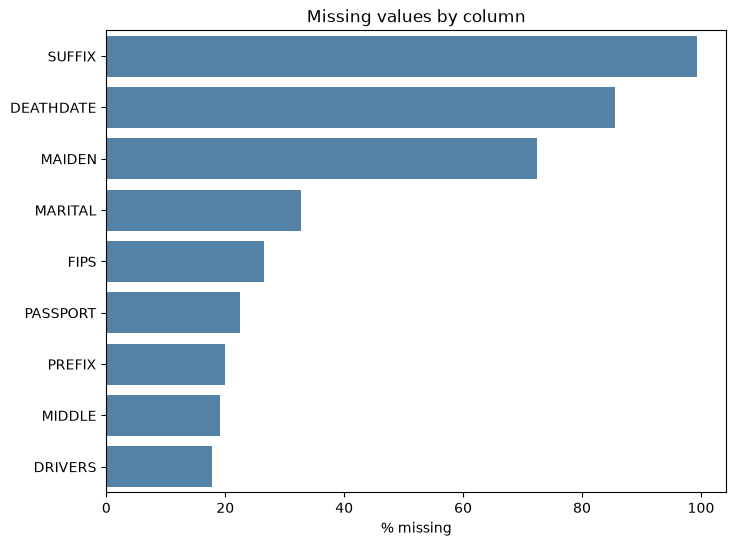

In [4]:
missing_pct = patients_df.isna().mean().sort_values(ascending=False)
missing_pct = (missing_pct[missing_pct > 0] * 100).round(1)

plt.figure(figsize=(8, 6))
sns.barplot(x=missing_pct.values, y=missing_pct.index, color="steelblue")
plt.xlabel("% missing")
plt.ylabel("")
plt.title("Missing values by column")
plt.show()

- Most blanks in MARITAL are under the age of 28.

In [5]:
patients_df['BIRTHDATE'] = pd.to_datetime(patients_df['BIRTHDATE'])
patients_df['DEATHDATE'] = pd.to_datetime(patients_df['DEATHDATE'])

### Demographics

In [6]:
# AGE is current age for living patients, age-at-death for deceased ones — the two
# populations aren't directly comparable without the IS_DECEASED split above.
today = pd.Timestamp.today()
patients_df["IS_DECEASED"] = patients_df["DEATHDATE"].notna()
patients_df["AGE"] = ((patients_df["DEATHDATE"].fillna(today) - patients_df["BIRTHDATE"]).dt.days / 365.25)

In [7]:
patients_df['MARITAL'].unique()

array(['D', nan, 'M', 'S', 'W'], dtype=object)

In [8]:
patients_df[patients_df['MARITAL'].isna()]['AGE'].describe()

count   765.00
mean     14.74
std       8.03
min       0.02
25%       7.71
50%      15.24
75%      21.77
max      28.03
Name: AGE, dtype: float64

(array([70., 63., 70., 64., 87., 84., 77., 81., 82., 87.]),
 array([1.91649555e-02, 2.82026010e+00, 5.62135524e+00, 8.42245038e+00,
        1.12235455e+01, 1.40246407e+01, 1.68257358e+01, 1.96268309e+01,
        2.24279261e+01, 2.52290212e+01, 2.80301164e+01]),
 <BarContainer object of 10 artists>)

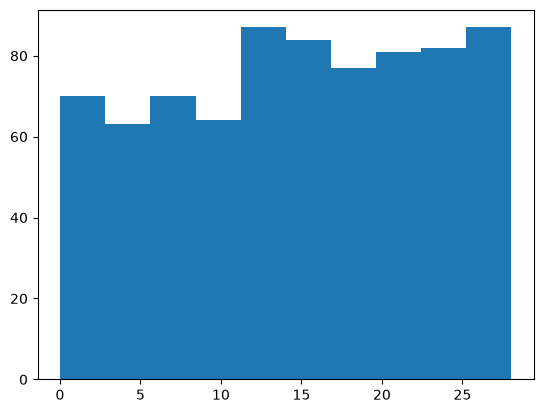

In [9]:
plt.hist(patients_df[patients_df['MARITAL'].isna()]['AGE'])

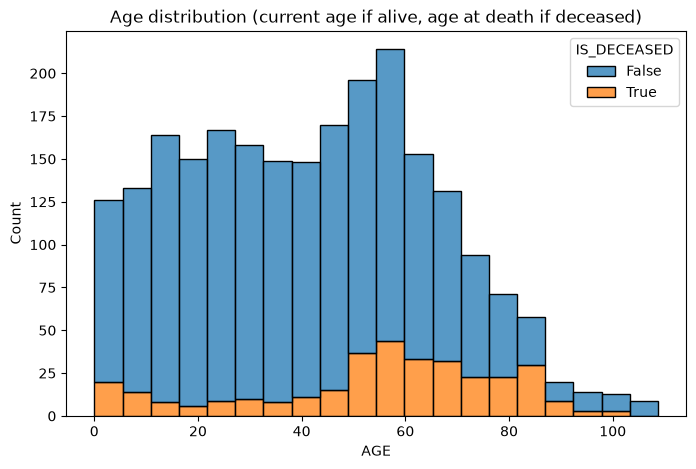

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(data=patients_df, x="AGE", hue="IS_DECEASED", multiple="stack", bins=20)
plt.title("Age distribution (current age if alive, age at death if deceased)")
plt.show()

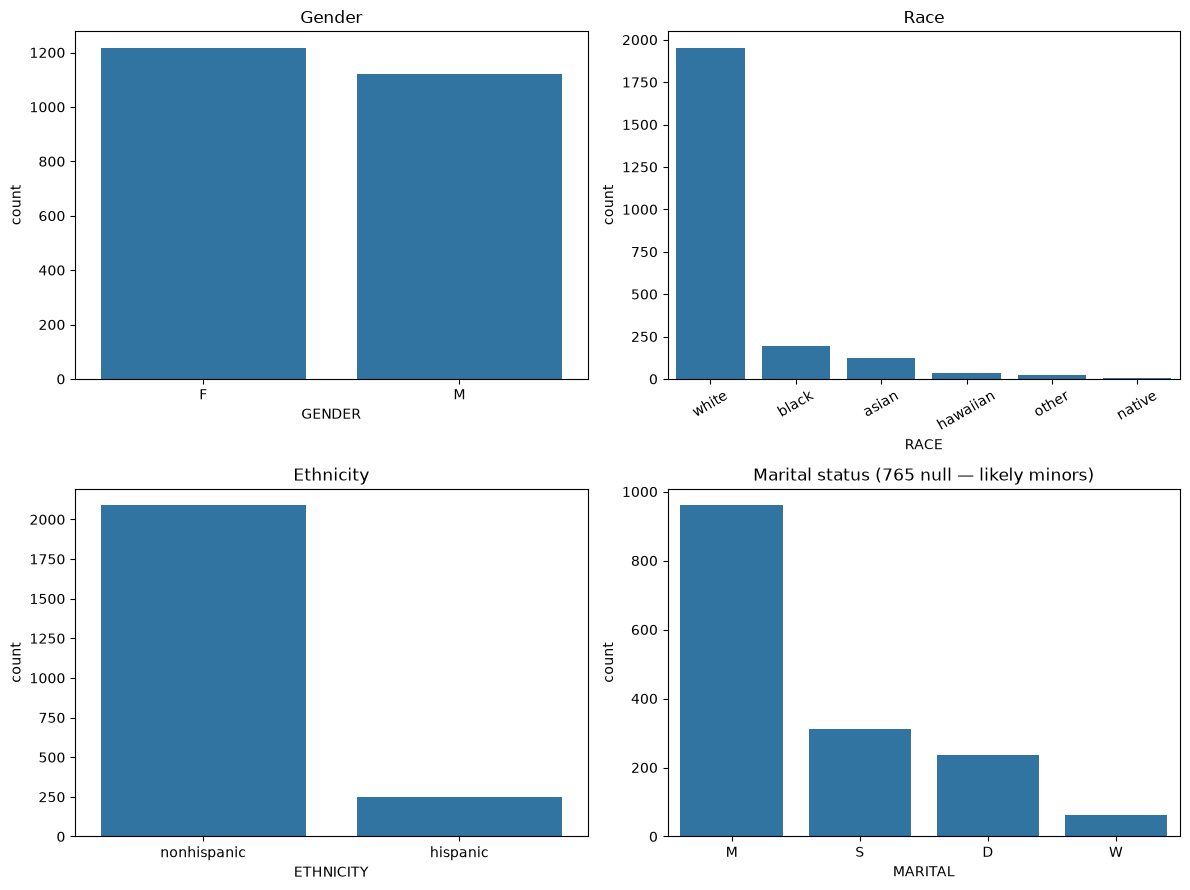

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.countplot(data=patients_df, x="GENDER", ax=axes[0, 0])
axes[0, 0].set_title("Gender")

sns.countplot(data=patients_df, x="RACE", ax=axes[0, 1], order=patients_df["RACE"].value_counts().index,)
axes[0, 1].set_title("Race")
axes[0, 1].tick_params(axis="x", rotation=30)

sns.countplot(data=patients_df, x="ETHNICITY", ax=axes[1, 0])
axes[1, 0].set_title("Ethnicity")

sns.countplot(data=patients_df, x="MARITAL", ax=axes[1, 1], order=patients_df["MARITAL"].value_counts().index,)
axes[1, 1].set_title(f"Marital status ({patients_df['MARITAL'].isna().sum()} null — likely minors)")

plt.tight_layout()
plt.show()

In [12]:
patients_df.describe()

,BIRTHDATE,DEATHDATE,FIPS,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,INCOME,AGE
count,2338,338,1716.00,2338.00,2338.00,2338.00,2338.00,2338.00,2338.00,2338.00
mean,1981-11-27 19:35:09.495295104,2007-03-24 04:02:50.414201088,25094.38,1456.79,42.26,-71.35,181684.99,349872.85,110768.84,41.96
min,1917-12-14 00:00:00,1946-05-20 00:00:00,25001.00,0.00,41.24,-73.34,100.00,0.00,13.00,0.02
25%,1963-12-19 12:00:00,1999-07-02 06:00:00,25011.00,0.00,42.12,-71.54,21624.21,20858.66,29988.25,22.16
50%,1981-11-19 00:00:00,2011-06-22 00:00:00,25017.00,1852.00,42.31,-71.14,93452.29,153750.30,70287.00,42.69
75%,2003-03-23 12:00:00,2019-10-20 18:00:00,25023.00,2150.75,42.45,-71.02,221527.34,551056.69,121828.50,59.22
max,2026-08-22 00:00:00,2026-08-20 00:00:00,44007.00,2861.00,42.88,-69.98,1640571.07,3848516.79,988857.00,108.73
std,NaN,NaN,1210.78,958.50,0.29,0.60,244955.48,470784.93,156519.27,23.82


### Socioeconomic

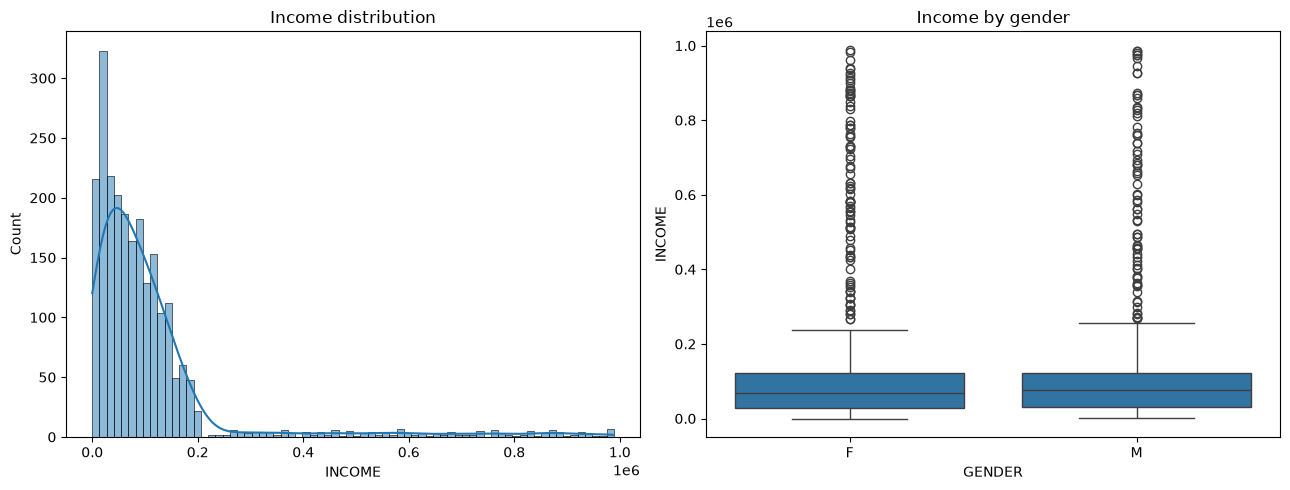

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(data=patients_df, x="INCOME", kde=True, ax=axes[0])
axes[0].set_title("Income distribution")

sns.boxplot(data=patients_df, x="GENDER", y="INCOME", ax=axes[1])
axes[1].set_title("Income by gender")

plt.tight_layout()
plt.show()

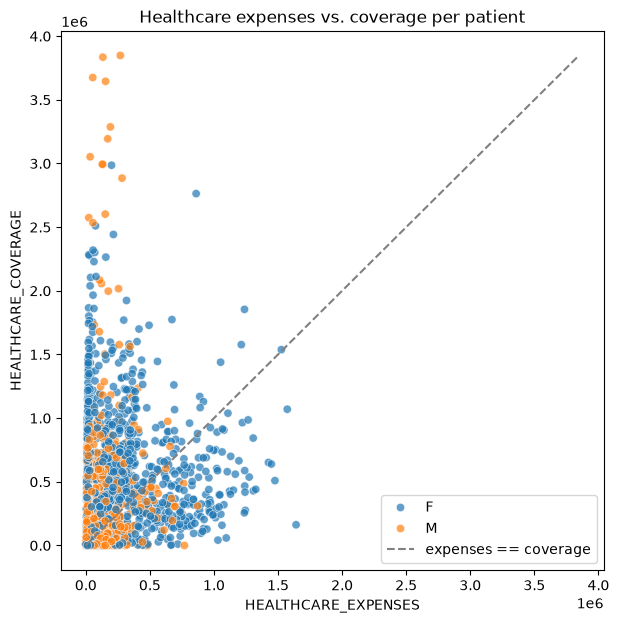

In [14]:
# negative == expenses exceed lifetime payer coverage (out-of-pocket burden);
# positive == coverage exceeds billed expenses (can happen with cumulative payer figures)
patients_df["OUT_OF_POCKET"] = patients_df["HEALTHCARE_EXPENSES"] - patients_df["HEALTHCARE_COVERAGE"]

plt.figure(figsize=(7, 7))
sns.scatterplot(
    data=patients_df, x="HEALTHCARE_EXPENSES", y="HEALTHCARE_COVERAGE",
    hue="GENDER", alpha=0.7,
)
lim = max(patients_df["HEALTHCARE_EXPENSES"].max(), patients_df["HEALTHCARE_COVERAGE"].max())
plt.plot([0, lim], [0, lim], linestyle="--", color="gray", label="expenses == coverage")
plt.legend()
plt.title("Healthcare expenses vs. coverage per patient")
plt.show()

### Geography

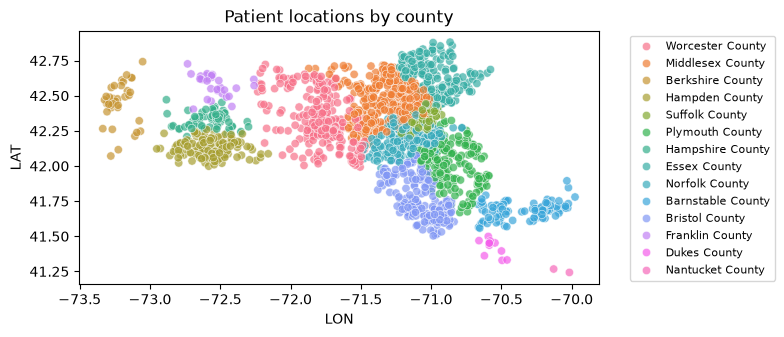

In [15]:
plt.figure(figsize=(8, 8))
sns.scatterplot(data=patients_df, x="LON", y="LAT", hue="COUNTY", alpha=0.7)
plt.gca().set_aspect("equal")  # equal degrees on both axes so the point cloud isn't visually stretched
plt.title("Patient locations by county")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

### EDA summary — key insights

- **2,338 patients, 338 deceased (~14%)** — `IS_DECEASED` should gate any age/expense analysis that shouldn't mix "current age" with "age at death."
- **Income is heavily right-skewed**: mean (\$111k) is well above the median (\$70k), pulled up by a max of \$989k. Prefer median over mean when summarizing income for a patient population.
- **`HEALTHCARE_COVERAGE`'s mean (\$350k) exceeds `HEALTHCARE_EXPENSES`'s mean (\$182k)**, and coverage's max (\$3.85M) dwarfs expenses' max (\$1.64M) — coverage is not a simple fraction of expenses in this dataset. Any "out-of-pocket" derivation (`EXPENSES - COVERAGE`) can go negative; treat it as a lifetime-cumulative payer figure, not a per-claim reimbursement.
- **`FIPS` is missing for 622/2,338 patients (~27%)**, all with `ZIP == 0` — a real gap tied to specific under-specified addresses, not random. Don't join on `FIPS` without checking for these rows.
- **`MARITAL` is null for 765/2,338 patients (~33%)** — almost certainly patients too young to have a marital status recorded, not missing data. Worth confirming against `AGE` before treating it as a data quality issue.
- **Patients cluster geographically by county** (see LAT/LON plot) — consistent with Synthea generating populations from fixed regional city/town seeds rather than a uniform spatial distribution across Massachusetts.

## Encounters

One row per clinical visit. Every clinical-event table (conditions, observations, medications, etc.) hangs off ENCOUNTER.

**Cost columns**
- BASE_ENCOUNTER_COST: flat facility fee for the encounter type (e.g. an ambulatory visit is always ~$85.55), independent of what happens during the visit.
- TOTAL_CLAIM_COST: everything billed for the encounter - the base fee plus every procedure, medication, immunization, device, etc. performed during it. Can run far above BASE_ENCOUNTER_COST.
- PAYER_COVERAGE: how much of TOTAL_CLAIM_COST the payer (insurer) actually covered. TOTAL_CLAIM_COST - PAYER_COVERAGE is the patient out-of-pocket cost for that encounter.

**ENCOUNTERCLASS values**
- ambulatory: non-admitted healthcare visit (you receive care without being admitted to a hospital)
- outpatient: a type of ambulatory care - a scheduled/planned service at a facility, same-day
- wellness: routine checkup / preventive visit
- inpatient: admitted, overnight-or-longer hospital stay
- emergency: ER visit
- urgentcare: walk-in urgent care clinic visit
- snf: skilled nursing facility care (post-acute recovery/rehab)
- hospice: end-of-life care
- home: care delivered at the patient's home
- virtual: telemedicine/remote visit

In [16]:
encounters_df = pd.read_csv('../synthea_data/output/csv/encounters.csv')
encounters_df

,Id,START,STOP,PATIENT,ORGANIZATION,PROVIDER,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,REASONCODE,REASONDESCRIPTION
0,c44d667b-15d5-99d4-9dc3-bb2d895495b9,1981-10-11T00:41:04Z,1981-10-11T01:06:02Z,c44d667b-15d5-99d4-0f69-43ca66739022,4ff8b164-4cf5-3ab4-b0f2-7ce8fda920e5,3166bff6-ecf5-3796-84c2-f3d90ffcd5ea,e03e23c9-4df1-3eb6-a62d-f70f02301496,wellness,410620009,Well child visit (procedure),136.80,1011.38,0.00,NaN,NaN
1,c44d667b-15d5-99d4-718f-134336f41a28,1983-10-23T00:41:04Z,1983-10-23T01:11:48Z,c44d667b-15d5-99d4-0f69-43ca66739022,4ff8b164-4cf5-3ab4-b0f2-7ce8fda920e5,3166bff6-ecf5-3796-84c2-f3d90ffcd5ea,e03e23c9-4df1-3eb6-a62d-f70f02301496,wellness,162673000,General examination of patient (procedure),136.80,1164.96,0.00,NaN,NaN
2,c44d667b-15d5-99d4-2c91-9fd0d8e38b98,1984-10-28T00:41:04Z,1984-10-28T01:16:53Z,c44d667b-15d5-99d4-0f69-43ca66739022,4ff8b164-4cf5-3ab4-b0f2-7ce8fda920e5,3166bff6-ecf5-3796-84c2-f3d90ffcd5ea,e03e23c9-4df1-3eb6-a62d-f70f02301496,wellness,162673000,General examination of patient (procedure),136.80,704.20,0.00,NaN,NaN
3,c44d667b-15d5-99d4-6280-d38ed9b4e5ac,1989-12-08T00:41:04Z,1989-12-08T00:56:04Z,c44d667b-15d5-99d4-0f69-43ca66739022,a2a41caf-758f-3962-8e5f-e6e603f93d17,de74b4c1-1b6d-3cc5-8d97-4b9d444a6748,e03e23c9-4df1-3eb6-a62d-f70f02301496,ambulatory,185345009,Encounter for symptom (procedure),85.55,92.93,0.00,75498004.00,Acute bacterial sinusitis (disorder)
4,c44d667b-15d5-99d4-db0e-663f459a4c7e,1997-07-10T00:41:04Z,1997-07-10T00:56:04Z,c44d667b-15d5-99d4-0f69-43ca66739022,a2a41caf-758f-3962-8e5f-e6e603f93d17,de74b4c1-1b6d-3cc5-8d97-4b9d444a6748,e03e23c9-4df1-3eb6-a62d-f70f02301496,ambulatory,424619006,Prenatal visit (regime/therapy),142.58,1005.38,0.00,156073000.00,Complete miscarriage (disorder)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138206,502dc964-df3b-7fa0-73ee-dbf877415a99,2025-12-14T01:10:17Z,2025-12-14T04:17:29Z,502dc964-df3b-7fa0-689e-78d3809a8df5,440fa4b8-c731-3cf5-81d9-aa3f30a37b95,5cdeccb6-c568-3206-b830-681487798473,a735bf55-83e9-331a-899d-a82a60b9f60c,ambulatory,185349003,Encounter for check up (procedure),85.55,3536.75,2829.40,103697008.00,Patient referral for dental care (procedure)
138207,502dc964-df3b-7fa0-fdd6-eba7b837e886,2025-12-21T01:10:17Z,2025-12-30T01:25:17Z,502dc964-df3b-7fa0-689e-78d3809a8df5,2e73956a-942f-36f3-b88c-f88e782e578f,941421d9-3343-3ad6-8e5b-31b1a806dd10,a735bf55-83e9-331a-899d-a82a60b9f60c,hospice,305336008,Admission to hospice (procedure),137.53,6177.13,4755.30,26929004.00,Alzheimer's disease (disorder)
138208,502dc964-df3b-7fa0-d044-a77766f658cb,2026-01-04T01:10:17Z,2026-01-04T01:25:17Z,502dc964-df3b-7fa0-689e-78d3809a8df5,440fa4b8-c731-3cf5-81d9-aa3f30a37b95,5cdeccb6-c568-3206-b830-681487798473,a735bf55-83e9-331a-899d-a82a60b9f60c,ambulatory,185345009,Encounter for symptom (procedure),85.55,85.55,68.44,444814009.00,Viral sinusitis (disorder)
138209,502dc964-df3b-7fa0-c09f-28f35610826e,2026-07-05T01:10:17Z,2026-07-05T01:47:54Z,502dc964-df3b-7fa0-689e-78d3809a8df5,7a75decf-7d3f-3b0d-8c2b-3abf0a8c7f58,9ecd2ae1-2878-3a54-93c2-ae106786378e,a735bf55-83e9-331a-899d-a82a60b9f60c,wellness,162673000,General examination of patient (procedure),136.80,919.90,735.92,NaN,NaN


### Data quality

In [17]:
encounters_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138211 entries, 0 to 138210
Data columns (total 15 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Id                   138211 non-null  object 
 1   START                138211 non-null  object 
 2   STOP                 138211 non-null  object 
 3   PATIENT              138211 non-null  object 
 4   ORGANIZATION         138211 non-null  object 
 5   PROVIDER             138211 non-null  object 
 6   PAYER                138211 non-null  object 
 7   ENCOUNTERCLASS       138211 non-null  object 
 8   CODE                 138211 non-null  int64  
 9   DESCRIPTION          138211 non-null  object 
 10  BASE_ENCOUNTER_COST  138211 non-null  float64
 11  TOTAL_CLAIM_COST     138211 non-null  float64
 12  PAYER_COVERAGE       138211 non-null  float64
 13  REASONCODE           87156 non-null   float64
 14  REASONDESCRIPTION    87156 non-null   object 
dtypes: float64(4), in

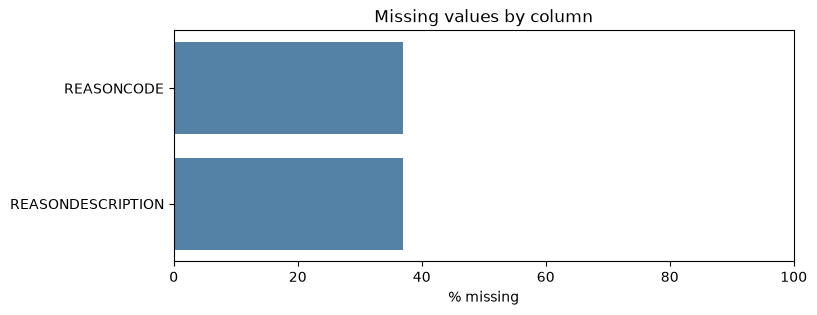

In [18]:
missing_pct = encounters_df.isna().mean().sort_values(ascending=False)
missing_pct = (missing_pct[missing_pct > 0] * 100).round(1)

plt.figure(figsize=(8, 3))
sns.barplot(x=missing_pct.values, y=missing_pct.index, color="steelblue")
plt.xlabel("% missing")
plt.xlim(0, 100)
plt.ylabel("")
plt.title("Missing values by column")
plt.show()

In [19]:
encounters_df['START'] = pd.to_datetime(encounters_df['START'])
encounters_df['STOP'] = pd.to_datetime(encounters_df['STOP'])
encounters_df['DURATION_MIN'] = (encounters_df['STOP'] - encounters_df['START']).dt.total_seconds() / 60

print('Non-positive duration rows:', (encounters_df['DURATION_MIN'] <= 0).sum())
encounters_df['DURATION_MIN'].describe()

Non-positive duration rows: 0


count   138211.00
mean       367.34
std       3167.73
min         15.00
25%         15.00
50%         45.57
75%        149.00
max     169130.00
Name: DURATION_MIN, dtype: float64

### Encounter classes

In [20]:
encounters_df.groupby('ENCOUNTERCLASS').size().reset_index(name='COUNT').sort_values(by='COUNT', ascending=False)

,ENCOUNTERCLASS,COUNT
0,ambulatory,76216
9,wellness,28666
5,outpatient,18262
7,urgentcare,6059
1,emergency,4836
4,inpatient,2433
2,home,682
3,hospice,366
8,virtual,361
6,snf,330


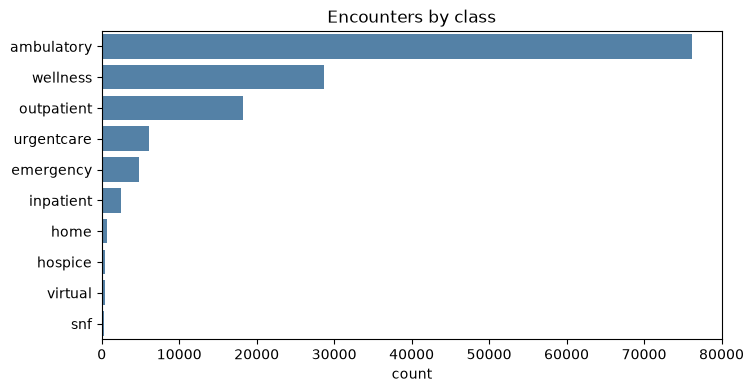

In [21]:
plt.figure(figsize=(8, 4))
order = encounters_df['ENCOUNTERCLASS'].value_counts().index
sns.countplot(data=encounters_df, y='ENCOUNTERCLASS', order=order, color='steelblue')
plt.title('Encounters by class')
plt.xlabel('count')
plt.ylabel('')
plt.show()

In [22]:
encounters_df.groupby(['CODE', 'DESCRIPTION']).size().reset_index(name='COUNT').sort_values(by='COUNT', ascending=False).reset_index(drop=True)

,CODE,DESCRIPTION,COUNT
0,185347001,Encounter for problem (procedure),36506
1,185349003,Encounter for check up (procedure),23078
2,162673000,General examination of patient (procedure),20790
3,185345009,Encounter for symptom (procedure),7731
4,410620009,Well child visit (procedure),7547
5,702927004,Urgent care clinic (environment),6020
6,424619006,Prenatal visit (regime/therapy),5771
7,308335008,Patient encounter procedure (procedure),4461
8,50849002,Emergency room admission (procedure),3630
9,390906007,Follow-up encounter (procedure),3391


In [23]:
enc_grouped = encounters_df.groupby(['ENCOUNTERCLASS', 'DESCRIPTION']).size().reset_index(name='COUNT')
enc_grouped.sort_values(['ENCOUNTERCLASS', 'COUNT'], ascending=[True, False]).reset_index(drop=True)

,ENCOUNTERCLASS,DESCRIPTION,COUNT
0,ambulatory,Encounter for problem (procedure),34626
1,ambulatory,Encounter for check up (procedure),14886
2,ambulatory,Encounter for symptom (procedure),7250
3,ambulatory,Prenatal visit (regime/therapy),5771
4,ambulatory,Follow-up encounter (procedure),3348
...,...,...,...
73,virtual,Discussion about treatment (procedure),1
74,wellness,General examination of patient (procedure),20790
75,wellness,Well child visit (procedure),7547
76,wellness,Death Certification,320


In [24]:
enc_grouped[enc_grouped['ENCOUNTERCLASS'] == 'ambulatory'].sort_values('COUNT', ascending=False)

,ENCOUNTERCLASS,DESCRIPTION,COUNT
6,ambulatory,Encounter for problem (procedure),34626
5,ambulatory,Encounter for check up (procedure),14886
7,ambulatory,Encounter for symptom (procedure),7250
24,ambulatory,Prenatal visit (regime/therapy),5771
9,ambulatory,Follow-up encounter (procedure),3348
15,ambulatory,Outpatient procedure (procedure),2621
27,ambulatory,Telemedicine consultation with patient (proced...,1819
14,ambulatory,Ophthalmic examination and evaluation (procedure),1460
23,ambulatory,Prenatal initial visit (regime/therapy),1034
21,ambulatory,Postoperative follow-up visit (procedure),659


### Costs & payer coverage

- PAYER_COVERAGE is how much of that specific encounter's TOTAL_CLAIM_COST the patient's payer (insurer) actually covered - i.e. the reimbursed portion. The difference TOTAL_CLAIM_COST - PAYER_COVERAGE is the patient's out-of-pocket cost for that encounter.
- BASE_ENCOUNTER_COST is just the flat visit/facility fee for that encounter type - a fixed rate tied to ENCOUNTERCLASS/CODE (e.g. "ambulatory visit" always costs $85.55 as a base fee, regardless of what happens during it). TOTAL_CLAIM_COST also bills every procedure/medication/etc. performed at the visit, so it can run far higher than the base fee.

In [25]:
encounters_df[['BASE_ENCOUNTER_COST', 'TOTAL_CLAIM_COST', 'PAYER_COVERAGE']].describe()

,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE
count,138211.00,138211.00,138211.00
mean,111.95,2800.89,2066.90
std,27.38,7441.37,6409.15
min,75.00,75.00,0.00
25%,85.55,535.87,0.00
50%,85.55,919.90,500.87
75%,142.58,2114.98,1364.03
max,146.18,317643.54,254114.50


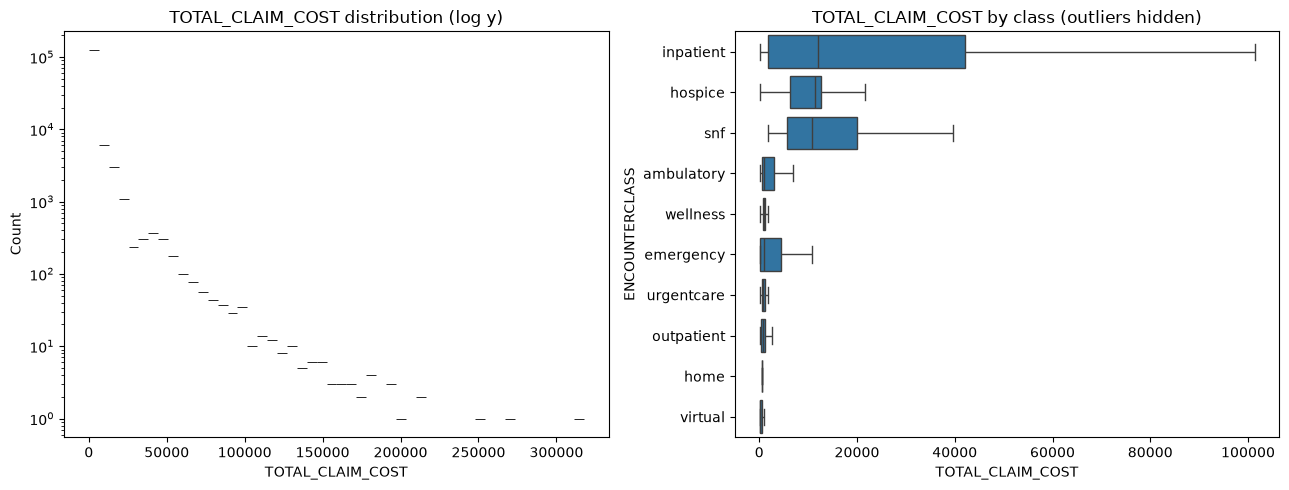

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(encounters_df['TOTAL_CLAIM_COST'], bins=50, log_scale=(False, True), ax=axes[0])
axes[0].set_title('TOTAL_CLAIM_COST distribution (log y)')

order = encounters_df.groupby('ENCOUNTERCLASS')['TOTAL_CLAIM_COST'].median().sort_values(ascending=False).index
sns.boxplot(data=encounters_df, x='TOTAL_CLAIM_COST', y='ENCOUNTERCLASS', order=order, ax=axes[1], showfliers=False)
axes[1].set_title('TOTAL_CLAIM_COST by class (outliers hidden)')

plt.tight_layout()
plt.show()

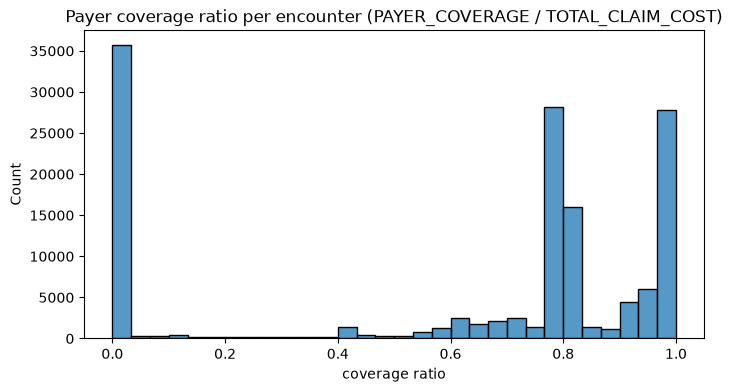

count   138211.00
mean         0.61
std          0.39
min          0.00
25%          0.00
50%          0.80
75%          0.93
max          1.00
Name: COVERAGE_RATIO, dtype: float64

In [27]:
# coverage ratio undefined (0/0) when TOTAL_CLAIM_COST is 0 - exclude those rather than treat as 0% covered
priced = encounters_df[encounters_df['TOTAL_CLAIM_COST'] > 0].copy()
priced['COVERAGE_RATIO'] = priced['PAYER_COVERAGE'] / priced['TOTAL_CLAIM_COST']

plt.figure(figsize=(8, 4))
sns.histplot(priced['COVERAGE_RATIO'], bins=30)
plt.title('Payer coverage ratio per encounter (PAYER_COVERAGE / TOTAL_CLAIM_COST)')
plt.xlabel('coverage ratio')
plt.show()

priced['COVERAGE_RATIO'].describe()

### Encounters per patient & over time

In [28]:
enc_per_patient = encounters_df.groupby('PATIENT').size()
enc_per_patient.describe()

count   2338.00
mean      59.12
std       90.80
min        1.00
25%       24.00
50%       36.00
75%       58.00
max      947.00
dtype: float64

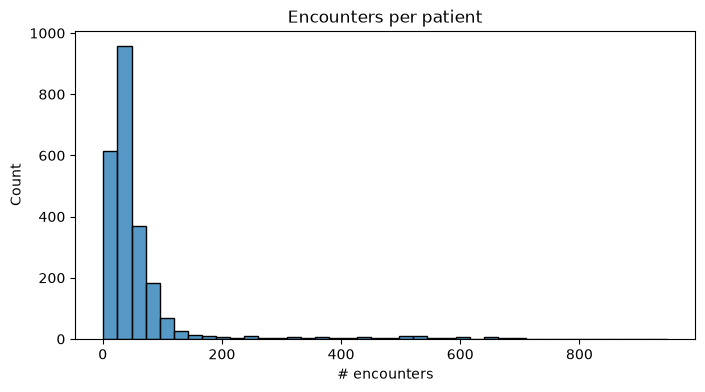

In [29]:
plt.figure(figsize=(8, 4))
sns.histplot(enc_per_patient, bins=40)
plt.title('Encounters per patient')
plt.xlabel('# encounters')
plt.show()

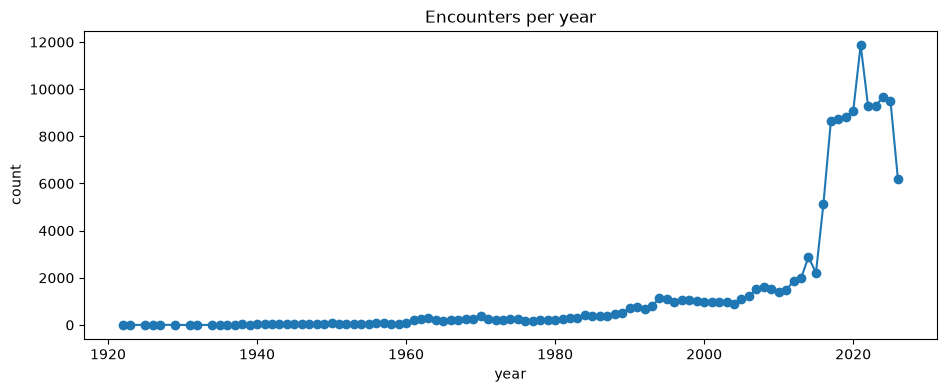

In [30]:
# 2026 is a partial year (data generated mid-year) - expect a dip, not a real trend reversal
yearly = encounters_df['START'].dt.year.value_counts().sort_index()

plt.figure(figsize=(11, 4))
yearly.plot(kind='line', marker='o')
plt.title('Encounters per year')
plt.xlabel('year')
plt.ylabel('count')
plt.show()

### Reason codes

In [31]:
has_reason = encounters_df['REASONCODE'].notna()
print(f'Overall: {has_reason.mean():.1%} of encounters carry a REASONCODE')
encounters_df.groupby('ENCOUNTERCLASS')['REASONCODE'].apply(lambda s: s.notna().mean()).sort_values(ascending=False).rename('PCT_WITH_REASON').round(3)

Overall: 63.1% of encounters carry a REASONCODE


ENCOUNTERCLASS
inpatient    1.00
home         1.00
snf          1.00
ambulatory   0.94
virtual      0.91
emergency    0.78
hospice      0.77
outpatient   0.40
wellness     0.01
urgentcare   0.01
Name: PCT_WITH_REASON, dtype: float64

In [32]:
encounters_df['REASONDESCRIPTION'].value_counts().head(15)

REASONDESCRIPTION
Chronic kidney disease stage 4 (disorder)       16691
End-stage renal disease (disorder)               7539
Normal pregnancy (finding)                       7128
Patient referral for dental care (procedure)     6756
Contraception care (regime/therapy)              6359
Gingivitis (disorder)                            6242
Dependent drug abuse (disorder)                  3815
Allergic disposition (finding)                   3130
Chronic congestive heart failure (disorder)      2539
Viral sinusitis (disorder)                       2430
Hyperlipidemia (disorder)                        2007
Chronic pain (finding)                           1461
Acute viral pharyngitis (disorder)               1391
Acute bronchitis (disorder)                      1228
Malignant neoplasm of breast (disorder)          1139
Name: count, dtype: int64

### EDA summary - key insights

- **REASONCODE/REASONDESCRIPTION are the only columns with nulls (36.9% missing)** - and it is structural, not random: `inpatient`, `home`, and `snf` encounters are 100% reasoned, `ambulatory` 94%, but `wellness` (1%) and `urgentcare` (1%) are almost never reasoned. Checkups and urgent-care visits do not carry a formal SNOMED reason code in this dataset - do not treat their missing REASONCODE as a data quality gap.
- **`ambulatory` (76,216) and `wellness` (28,666) dominate encounter volume** - together ~76% of all 138,211 encounters. `snf`/`hospice`/`virtual` are each under 400 rows; any per-class model or aggregate will be noisy for those classes at this population size.
- **`TOTAL_CLAIM_COST` is extremely right-skewed**: median $919.90 vs. mean $2,800.89 vs. max $317,643.54 (std $7,441 - larger than the mean). Always summarize with median/IQR, not mean, and use a log scale to visualize it.
- **Payer coverage ratio is bimodal, not a smooth distribution**: 0% at the 25th percentile but 80-93%+ from the median up - many encounters are billed with zero payer contribution (self-pay / pre-coverage / no-charge visit types) while the rest cluster near full reimbursement. A single "average coverage %" number would misrepresent this.
- **`DURATION_MIN` has a 15-minute floor and a 169,130-minute (~117 day) max** - no zero/negative durations, so START/STOP are internally consistent, but the extreme long tail (mean 367 min vs. median 45.6 min) is almost certainly multi-day `inpatient`/`snf`/`hospice` stays; filter or log-transform before using duration as a feature.
- **Encounters per patient range 1-947 (median 36, mean 59)** - heavily skewed by a handful of high-utilization patients (chronic disease / frequent dialysis, consistent with the top REASONDESCRIPTION values below). Per-patient aggregates should use median or cap outliers.
- **Top REASONDESCRIPTION values are dominated by chronic/recurring conditions**: Chronic kidney disease stage 4 (16,691), End-stage renal disease (7,539), Normal pregnancy (7,128), dental/contraception referrals, gingivitis. This is exactly the CKD/renal-failure population that backs the anchor "why did creatinine double" scenario - confirms there is enough encounter density around kidney disease to support that investigation.
- **2026 shows a dip in the yearly encounter trend** - expected, not a real drop: the data was generated mid-2026, so that year is a partial-year count, not a completed one.


## Organizations

Healthcare facilities/organizations. Every encounter FKs into this table via `ORGANIZATION`.

**UTILIZATION**: Synthea-generated counter meant to represent how many encounters have been billed through that organization. It's a synthetic proxy, not a real capacity metric - we cross-check it against actual encounter counts below rather than trusting it at face value.

In [33]:
organizations_df = pd.read_csv('../synthea_data/output/csv/organizations.csv')
organizations_df.head()

,Id,NAME,ADDRESS,CITY,STATE,ZIP,LAT,LON,PHONE,REVENUE,UTILIZATION
0,74ab949d-17ac-3309-83a0-13b4405c66aa,Fitchburg Outpatient Clinic,881 Main Street,Fitchburg,MA,1420,42.59,-71.81,978-342-9781 Or 978-342-9781,0.00,5527
1,da92d3fc-5445-3825-a937-043ef0d6ecd0,TRINITY HOME CARE INC.,336 GRATTAN ST,CHICOPEE,MA,10201314,42.17,-72.59,4033313294,0.00,96
2,588f6ce6-b8db-3588-8189-29db2680a313,BOSTON HEALTH CARE FOR THE HOMELESS PROGRAM INC,461 WALNUT AVE,JAMAICA PLAIN,MA,21302331,42.31,-71.10,8576541550,0.00,148
3,324b4137-57a0-3ae0-89db-1c33f57ae0c1,LOWN ACQUISITION LLC,134 NORTH ST,NORTH READING,MA,18641315,42.59,-71.11,7818262393,0.00,2
4,b6398e07-4967-31a5-807f-380039a1f303,EDWARD M KENNEDY COMMUNITY HEALTH CENTER INC,19 TACOMA ST,WORCESTER,MA,16053516,42.30,-71.77,5088521805,0.00,85


### Data quality

In [34]:
organizations_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 959 entries, 0 to 958
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Id           959 non-null    object 
 1   NAME         959 non-null    object 
 2   ADDRESS      959 non-null    object 
 3   CITY         959 non-null    object 
 4   STATE        959 non-null    object 
 5   ZIP          959 non-null    int64  
 6   LAT          959 non-null    float64
 7   LON          959 non-null    float64
 8   PHONE        959 non-null    object 
 9   REVENUE      959 non-null    float64
 10  UTILIZATION  959 non-null    int64  
dtypes: float64(3), int64(2), object(6)
memory usage: 82.5+ KB


In [35]:
dupe_ids = organizations_df['Id'].duplicated().sum()
print('Duplicate Id rows:', dupe_ids)
print('Unique orgs:', organizations_df['Id'].nunique(), '/', len(organizations_df))

Duplicate Id rows: 0
Unique orgs: 959 / 959


### Revenue & utilization

In [36]:
organizations_df[['REVENUE', 'UTILIZATION']].describe()

,REVENUE,UTILIZATION
count,959.00,959.00
mean,0.00,400.48
std,0.00,871.22
min,0.00,1.00
25%,0.00,14.00
50%,0.00,94.00
75%,0.00,335.50
max,0.00,9881.00


In [37]:
print('REVENUE == 0:', (organizations_df['REVENUE'] == 0).sum(), '/', len(organizations_df))
print('REVENUE unique values:', organizations_df['REVENUE'].nunique())

REVENUE == 0: 959 / 959
REVENUE unique values: 1


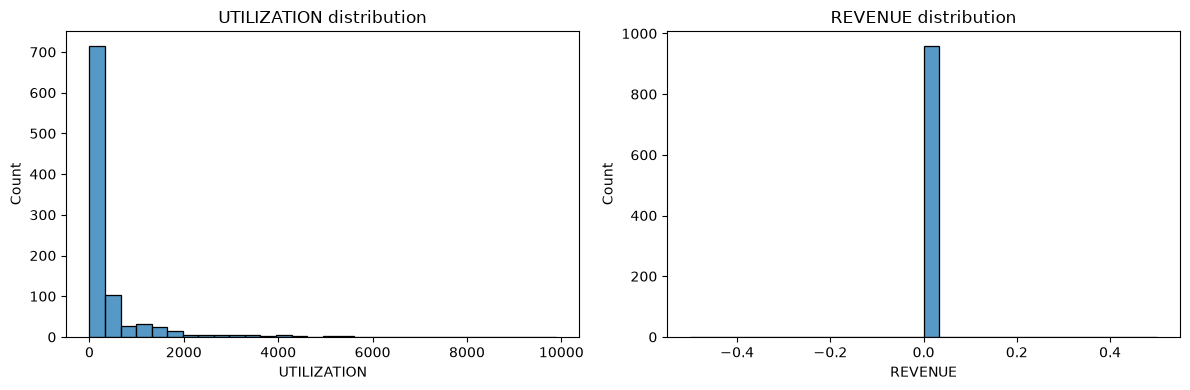

In [38]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(organizations_df['UTILIZATION'], bins=30, ax=ax[0])
ax[0].set_title('UTILIZATION distribution')
sns.histplot(organizations_df['REVENUE'], bins=30, ax=ax[1])
ax[1].set_title('REVENUE distribution')
plt.tight_layout()
plt.show()

### Geographic distribution

In [39]:
state_counts = organizations_df['STATE'].value_counts()
city_counts = organizations_df['CITY'].value_counts()
print('States:', state_counts.to_dict())
city_counts.head(10)

States: {'MA': 959}


CITY
WORCESTER        49
BOSTON           29
FALL RIVER       18
SPRINGFIELD      15
QUINCY           15
NORWOOD          14
BROCKTON         14
PLYMOUTH         13
PITTSFIELD       13
NORTH ANDOVER    13
Name: count, dtype: int64

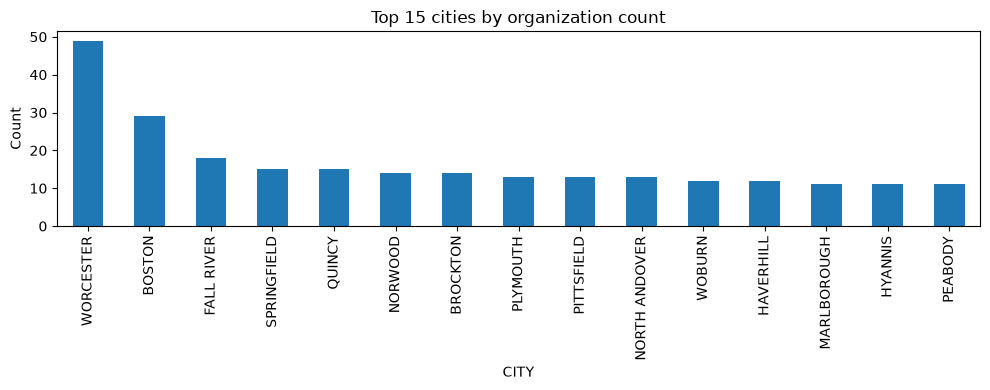

In [40]:
plt.figure(figsize=(10, 4))
city_counts.head(15).plot(kind='bar')
plt.title('Top 15 cities by organization count')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Referential integrity: organizations vs encounters

In [41]:
org_ids = set(organizations_df['Id'])
enc_org_ids = set(encounters_df['ORGANIZATION'])

print('Orgs referenced by encounters but missing from organizations_df:', len(enc_org_ids - org_ids))
print('Orgs in organizations_df with zero encounters:', len(org_ids - enc_org_ids), '/', len(org_ids))

Orgs referenced by encounters but missing from organizations_df: 0
Orgs in organizations_df with zero encounters: 87 / 959


### Utilization sanity check

Does the `UTILIZATION` column actually match real encounter counts per organization?

In [42]:
org_counts = encounters_df.groupby('ORGANIZATION').size().reset_index(name='COUNT')

util_check = organizations_df[['Id', 'NAME', 'UTILIZATION']].merge(
    org_counts, left_on='Id', right_on='ORGANIZATION', how='left'
)
util_check['COUNT'] = util_check['COUNT'].fillna(0)

mismatches = (util_check['UTILIZATION'] != util_check['COUNT']).sum()
print('Orgs where UTILIZATION != actual encounter count:', mismatches, '/', len(util_check))

high_util_orgs = util_check[util_check['UTILIZATION'] > util_check['COUNT']]
high_util_orgs[['NAME', 'COUNT', 'UTILIZATION']].sort_values('UTILIZATION', ascending=False).head(10)

Orgs where UTILIZATION != actual encounter count: 908 / 959


,NAME,COUNT,UTILIZATION
563,TEWKSBURY HOSPITAL,2967.00,9881
120,MELROSEWAKEFIELD HEALTHCARE INC,2093.00,6002
194,ENCOMPASS HEALTH REHAB HOSPITAL OF WESTERN MASS,1838.00,5842
0,Fitchburg Outpatient Clinic,4511.00,5527
163,BOSTON MEDICAL CENTER CORPORATION-,2302.00,5324
367,4499 ACUSHNET AVENUE OPERATING COMPANY LLC,1567.00,5302
600,CAPE COD HOSPITAL INC,1741.00,5205
842,ENCOMPASS HEALTH BRAINTREE HOSPITAL OF BRAINTREE,2204.00,5084
873,WHITTIER REHABILTATION HOSPITAL,1540.00,4964
820,HOLYOKE MEDICAL CENTER INC,1030.00,4701


### EDA summary - key insights

- **959 organizations, all unique** (`Id` has no duplicates) - clean dimension table.
- **`REVENUE` is a dead column** - every single row is `0.00` (1 unique value across 959 rows). Don't use it for anything; it's not populated by this Synthea export.
- **All organizations are in Massachusetts** (`STATE` is a constant `'MA'`) - expected, since that's the state used to generate this dataset. `CITY` has real spread: Worcester (49), Boston (29), Fall River (18) lead, but no single city dominates.
- **87 of 959 organizations (9%) have zero encounters** in this dataset - never actually used despite existing in the table. No orphaned `ORGANIZATION` values the other way (every encounter's org exists in this table).
- **`UTILIZATION` does not match actual encounter counts, and it's not just noisy - it's systematically inflated.** 908/959 orgs (95%) have `UTILIZATION > COUNT`, zero have `UTILIZATION < COUNT`, and only 51 match exactly. Where it doesn't match, `UTILIZATION` runs ~3.3x the real encounter count on average (up to 25x for the most extreme organization). This isn't random measurement error - it's a one-directional gap, consistent with `UTILIZATION` counting something broader than encounters (e.g. every clinical event/service line rather than one count per visit), or being carried over from a larger reference population than this specific export's patients. **Treat `UTILIZATION` as directionally indicative at best, not a reliable count - always derive real encounter volume from `encounters_df` directly.**


## Providers

Individual clinicians. Every encounter FKs into this table via `PROVIDER`, and each provider belongs to exactly one organization via `ORGANIZATION`.

In [43]:
providers_df = pd.read_csv('../synthea_data/output/csv/providers.csv')
providers_df

,Id,ORGANIZATION,NAME,GENDER,SPECIALITY,ADDRESS,CITY,STATE,ZIP,LAT,LON,ENCOUNTERS,PROCEDURES
0,de2a6da5-19e6-3a94-800f-b2df7cc0690b,74ab949d-17ac-3309-83a0-13b4405c66aa,Manuela585 Rendón540,F,GENERAL PRACTICE,881 Main Street,Fitchburg,MA,1420,42.59,-71.81,5527,0
1,bcacc312-de44-3e22-89fc-91b3fe6ffea2,da92d3fc-5445-3825-a937-043ef0d6ecd0,Danyel335 Cruickshank494,F,GENERAL PRACTICE,336 GRATTAN ST,CHICOPEE,MA,10201314,42.17,-72.59,96,0
2,8b0634ef-654c-38b3-ad9f-ef085ec30ef7,588f6ce6-b8db-3588-8189-29db2680a313,Tiffaney302 Brakus656,F,GENERAL PRACTICE,461 WALNUT AVE,JAMAICA PLAIN,MA,21302331,42.31,-71.10,148,0
3,b4cb1936-88ff-31e7-a4ef-32e75915dd5d,324b4137-57a0-3ae0-89db-1c33f57ae0c1,Marquis364 Satterfield305,M,GENERAL PRACTICE,134 NORTH ST,NORTH READING,MA,18641315,42.59,-71.11,2,0
4,fdca8c7a-5d2c-39aa-a8e5-b4458cd59034,b6398e07-4967-31a5-807f-380039a1f303,Aleen595 Lueilwitz711,F,GENERAL PRACTICE,19 TACOMA ST,WORCESTER,MA,16053516,42.30,-71.77,85,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
954,f00d6994-6108-3739-b1f5-797460b0f970,ba07b31b-bf14-39b8-be95-4c5ca5062daa,Hermelinda327 Hyatt152,F,GENERAL PRACTICE,1575 CAMBRIDGE ST,CAMBRIDGE,MA,21384308,42.38,-71.11,1407,0
955,8a8db7a4-5587-3b4b-8c97-47064ede020a,064ba8c8-f6f7-3582-8f41-c963ceedfee4,Lexie163 Ankunding277,F,GENERAL PRACTICE,500 BELMONT STREET,BROCKTON,MA,23014985,42.07,-71.04,10,0
956,3e435e1b-593f-3a3f-84b2-0e34cbb4068f,6aae7a31-90df-3455-ad8d-81f8cf2d21e8,Houston994 Funk324,M,GENERAL PRACTICE,680 CENTRE ST,BROCKTON,MA,23023308,42.09,-70.99,1917,0
957,d6dc0ca3-c333-3df7-a764-530792fc7969,14036728-b721-3e4b-8755-8ee8ab6ed15e,Melodie819 Schmeler639,F,GENERAL PRACTICE,625 MOUNT AUBURN ST,CAMBRIDGE,MA,21384518,42.38,-71.15,557,0


### Data quality

In [44]:
providers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 959 entries, 0 to 958
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            959 non-null    object 
 1   ORGANIZATION  959 non-null    object 
 2   NAME          959 non-null    object 
 3   GENDER        959 non-null    object 
 4   SPECIALITY    959 non-null    object 
 5   ADDRESS       959 non-null    object 
 6   CITY          959 non-null    object 
 7   STATE         959 non-null    object 
 8   ZIP           959 non-null    int64  
 9   LAT           959 non-null    float64
 10  LON           959 non-null    float64
 11  ENCOUNTERS    959 non-null    int64  
 12  PROCEDURES    959 non-null    int64  
dtypes: float64(2), int64(3), object(8)
memory usage: 97.5+ KB


In [45]:
dupe_ids = providers_df['Id'].duplicated().sum()
print('Duplicate Id rows:', dupe_ids)
print('Unique providers:', providers_df['Id'].nunique(), '/', len(providers_df))
print('Null counts:')
print(providers_df.isna().sum())

Duplicate Id rows: 0
Unique providers: 959 / 959
Null counts:
Id              0
ORGANIZATION    0
NAME            0
GENDER          0
SPECIALITY      0
ADDRESS         0
CITY            0
STATE           0
ZIP             0
LAT             0
LON             0
ENCOUNTERS      0
PROCEDURES      0
dtype: int64


### Speciality & procedures - dead columns

In [46]:
print('Unique SPECIALITY values:', providers_df['SPECIALITY'].unique())
print('Unique PROCEDURES values:', providers_df['PROCEDURES'].unique())

Unique SPECIALITY values: ['GENERAL PRACTICE']
Unique PROCEDURES values: [0]


`SPECIALITY` is a constant `'GENERAL PRACTICE'` across all 959 providers, and `PROCEDURES` is a constant `0`. Both are dead columns in this export - don't branch on either.

### Gender & geography

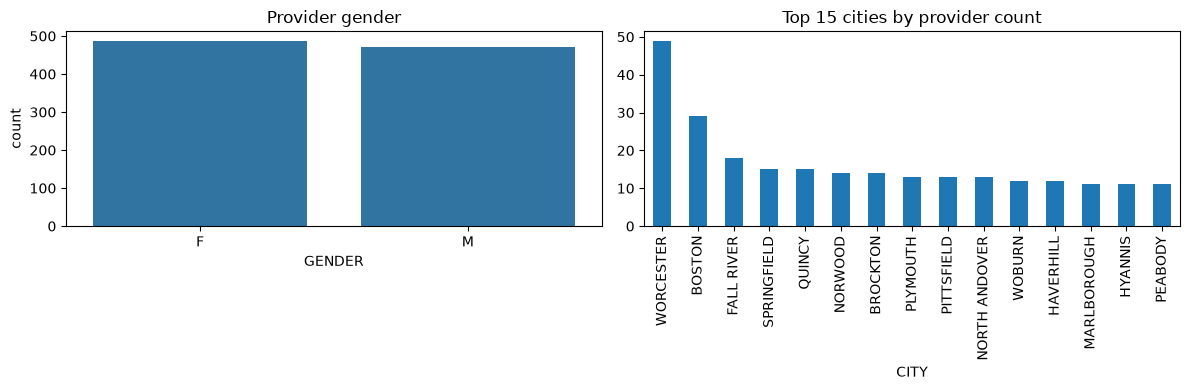

In [47]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=providers_df, x='GENDER', ax=ax[0])
ax[0].set_title('Provider gender')
providers_df['CITY'].value_counts().head(15).plot(kind='bar', ax=ax[1])
ax[1].set_title('Top 15 cities by provider count')
plt.tight_layout()
plt.show()

In [48]:
print('STATE values:', providers_df['STATE'].unique())

STATE values: ['MA']


### Provider <-> organization cardinality

In [49]:
provider_org_counts = providers_df.groupby('ORGANIZATION').size()
print('Providers per organization - value counts:')
print(provider_org_counts.value_counts())

org_ids = set(organizations_df['Id'])
provider_org_ids = set(providers_df['ORGANIZATION'])
print('Orgs with no provider:', len(org_ids - provider_org_ids))
print('Providers pointing at an org missing from organizations_df:', len(provider_org_ids - org_ids))

Providers per organization - value counts:
1    959
Name: count, dtype: int64
Orgs with no provider: 0
Providers pointing at an org missing from organizations_df: 0


### Provider workload

Who is actually handling the most encounters and the most distinct patients - using real `encounters_df` counts, not the inflated `ENCOUNTERS` column.

In [50]:
provider_workload = encounters_df.groupby('PROVIDER').size().reset_index(name='ENCOUNTER_COUNT')
provider_patients = encounters_df.groupby('PROVIDER')['PATIENT'].nunique().reset_index(name='PATIENT_COUNT')
provider_workload = provider_workload.merge(provider_patients, on='PROVIDER')
provider_workload = provider_workload.merge(providers_df[['Id', 'NAME', 'ORGANIZATION']], left_on='PROVIDER', right_on='Id')
provider_workload['ENCOUNTERS_PER_PATIENT'] = provider_workload['ENCOUNTER_COUNT'] / provider_workload['PATIENT_COUNT']

print(provider_workload[['ENCOUNTER_COUNT', 'PATIENT_COUNT', 'ENCOUNTERS_PER_PATIENT']].describe())
provider_workload.sort_values('PATIENT_COUNT', ascending=False).head(10)[['NAME', 'PATIENT_COUNT', 'ENCOUNTER_COUNT', 'ENCOUNTERS_PER_PATIENT']]

       ENCOUNTER_COUNT  PATIENT_COUNT  ENCOUNTERS_PER_PATIENT
count           872.00         872.00                  872.00
mean            158.50           9.57                   14.30
std             364.01          19.74                   32.74
min               1.00           1.00                    1.00
25%              11.00           2.00                    2.00
50%              37.00           5.00                   10.22
75%             124.25          11.00                   13.89
max            4511.00         496.00                  506.00


,NAME,PATIENT_COUNT,ENCOUNTER_COUNT,ENCOUNTERS_PER_PATIENT
748,Manuela585 Rendón540,496,4511,9.09
582,Carlton317 Koch169,84,2967,35.32
271,Anderson154 Lemke654,82,652,7.95
81,Kyoko885 Price929,81,727,8.98
122,Florencia449 Araña824,70,361,5.16
537,Jewel43 Kassulke119,66,426,6.45
79,Brian582 Cummerata161,61,437,7.16
237,Jolie499 Parisian75,54,390,7.22
700,Arden380 Bergstrom287,50,1741,34.82
506,Zachery872 Pagac496,50,2093,41.86


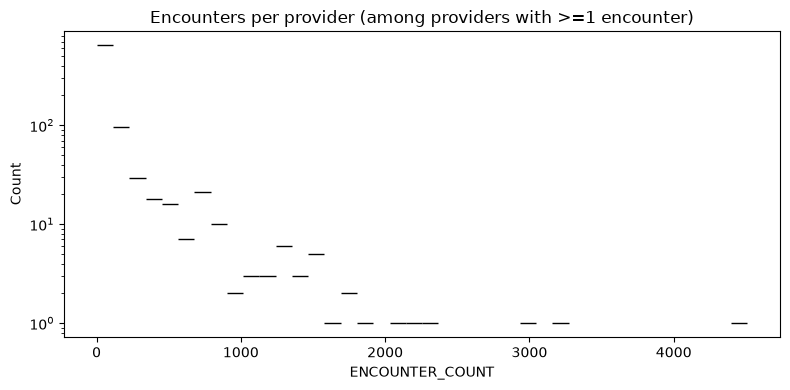

In [51]:
plt.figure(figsize=(8, 4))
sns.histplot(provider_workload['ENCOUNTER_COUNT'], bins=40, log_scale=(False, True))
plt.title('Encounters per provider (among providers with >=1 encounter)')
plt.xlabel('ENCOUNTER_COUNT')
plt.tight_layout()
plt.show()

The top provider by both encounters and distinct patients is the same person, and by a wide margin - roughly 6x the #2 provider on patient count. That is too dominant to be a normal single-clinician panel; treat it as a likely default/catch-all provider assignment in this Synthea export rather than a realistic workload, and do not use it as a representative data point for per-provider analysis.

### Referential integrity & ENCOUNTERS sanity check vs. encounters_df

In [52]:
provider_ids = set(providers_df['Id'])
enc_provider_ids = set(encounters_df['PROVIDER'])

print('Providers referenced by encounters but missing from providers_df:', len(enc_provider_ids - provider_ids))
print('Providers in providers_df with zero encounters:', len(provider_ids - enc_provider_ids), '/', len(provider_ids))

Providers referenced by encounters but missing from providers_df: 0
Providers in providers_df with zero encounters: 87 / 959


In [53]:
enc_counts = encounters_df.groupby('PROVIDER').size().reset_index(name='COUNT')

util_check = providers_df[['Id', 'NAME', 'ENCOUNTERS']].merge(enc_counts, left_on='Id', right_on='PROVIDER', how='left')
util_check['COUNT'] = util_check['COUNT'].fillna(0)

mismatches = (util_check['ENCOUNTERS'] != util_check['COUNT']).sum()
print('Providers where ENCOUNTERS != actual encounter count:', mismatches, '/', len(util_check))

ratio = util_check.loc[util_check['ENCOUNTERS'] > util_check['COUNT'], 'ENCOUNTERS'] / util_check.loc[util_check['ENCOUNTERS'] > util_check['COUNT'], 'COUNT'].replace(0, 1)
print('Avg inflation ratio where mismatched:', round(ratio.mean(), 2), ' max:', ratio.max())

util_check.sort_values('ENCOUNTERS', ascending=False).head(10)[['NAME', 'COUNT', 'ENCOUNTERS']]

Providers where ENCOUNTERS != actual encounter count: 908 / 959
Avg inflation ratio where mismatched: 3.62  max: 50.0


,NAME,COUNT,ENCOUNTERS
563,Carlton317 Koch169,2967.00,9881
120,Zachery872 Pagac496,2093.00,6002
194,Miyoko154 Paucek755,1838.00,5842
0,Manuela585 Rendón540,4511.00,5527
163,Sharron285 Batz141,2302.00,5324
367,Clifton91 Lakin515,1567.00,5302
600,Arden380 Bergstrom287,1741.00,5205
842,Nickolas58 Schumm995,2204.00,5084
873,Vicente970 Alonzo487,1540.00,4964
820,Kala987 Wolf938,1030.00,4701


### EDA summary - key insights

- **959 providers, all unique** (`Id` has no duplicates), no nulls anywhere - clean dimension table.
- **`SPECIALITY` and `PROCEDURES` are dead columns** - `SPECIALITY` is a constant `'GENERAL PRACTICE'` and `PROCEDURES` is a constant `0` across every row. Don't design any logic (e.g. RBAC scoping, specialty filters) around specialty diversity - it doesn't exist in this Synthea export.
- **Gender is roughly balanced** (488 F / 471 M). **State is a constant `'MA'`**, consistent with the organizations table.
- **Exactly 1:1 provider-to-organization mapping** - every one of the 959 organizations has exactly one provider, and every provider's `ORGANIZATION` resolves to a real row in `organizations_df`. No orphans either direction.
- **No orphaned `PROVIDER` values in encounters** - every provider referenced by an encounter exists in `providers_df`. 87/959 providers (9%) have zero encounters (the same providers as the orgs with zero encounters, given the 1:1 mapping).
- **Provider workload is heavily skewed**: among the 872 providers who've actually seen patients, the median is only 5 distinct patients / 37 encounters, but the top provider (Manuela585 Rendón540) has 496 distinct patients and 4,511 encounters - roughly 6x the #2 provider on patient count (84) and 1.5x on encounter count (2,967). `ENCOUNTERS_PER_PATIENT` for that provider is a plausible 9.09, so it's not simply duplicated rows - but the sheer scale relative to everyone else strongly suggests this is a default/catch-all provider assignment in the Synthea generator, not a realistic single-clinician panel. Exclude or flag it separately in any per-provider modeling.
- **`ENCOUNTERS` is inflated the same way `organizations.UTILIZATION` was** - 908/959 providers (95%) have `ENCOUNTERS > COUNT` (actual encounter rows), zero have the reverse, and the gap runs ~3.6x on average (up to 50x for the most extreme provider). Same one-directional, systematic overcount pattern seen in the organizations table - **always derive real encounter/patient volume from `encounters_df` directly, never from `providers_df.ENCOUNTERS`.**


## Conditions

One row per diagnosed condition/finding, SNOMED-coded. `STOP` is null when the condition is still active as of data generation - that's the chronic/ongoing flag, not missing data. Synthea also encodes social/administrative findings as "conditions" (e.g. `Full-time employment (finding)`, `Medication review due (situation)`) alongside true disorders - filter on the `(disorder)` suffix in `DESCRIPTION` when a question is specifically about disease, not general findings.

In [54]:
conditions_df = pd.read_csv('../synthea_data/output/csv/conditions.csv', parse_dates=['START', 'STOP'],
)
conditions_df

,START,STOP,PATIENT,ENCOUNTER,SYSTEM,CODE,DESCRIPTION
0,1981-10-11,NaT,c44d667b-15d5-99d4-0f69-43ca66739022,c44d667b-15d5-99d4-9dc3-bb2d895495b9,http://snomed.info/sct,160968000,Risk activity involvement (finding)
1,1983-10-23,NaT,c44d667b-15d5-99d4-0f69-43ca66739022,c44d667b-15d5-99d4-718f-134336f41a28,http://snomed.info/sct,224299000,Received higher education (finding)
2,1983-10-23,NaT,c44d667b-15d5-99d4-0f69-43ca66739022,c44d667b-15d5-99d4-718f-134336f41a28,http://snomed.info/sct,266934004,Transport problem (finding)
3,1984-10-28,NaT,c44d667b-15d5-99d4-0f69-43ca66739022,c44d667b-15d5-99d4-2c91-9fd0d8e38b98,http://snomed.info/sct,713458007,Lack of access to transportation (finding)
4,1989-12-08,NaT,c44d667b-15d5-99d4-0f69-43ca66739022,c44d667b-15d5-99d4-6280-d38ed9b4e5ac,http://snomed.info/sct,40055000,Chronic sinusitis (disorder)
...,...,...,...,...,...,...,...
85001,2025-11-30,2026-07-05,502dc964-df3b-7fa0-689e-78d3809a8df5,502dc964-df3b-7fa0-4d8f-f9dd275d425f,http://snomed.info/sct,160904001,Part-time employment (finding)
85002,2025-12-07,2026-07-05,502dc964-df3b-7fa0-689e-78d3809a8df5,502dc964-df3b-7fa0-6d66-78d033337adf,http://snomed.info/sct,314529007,Medication review due (situation)
85003,2025-12-14,2025-12-14,502dc964-df3b-7fa0-689e-78d3809a8df5,502dc964-df3b-7fa0-73ee-dbf877415a99,http://snomed.info/sct,278598003,Leaking dental filling (finding)
85004,2026-01-04,2026-01-14,502dc964-df3b-7fa0-689e-78d3809a8df5,502dc964-df3b-7fa0-d044-a77766f658cb,http://snomed.info/sct,444814009,Viral sinusitis (disorder)


### Data quality

In [55]:
conditions_df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85006 entries, 0 to 85005
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   START        85006 non-null  datetime64[ns]
 1   STOP         63272 non-null  datetime64[ns]
 2   PATIENT      85006 non-null  object        
 3   ENCOUNTER    85006 non-null  object        
 4   SYSTEM       85006 non-null  object        
 5   CODE         85006 non-null  int64         
 6   DESCRIPTION  85006 non-null  object        
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 4.5+ MB


In [56]:
missing_pct = conditions_df.isna().mean().sort_values(ascending=False)
missing_pct = (missing_pct[missing_pct > 0] * 100).round(1)
print(missing_pct)

# STOP is the only nullable column, and it's structural (see markdown above),
# not a data quality gap - confirm no other column carries nulls.
print('SYSTEM is constant:', conditions_df['SYSTEM'].nunique() == 1, conditions_df['SYSTEM'].unique())

STOP   25.60
dtype: float64
SYSTEM is constant: True ['http://snomed.info/sct']


### Chronic vs. resolved conditions

In [57]:
conditions_df['IS_CHRONIC'] = conditions_df['STOP'].isna()
print(conditions_df['IS_CHRONIC'].value_counts())
print(f"{conditions_df['IS_CHRONIC'].mean():.1%} of condition rows are still active (no STOP)")

IS_CHRONIC
False    63272
True     21734
Name: count, dtype: int64
25.6% of condition rows are still active (no STOP)


In [58]:
resolved = conditions_df[~conditions_df['IS_CHRONIC']].copy()
resolved['DURATION_DAYS'] = (resolved['STOP'] - resolved['START']).dt.days
print('negative-duration rows:', (resolved['DURATION_DAYS'] < 0).sum())
resolved['DURATION_DAYS'].describe()

negative-duration rows: 0


count   63272.00
mean      344.76
std       883.33
min         0.00
25%        10.00
50%        31.00
75%       371.00
max     28504.00
Name: DURATION_DAYS, dtype: float64

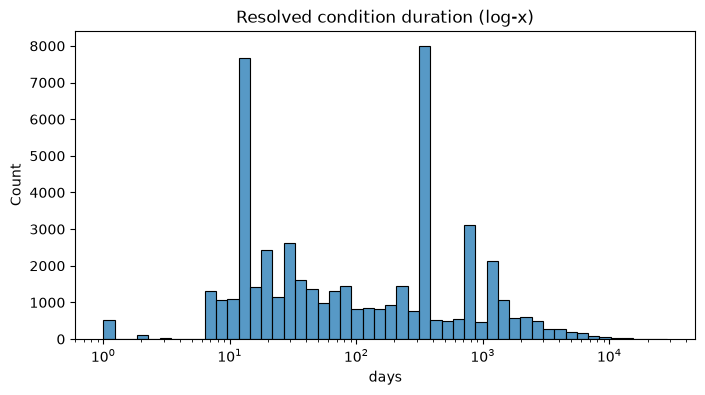

In [59]:
plt.figure(figsize=(8, 4))
sns.histplot(resolved['DURATION_DAYS'], bins=50, log_scale=(True, False))
plt.title('Resolved condition duration (log-x)')
plt.xlabel('days')
plt.show()

### Top conditions

In [60]:
conditions_df.groupby('DESCRIPTION').size().reset_index(name='COUNT').sort_values(by='COUNT', ascending=False).head(15)

,DESCRIPTION,COUNT
167,Medication review due (situation),16831
261,Stress (finding),6571
108,Gingivitis (disorder),6384
104,Full-time employment (finding),6153
200,Part-time employment (finding),3739
281,Viral sinusitis (disorder),2399
158,Limited social contact (finding),2328
250,Social isolation (finding),2324
188,Not in labor force (finding),2136
107,Gingival disease (disorder),1852


In [61]:
# same ranking restricted to conditions that are still active (a cleaner view of
# ongoing disease burden than the overall top list, which is dominated by
# short-lived administrative/screening findings)
conditions_df[conditions_df['IS_CHRONIC']].groupby('DESCRIPTION').size().reset_index(name='COUNT').sort_values(by='COUNT', ascending=False).head(15)

,DESCRIPTION,COUNT
126,Medication review due (situation),1284
76,Full-time employment (finding),1281
174,Received higher education (finding),1148
26,Body mass index 30+ - obesity (finding),1135
203,Stress (finding),1065
164,Prediabetes (finding),876
15,Anemia (disorder),803
44,Chronic pain (finding),580
65,Essential hypertension (disorder),549
62,Educated to high school level (finding),512


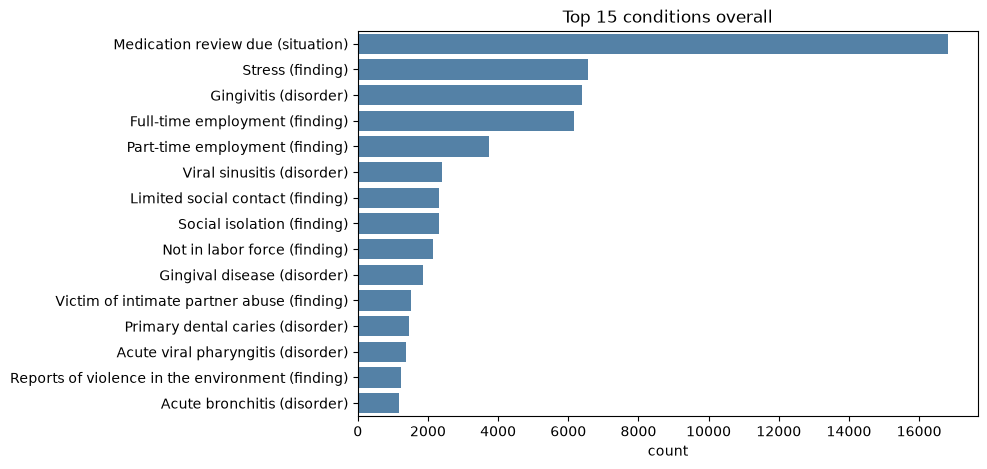

In [62]:
top15 = conditions_df['DESCRIPTION'].value_counts().head(15)
plt.figure(figsize=(8, 5))
sns.barplot(x=top15.values, y=top15.index, color='steelblue')
plt.xlabel('count')
plt.ylabel('')
plt.title('Top 15 conditions overall')
plt.show()

### Conditions per patient & per visit

In [63]:
conditions_per_patient = conditions_df.groupby('PATIENT').size()
conditions_per_patient.describe()

count   2338.00
mean      36.36
std       36.72
min        1.00
25%       19.00
50%       29.00
75%       40.00
max      472.00
dtype: float64

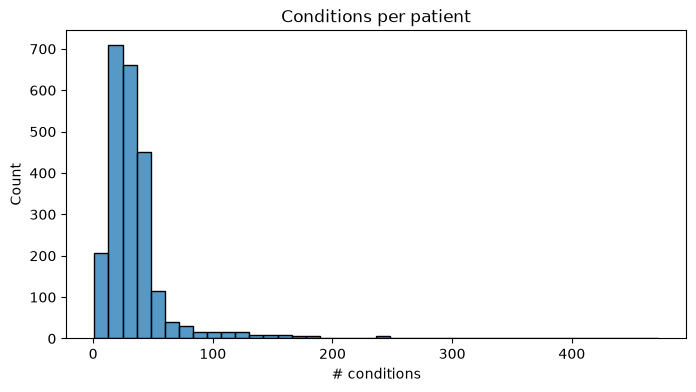

In [64]:
plt.figure(figsize=(8, 4))
sns.histplot(conditions_per_patient, bins=40)
plt.title('Conditions per patient')
plt.xlabel('# conditions')
plt.show()

In [65]:
# population-level average conditions per visit (each visit weighted equally)
conditions_per_visit_pop = conditions_df.groupby('ENCOUNTER').size()
conditions_per_visit_pop.describe()

count   54493.00
mean        1.56
std         0.89
min         1.00
25%         1.00
50%         1.00
75%         2.00
max        11.00
dtype: float64

In [66]:
# patient-level average conditions per visit (each patient weighted equally,
# not each visit) - per patient, how many conditions are identified on average in a visit
conditions_per_visit = conditions_df.groupby(['PATIENT', 'ENCOUNTER']).size().reset_index(name='COUNT')
avg_conditions_per_visit = conditions_per_visit.groupby('PATIENT')['COUNT'].mean().reset_index(name='AVG_CONDITIONS_PER_VISIT')
avg_conditions_per_visit['AVG_CONDITIONS_PER_VISIT'].describe()

count   2338.00
mean       1.52
std        0.28
min        1.00
25%        1.36
50%        1.54
75%        1.70
max        2.82
Name: AVG_CONDITIONS_PER_VISIT, dtype: float64

### Conditions over time

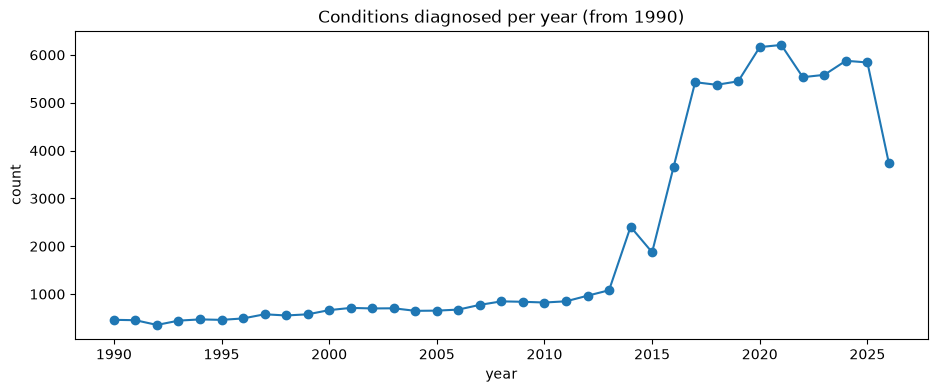

In [67]:
# earliest years (back to the 1920s) are single-digit-row artifacts of synthetic
# birth-year backdating, not real historical records; 2026 is a partial year
yearly = conditions_df['START'].dt.year.value_counts().sort_index()

plt.figure(figsize=(11, 4))
yearly[yearly.index >= 1990].plot(kind='line', marker='o')
plt.title('Conditions diagnosed per year (from 1990)')
plt.xlabel('year')
plt.ylabel('count')
plt.show()

### EDA summary - key insights

- **85,006 condition rows across 2,338 patients, 285 distinct SNOMED descriptions** - `SYSTEM` is a constant `http://snomed.info/sct` across every row.
- **`STOP` is the only nullable column (25.6% missing, 21,734 rows)** - and it's structural, not a data quality gap: null `STOP` means the condition is still active as of data generation, not a lost value.
- **Among resolved conditions, duration is extremely right-skewed**: median 31 days vs. mean 344.8 days (max 28,504 days, ~78 years). Summarize with median, not mean, and use a log scale.
- **The overall top-conditions list is dominated by administrative/screening findings, not disease**: `Medication review due (situation)` (16,831), `Stress (finding)` (6,571), `Gingivitis (disorder)` (6,384), `Full-time employment (finding)` (6,153). Filter to `(disorder)` codes, or to `IS_CHRONIC`, when a question is specifically about ongoing disease burden.
- **Restricting to chronic (never-resolved) conditions changes the ranking entirely** - obesity (BMI 30+, 1,135), prediabetes (876), anemia (803), and essential hypertension (549) rise to the top, a much better proxy for real chronic disease prevalence than the raw DESCRIPTION counts.
- **36.4 conditions per patient on average (median 29, range 1-472)** - the same high-utilization outlier pattern seen in the Encounters section (patients with hundreds of conditions are the same cohort driving hundreds of encounters).
- **Conditions per visit: ~1.5 either way you weight it** - population-level (every visit weighted equally) averages 1.56/visit across 54,493 encounters that have at least one condition; patient-level (every patient weighted equally) averages 1.52. The two metrics are close here because most patients cluster tightly around 1-2 conditions/visit, unlike a metric with more per-patient spread where the two would diverge (see the discussion above about why they can differ).
- **2026 shows a partial-year dip, same as Encounters** - expected, since the data was generated mid-2026.

## Observations

Labs, vitals, and structured survey responses - one row per measurement/response, not a free-text clinical note (there are none in this dataset, see design doc). `TYPE == 'numeric'` is what you'd trend (e.g. creatinine); `TYPE == 'text'` rows are structured survey fields (e.g. "Housing status: rents"), not prose.

In [68]:
observations_df = pd.read_csv(
    '../synthea_data/output/csv/observations.csv',
    parse_dates=['DATE'],
)
observations_df

,DATE,PATIENT,ENCOUNTER,CATEGORY,CODE,DESCRIPTION,VALUE,UNITS,TYPE
0,2017-04-05 17:21:52+00:00,51c5e2a9-2833-5133-b85a-329b9cd53c41,51c5e2a9-2833-5133-605d-195295cdc3b1,vital-signs,8302-2,Body Height,168.1,cm,numeric
1,2016-09-04 00:41:04+00:00,c44d667b-15d5-99d4-0f69-43ca66739022,c44d667b-15d5-99d4-44d7-8f6b4ce95182,vital-signs,8302-2,Body Height,165.0,cm,numeric
2,2017-04-05 17:21:52+00:00,51c5e2a9-2833-5133-b85a-329b9cd53c41,51c5e2a9-2833-5133-605d-195295cdc3b1,vital-signs,72514-3,Pain severity - 0-10 verbal numeric rating [Sc...,1.0,{score},numeric
3,2016-09-04 00:41:04+00:00,c44d667b-15d5-99d4-0f69-43ca66739022,c44d667b-15d5-99d4-44d7-8f6b4ce95182,vital-signs,72514-3,Pain severity - 0-10 verbal numeric rating [Sc...,2.0,{score},numeric
4,2017-04-05 17:21:52+00:00,51c5e2a9-2833-5133-b85a-329b9cd53c41,51c5e2a9-2833-5133-605d-195295cdc3b1,vital-signs,29463-7,Body Weight,85.4,kg,numeric
...,...,...,...,...,...,...,...,...,...
1764295,2021-12-15 01:10:17+00:00,502dc964-df3b-7fa0-689e-78d3809a8df5,NaN,NaN,QOLS,QOLS,1.0,{score},numeric
1764296,2022-12-15 01:10:17+00:00,502dc964-df3b-7fa0-689e-78d3809a8df5,NaN,NaN,QOLS,QOLS,1.0,{score},numeric
1764297,2023-12-15 01:10:17+00:00,502dc964-df3b-7fa0-689e-78d3809a8df5,NaN,NaN,QOLS,QOLS,1.0,{score},numeric
1764298,2024-12-15 01:10:17+00:00,502dc964-df3b-7fa0-689e-78d3809a8df5,NaN,NaN,QOLS,QOLS,1.0,{score},numeric


### Data quality

In [69]:
observations_df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1764300 entries, 0 to 1764299
Data columns (total 9 columns):
 #   Column       Non-Null Count    Dtype              
---  ------       --------------    -----              
 0   DATE         1764300 non-null  datetime64[ns, UTC]
 1   PATIENT      1764300 non-null  object             
 2   ENCOUNTER    1701330 non-null  object             
 3   CATEGORY     1701330 non-null  object             
 4   CODE         1764300 non-null  object             
 5   DESCRIPTION  1764300 non-null  object             
 6   VALUE        1764300 non-null  object             
 7   UNITS        1283371 non-null  object             
 8   TYPE         1764300 non-null  object             
dtypes: datetime64[ns, UTC](1), object(8)
memory usage: 121.1+ MB


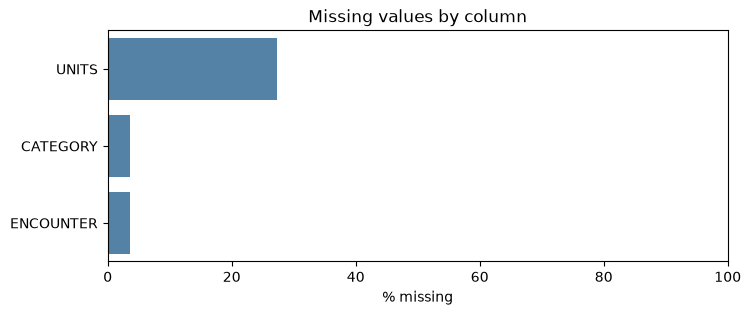

In [70]:
missing_pct = observations_df.isna().mean().sort_values(ascending=False)
missing_pct = (missing_pct[missing_pct > 0] * 100).round(1)

plt.figure(figsize=(8, 3))
sns.barplot(x=missing_pct.values, y=missing_pct.index, color='steelblue')
plt.xlabel('% missing')
plt.xlim(0, 100)
plt.ylabel('')
plt.title('Missing values by column')
plt.show()

In [71]:
# UNITS missingness is almost entirely explained by TYPE, not random
observations_df.groupby('TYPE')['UNITS'].apply(lambda s: s.isna().mean() * 100).rename('PCT_UNITS_MISSING').round(2)

TYPE
numeric    0.00
text      71.42
Name: PCT_UNITS_MISSING, dtype: float64

### Rows without an `ENCOUNTER`

In [72]:
no_enc = observations_df[observations_df['ENCOUNTER'].isna()]
print(f"{len(no_enc):,} of {len(observations_df):,} rows have no ENCOUNTER ({len(no_enc) / len(observations_df):.1%})")
no_enc['DESCRIPTION'].value_counts()

62,970 of 1,764,300 rows have no ENCOUNTER (3.6%)


DESCRIPTION
QALY    20990
DALY    20990
QOLS    20990
Name: count, dtype: int64

These aren't orphaned rows - all of them are `QALY`/`DALY`/`QOLS` (quality-adjusted life year / disability-adjusted life year / quality-of-life score), synthetic population-health metrics Synthea computes roughly once a year per patient rather than tying them to a specific clinical visit.

### TYPE & CATEGORY breakdown

In [73]:
type_counts = observations_df['TYPE'].value_counts()
print(type_counts)
print((type_counts / type_counts.sum()).round(3))

TYPE
numeric    1090963
text        673337
Name: count, dtype: int64
TYPE
numeric   0.62
text      0.38
Name: count, dtype: float64


In [74]:
observations_df.groupby('CATEGORY').size().reset_index(name='COUNT').sort_values(by='COUNT', ascending=False)

,CATEGORY,COUNT
2,laboratory,782651
5,survey,551043
7,vital-signs,326107
4,social-history,31660
0,exam,6783
3,procedure,1584
1,imaging,1275
6,therapy,227


### Top observations

In [75]:
observations_df.groupby('DESCRIPTION').size().reset_index(name='COUNT').sort_values(by='COUNT', ascending=False).head(20)

,DESCRIPTION,COUNT
180,Pain severity - 0-10 verbal numeric rating [Sc...,57802
245,Systolic Blood Pressure,33701
65,Diastolic Blood Pressure,33701
27,Body Weight,32066
109,Heart rate,31318
224,Respiratory rate,31318
25,Body Height,30624
249,Tobacco smoking status,30580
29,Body mass index (BMI) [Ratio],28394
93,Glomerular filtration rate [Volume Rate/Area] ...,23668


In [76]:
observations_df.groupby('DESCRIPTION').size().reset_index(name='COUNT').sort_values(by='COUNT', ascending=False).tail(5)

,DESCRIPTION,COUNT
154,MCV [Entitic mean volume] in Red Blood Cells,3
199,Platelets [#/volume] in Blood,3
195,Physical findings of Abdomen by Palpation,3
21,Bilirubin.total [Mass/volume] in Blood,3
26,Body Temperature,2


### Observations per patient & per visit

In [77]:
obs_per_patient = observations_df.groupby('PATIENT').size()
obs_per_patient.describe()

count    2338.00
mean      754.62
std      1507.41
min        23.00
25%       213.00
50%       354.50
75%       572.75
max     21583.00
dtype: float64

In [78]:
obs_per_visit = observations_df.groupby('ENCOUNTER').size()
obs_per_visit.describe()

count   74041.00
mean       22.98
std        30.56
min         1.00
25%         2.00
50%        11.00
75%        40.00
max      1293.00
dtype: float64

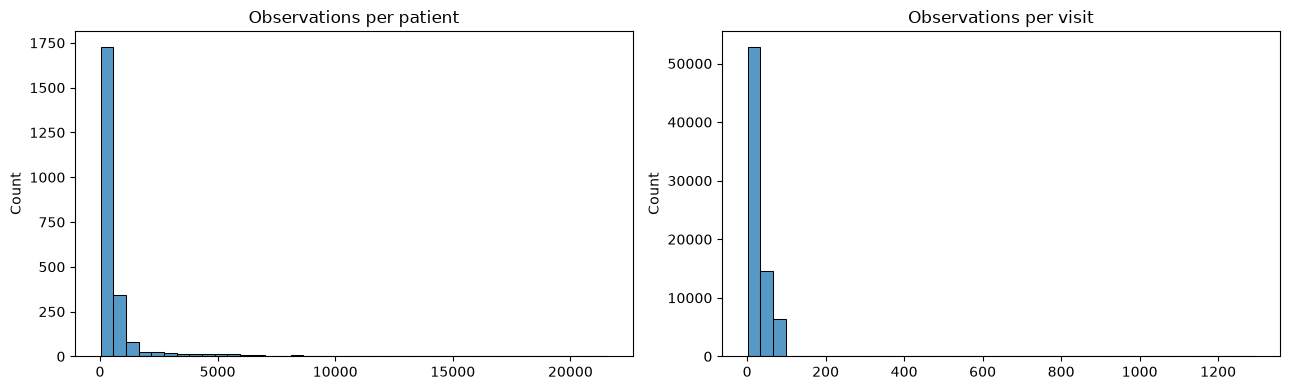

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(obs_per_patient, bins=40, ax=axes[0])
axes[0].set_title('Observations per patient')
sns.histplot(obs_per_visit, bins=40, ax=axes[1])
axes[1].set_title('Observations per visit')
plt.tight_layout()
plt.show()

### Numeric value integrity

In [80]:
numeric_obs = observations_df[observations_df['TYPE'] == 'numeric'].copy()
coerced = pd.to_numeric(numeric_obs['VALUE'], errors='coerce')
print(f"{len(numeric_obs):,} TYPE=='numeric' rows, {coerced.isna().sum()} fail to coerce to float")

1,090,963 TYPE=='numeric' rows, 0 fail to coerce to float


### Observations over time

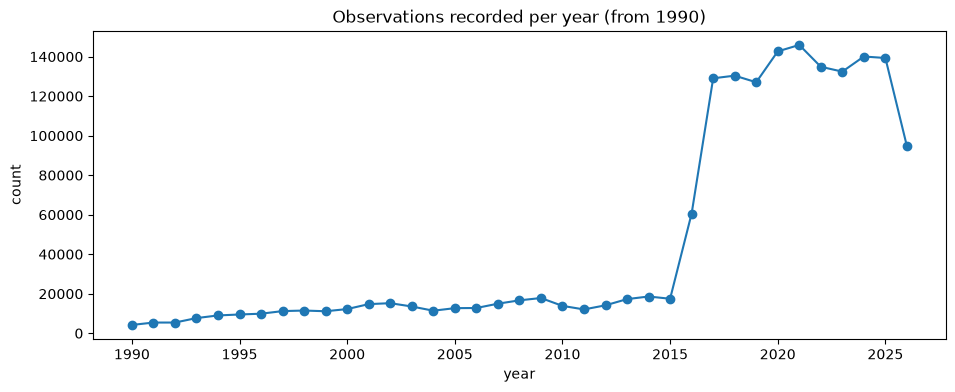

In [81]:
yearly_obs = observations_df['DATE'].dt.year.value_counts().sort_index()

plt.figure(figsize=(11, 4))
yearly_obs[yearly_obs.index >= 1990].plot(kind='line', marker='o')
plt.title('Observations recorded per year (from 1990)')
plt.xlabel('year')
plt.ylabel('count')
plt.show()

### EDA summary - key insights

- **1,764,300 rows across 2,338 patients, 276 distinct DESCRIPTION values** - by far the largest event table in the dataset, roughly 20x the row count of `conditions`.
- **Only three columns carry nulls: `ENCOUNTER`/`CATEGORY` (3.6% each, the same rows) and `UNITS` (27.3%)** - none of it is random. `ENCOUNTER`-null rows are exactly `QALY`/`DALY`/`QOLS` population-health metrics computed per patient, not per visit (62,970 rows, ~30 per patient); `UNITS` is missing for 71.4% of `TYPE == 'text'` rows (survey answers have no unit, e.g. "Housing status: rents") but only 0.002% of `TYPE == 'numeric'` rows - practically complete for anything you'd actually plot or trend.
- **`TYPE` splits 61.8% numeric / 38.2% text.** `CATEGORY` is dominated by `laboratory` (782,651) and `survey` (551,043), then `vital-signs` (326,107); `social-history`/`exam`/`procedure`/`imaging`/`therapy` together are under 2% of rows.
- **All 1,090,963 `TYPE == 'numeric'` `VALUE` strings coerce cleanly to float (0 failures)** - `pd.to_numeric` is safe here without a fallback/error path.
- **Top observations are standard vitals plus a repeated social-determinants survey**: pain score (57,802), diastolic/systolic BP (33,701 each), weight, heart rate, respiratory rate, height, then PRAPARE housing/address/household-size questions clustering around ~23k each - consistent with one fixed survey instrument being administered repeatedly across encounters.
- **Observations per patient: mean 754.6, median 354.5, max 21,583** - and per visit: median 11, mean 23.0, max 1,293. Both show the same high-utilization-outlier pattern as encounters and conditions; some visit types (e.g. full-panel wellness checks) generate far more observations than a typical problem visit.
- **Yearly volume tracks encounter volume**, rising through 2025 with the same expected partial-year dip in 2026 (94,681 rows) - observations are generated in lockstep with encounters, not sampled independently.

## Medications

One row per prescription fill. `REASONCODE`/`REASONDESCRIPTION` link a medication back to the *condition* it treats (SNOMED code match against `conditions.CODE`, same patient) - this is the causal-chain data behind "why was this drug started" questions. `STOP` null means the medication is still active as of data generation.

In [82]:
medications_df = pd.read_csv(
    '../synthea_data/output/csv/medications.csv',
    parse_dates=['START', 'STOP'],
)
medications_df

,START,STOP,PATIENT,PAYER,ENCOUNTER,CODE,DESCRIPTION,BASE_COST,PAYER_COVERAGE,DISPENSES,TOTALCOST,REASONCODE,REASONDESCRIPTION
0,2013-03-14 00:41:04+00:00,2019-09-28 00:41:04+00:00,c44d667b-15d5-99d4-0f69-43ca66739022,0133f751-9229-3cfd-815f-b6d4979bdd6a,c44d667b-15d5-99d4-8be2-fcf6faba9b86,849574,Naproxen sodium 220 MG Oral Tablet,91.72,91.72,79,7245.88,239872002.00,Osteoarthritis of hip (disorder)
1,1987-04-08 17:52:20+00:00,NaT,51c5e2a9-2833-5133-b85a-329b9cd53c41,e03e23c9-4df1-3eb6-a62d-f70f02301496,51c5e2a9-2833-5133-64cf-ac76a63f6471,477045,Chlorpheniramine Maleate 2 MG/ML Oral Solution,152.88,0.00,479,73229.52,NaN,NaN
2,1987-04-08 17:52:20+00:00,NaT,51c5e2a9-2833-5133-b85a-329b9cd53c41,e03e23c9-4df1-3eb6-a62d-f70f02301496,51c5e2a9-2833-5133-64cf-ac76a63f6471,1870230,NDA020800 0.3 ML Epinephrine 1 MG/ML Auto-Inje...,71.37,0.00,479,34186.23,NaN,NaN
3,2017-01-25 17:53:22+00:00,2017-02-10 17:53:22+00:00,51c5e2a9-2833-5133-b85a-329b9cd53c41,734afbd6-4794-363b-9bc0-6a3981533ed5,51c5e2a9-2833-5133-41e1-3cda9a8753eb,310965,Ibuprofen 200 MG Oral Tablet,117.37,0.00,1,117.37,NaN,NaN
4,2016-09-18 03:49:03+00:00,2016-09-18 03:49:03+00:00,c44d667b-15d5-99d4-0f69-43ca66739022,0133f751-9229-3cfd-815f-b6d4979bdd6a,c44d667b-15d5-99d4-2e8b-c0fa393c1b54,1535362,sodium fluoride 0.0272 MG/MG Oral Gel,129.94,0.00,1,129.94,66383009.00,Gingivitis (disorder)
...,...,...,...,...,...,...,...,...,...,...,...,...,...
117437,2024-06-23 01:10:17+00:00,2025-06-29 01:10:17+00:00,502dc964-df3b-7fa0-689e-78d3809a8df5,a735bf55-83e9-331a-899d-a82a60b9f60c,502dc964-df3b-7fa0-622b-d69eeaea8621,206905,Ibuprofen 400 MG Oral Tablet [Ibu],129.94,0.00,3,389.82,NaN,NaN
117438,2025-06-29 01:10:17+00:00,2025-11-30 01:10:17+00:00,502dc964-df3b-7fa0-689e-78d3809a8df5,a735bf55-83e9-331a-899d-a82a60b9f60c,502dc964-df3b-7fa0-ce2d-604647fd56ea,206905,Ibuprofen 400 MG Oral Tablet [Ibu],129.94,0.00,3,389.82,NaN,NaN
117439,2025-11-30 01:10:17+00:00,2025-12-07 01:10:17+00:00,502dc964-df3b-7fa0-689e-78d3809a8df5,a735bf55-83e9-331a-899d-a82a60b9f60c,502dc964-df3b-7fa0-4d8f-f9dd275d425f,206905,Ibuprofen 400 MG Oral Tablet [Ibu],129.94,103.95,3,389.82,NaN,NaN
117440,2025-12-07 01:10:17+00:00,2026-07-05 01:10:17+00:00,502dc964-df3b-7fa0-689e-78d3809a8df5,a735bf55-83e9-331a-899d-a82a60b9f60c,502dc964-df3b-7fa0-6d66-78d033337adf,206905,Ibuprofen 400 MG Oral Tablet [Ibu],129.94,103.95,3,389.82,NaN,NaN


### Data quality

In [83]:
medications_df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117442 entries, 0 to 117441
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   START              117442 non-null  datetime64[ns, UTC]
 1   STOP               111331 non-null  datetime64[ns, UTC]
 2   PATIENT            117442 non-null  object             
 3   PAYER              117442 non-null  object             
 4   ENCOUNTER          117442 non-null  object             
 5   CODE               117442 non-null  int64              
 6   DESCRIPTION        117442 non-null  object             
 7   BASE_COST          117442 non-null  float64            
 8   PAYER_COVERAGE     117442 non-null  float64            
 9   DISPENSES          117442 non-null  int64              
 10  TOTALCOST          117442 non-null  float64            
 11  REASONCODE         94988 non-null   float64            
 12  REASONDESCRIPTION  94988 non-n

In [84]:
missing_pct = medications_df.isna().mean().sort_values(ascending=False)
missing_pct = (missing_pct[missing_pct > 0] * 100).round(1)
print(missing_pct)

# integrity check: TOTALCOST should always equal BASE_COST * DISPENSES
mismatch = ((medications_df['BASE_COST'] * medications_df['DISPENSES']
             - medications_df['TOTALCOST']).abs() > 0.01).sum()
print('TOTALCOST != BASE_COST * DISPENSES rows:', mismatch)

REASONCODE          19.10
REASONDESCRIPTION   19.10
STOP                 5.20
dtype: float64
TOTALCOST != BASE_COST * DISPENSES rows: 0


### Top medications & why they're prescribed

In [85]:
medications_df['DESCRIPTION'].value_counts().head(15)

DESCRIPTION
1 ML Epoetin Alfa 4000 UNT/ML Injection [Epogen]                                                         19318
lisinopril 10 MG Oral Tablet                                                                             10524
insulin isophane  human 70 UNT/ML / insulin  regular  human 30 UNT/ML Injectable Suspension [Humulin]     9606
amLODIPine 2.5 MG Oral Tablet                                                                             7905
Hydrochlorothiazide 25 MG Oral Tablet                                                                     7765
sodium fluoride 0.0272 MG/MG Oral Gel                                                                     6477
Cisplatin 50 MG Injection                                                                                 4958
PACLitaxel 100 MG Injection                                                                               4228
24 HR Metformin hydrochloride 500 MG Extended Release Oral Tablet                                   

In [86]:
medications_df['REASONDESCRIPTION'].value_counts().head(15)

REASONDESCRIPTION
Essential hypertension (disorder)                                        26428
Anemia (disorder)                                                        19318
Non-small cell carcinoma of lung  TNM stage 1 (disorder)                  8456
Diabetes mellitus type 2 (disorder)                                       8049
Prediabetes (finding)                                                     4667
Childhood asthma (disorder)                                               3936
Patient referral for dental care (procedure)                              3368
Gingivitis (disorder)                                                     3069
Osteoporosis (disorder)                                                   2598
History of renal transplant (situation)                                   2355
Hyperlipidemia (disorder)                                                 2005
Chronic congestive heart failure (disorder)                               1876
Primary small cell malignant neopl

### Causal chain: medication -> condition via `REASONCODE`

In [87]:
has_reason = medications_df['REASONCODE'].notna()
print(f'{has_reason.mean():.1%} of {len(medications_df):,} medication rows carry a REASONCODE')

80.9% of 117,442 medication rows carry a REASONCODE


In [88]:
# naive join: REASONCODE == conditions.CODE for the same patient
med_condition = medications_df.merge(
    conditions_df, left_on=['PATIENT', 'REASONCODE'], right_on=['PATIENT', 'CODE'],
    suffixes=('_med', '_cond'),
)
print(f"{len(med_condition):,} joined rows from {has_reason.sum():,} reasoned medication rows "
      f"({len(med_condition) / has_reason.sum():.1%})")

107,286 joined rows from 94,988 reasoned medication rows (112.9%)


In [89]:
# >100% because a patient can be diagnosed with the same condition CODE more than once
# (recurring/re-screened findings) - a blind PATIENT+CODE join fans out across every
# occurrence. A real causal-chain lookup should pick the nearest prior condition by date,
# not merge on the code alone.
dup_codes = conditions_df.groupby(['PATIENT', 'CODE']).size()
print(f'{(dup_codes > 1).sum():,} of {len(dup_codes):,} (PATIENT, CODE) pairs recur more than once')
dup_codes.value_counts().head()

12,278 of 46,067 (PATIENT, CODE) pairs recur more than once


1    33789
2     5330
3     2760
4     1423
5      794
Name: count, dtype: int64

### Cost & prescription volume

In [90]:
medications_df[['BASE_COST', 'PAYER_COVERAGE', 'TOTALCOST', 'DISPENSES']].describe()

,BASE_COST,PAYER_COVERAGE,TOTALCOST,DISPENSES
count,117442.00,117442.00,117442.00,117442.00
mean,106.78,65.89,2813.99,7.22
std,1285.20,953.86,198468.05,43.17
min,0.00,0.00,0.00,1.00
25%,0.91,0.00,2.46,1.00
50%,30.67,1.42,30.67,1.00
75%,129.94,94.94,171.59,3.00
max,103958.40,103908.40,32930352.00,1315.00


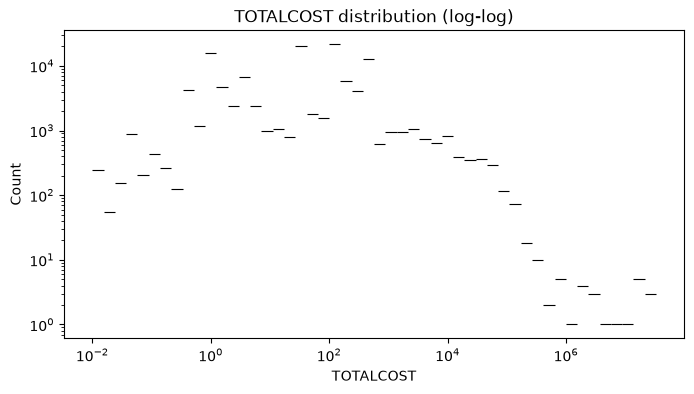

In [91]:
plt.figure(figsize=(8, 4))
sns.histplot(medications_df['TOTALCOST'], bins=50, log_scale=(True, True))
plt.title('TOTALCOST distribution (log-log)')
plt.show()

### Medications per patient

In [92]:
meds_per_patient = medications_df.groupby('PATIENT').size()
print(f"{medications_df['PATIENT'].nunique():,} of 2,338 patients have at least one medication row")
meds_per_patient.describe()

2,286 of 2,338 patients have at least one medication row


count   2286.00
mean      51.37
std      139.47
min        1.00
25%        6.00
50%       12.00
75%       35.00
max     2543.00
dtype: float64

### EDA summary - key insights

- **117,442 medication rows, 2,286 of 2,338 patients (97.8%), 298 distinct drugs.**
- **`REASONCODE` is populated on 80.9% of rows** (94,988/117,442), matching the design doc's verified finding - stable across dataset scales, not a small-sample artifact.
- **A naive `PATIENT + REASONCODE == PATIENT + CODE` join against `conditions` over-matches**: 107,286 joined rows come out of only 94,988 reasoned medication rows (112.9%). The cause: 12,278 of 46,067 distinct `(PATIENT, CODE)` condition pairs recur more than once (up to 191 times for one recurring screening finding), so the join fans out. Any real causal-chain lookup needs to pick the nearest prior condition occurrence by date, not merge on code alone - this matters directly for the Medication Tool's REASONCODE-linkage logic.
- **Top prescriptions are dominated by chronic-disease maintenance drugs**: Epoetin Alfa (19,318 - dialysis/anemia), lisinopril (10,524 - hypertension), Humulin insulin mix (9,606), amlodipine (7,905), HCTZ (7,765) - consistent with the CKD/renal and hypertension-heavy population seen in Encounters and Conditions.
- **Top prescribing reasons**: essential hypertension (26,428), anemia (19,318), NSCLC stage 1 (8,456), type 2 diabetes (8,049) - directly traceable to the drugs above via `REASONCODE`.
- **`TOTALCOST` is internally consistent**: `BASE_COST * DISPENSES == TOTALCOST` for all 117,442 rows (0 mismatches), but the distribution is extreme - mean $2,814 vs. a $0-$32.9M range, driven by chemo drugs (Cisplatin, Paclitaxel) with high per-dispense cost and dispense counts.
- **94.8% of medications have a `STOP` date** (i.e. only 5.2% are still active) - unlike conditions, most prescriptions in this dataset represent completed courses, not indefinite chronic therapy.

## Procedures

One row per procedure performed during an encounter. Unlike `conditions`, `START`/`STOP` here are always both populated (a procedure has a bounded duration, even if brief) - it's not a chronic-vs-resolved distinction. `REASONCODE` links a procedure back to a condition the same way `medications.REASONCODE` does.

In [93]:
procedures_df = pd.read_csv(
    '../synthea_data/output/csv/procedures.csv',
    parse_dates=['START', 'STOP'],
)
procedures_df

,START,STOP,PATIENT,ENCOUNTER,SYSTEM,CODE,DESCRIPTION,BASE_COST,REASONCODE,REASONDESCRIPTION
0,2016-09-04 00:41:04+00:00,2016-09-04 00:56:04+00:00,c44d667b-15d5-99d4-0f69-43ca66739022,c44d667b-15d5-99d4-44d7-8f6b4ce95182,http://snomed.info/sct,430193006,Medication reconciliation (procedure),215.70,NaN,NaN
1,2017-04-05 17:21:52+00:00,2017-04-05 17:59:29+00:00,51c5e2a9-2833-5133-b85a-329b9cd53c41,51c5e2a9-2833-5133-605d-195295cdc3b1,http://snomed.info/sct,710824005,Assessment of health and social care needs (pr...,431.40,NaN,NaN
2,2017-04-05 17:59:29+00:00,2017-04-05 18:26:43+00:00,51c5e2a9-2833-5133-b85a-329b9cd53c41,51c5e2a9-2833-5133-605d-195295cdc3b1,http://snomed.info/sct,710841007,Assessment of anxiety (procedure),431.40,NaN,NaN
3,2016-09-04 00:41:04+00:00,2016-09-04 01:40:03+00:00,c44d667b-15d5-99d4-0f69-43ca66739022,c44d667b-15d5-99d4-44d7-8f6b4ce95182,http://snomed.info/sct,710824005,Assessment of health and social care needs (pr...,431.40,NaN,NaN
4,2017-04-05 18:26:43+00:00,2017-04-05 18:41:15+00:00,51c5e2a9-2833-5133-b85a-329b9cd53c41,51c5e2a9-2833-5133-605d-195295cdc3b1,http://snomed.info/sct,171207006,Depression screening (procedure),431.40,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
385404,2026-07-19 01:51:37+00:00,2026-07-19 02:28:02+00:00,502dc964-df3b-7fa0-689e-78d3809a8df5,502dc964-df3b-7fa0-0bec-a4f003e0f5e1,http://snomed.info/sct,1260009003,Removal of supragingival plaque and calculus f...,431.40,103697008.00,Patient referral for dental care (procedure)
385405,2026-07-19 02:28:02+00:00,2026-07-19 03:04:33+00:00,502dc964-df3b-7fa0-689e-78d3809a8df5,502dc964-df3b-7fa0-0bec-a4f003e0f5e1,http://snomed.info/sct,1260010008,Removal of subgingival plaque and calculus fro...,431.40,103697008.00,Patient referral for dental care (procedure)
385406,2026-07-19 03:04:33+00:00,2026-07-19 03:34:33+00:00,502dc964-df3b-7fa0-689e-78d3809a8df5,502dc964-df3b-7fa0-0bec-a4f003e0f5e1,http://snomed.info/sct,241046008,Dental plain X-ray bitewing (procedure),431.40,NaN,NaN
385407,2026-07-19 03:04:33+00:00,2026-07-19 03:49:38+00:00,502dc964-df3b-7fa0-689e-78d3809a8df5,502dc964-df3b-7fa0-0bec-a4f003e0f5e1,http://snomed.info/sct,274788003,Examination of gingivae (procedure),431.40,103697008.00,Patient referral for dental care (procedure)


### Data quality

In [94]:
procedures_df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 385409 entries, 0 to 385408
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   START              385409 non-null  datetime64[ns, UTC]
 1   STOP               385409 non-null  datetime64[ns, UTC]
 2   PATIENT            385409 non-null  object             
 3   ENCOUNTER          385409 non-null  object             
 4   SYSTEM             385409 non-null  object             
 5   CODE               385409 non-null  int64              
 6   DESCRIPTION        385409 non-null  object             
 7   BASE_COST          385409 non-null  float64            
 8   REASONCODE         180864 non-null  float64            
 9   REASONDESCRIPTION  180864 non-null  object             
dtypes: datetime64[ns, UTC](2), float64(2), int64(1), object(5)
memory usage: 29.4+ MB


In [95]:
missing_pct = procedures_df.isna().mean().sort_values(ascending=False)
missing_pct = (missing_pct[missing_pct > 0] * 100).round(1)
print(missing_pct)
print('SYSTEM is constant:', procedures_df['SYSTEM'].nunique() == 1, procedures_df['SYSTEM'].unique())

REASONDESCRIPTION   53.10
REASONCODE          53.10
dtype: float64
SYSTEM is constant: True ['http://snomed.info/sct']


### Top procedures

In [96]:
procedures_df['DESCRIPTION'].value_counts().head(15)

DESCRIPTION
Depression screening (procedure)                                                                   38490
Renal dialysis (procedure)                                                                         23347
Assessment of health and social care needs (procedure)                                             23090
Medication reconciliation (procedure)                                                              16161
Assessment of substance use (procedure)                                                            15225
Patient referral for dental care (procedure)                                                       13801
Dental consultation and report (procedure)                                                         13490
Oral health education (procedure)                                                                  13107
Removal of supragingival plaque and calculus from all teeth using dental instrument (procedure)    13016
Removal of subgingival plaque and calculus 

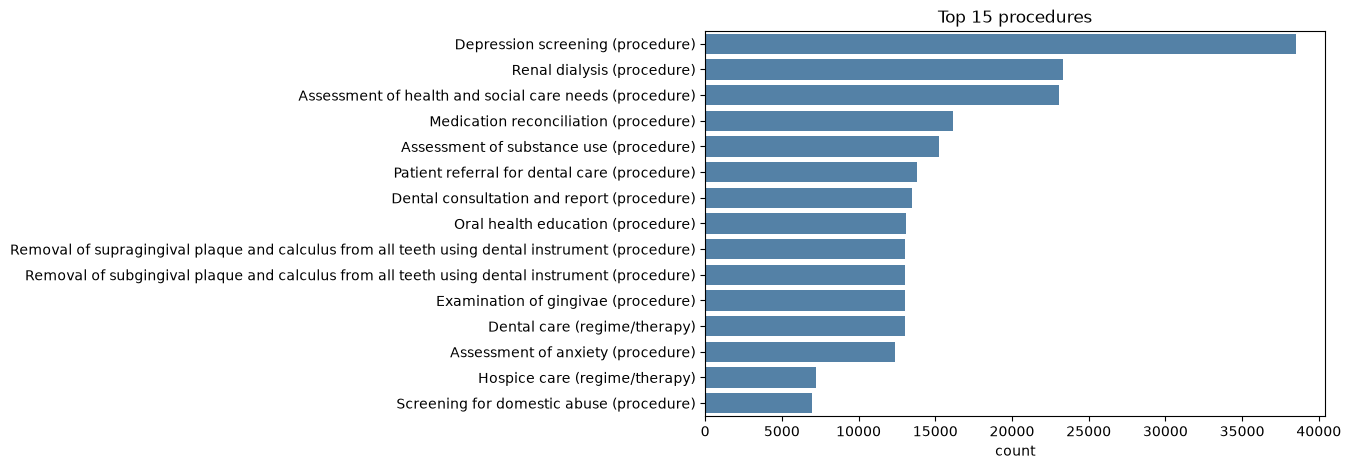

In [97]:
top15 = procedures_df['DESCRIPTION'].value_counts().head(15)
plt.figure(figsize=(8, 5))
sns.barplot(x=top15.values, y=top15.index, color='steelblue')
plt.xlabel('count')
plt.ylabel('')
plt.title('Top 15 procedures')
plt.show()

### Duration & cost

In [98]:
procedures_df['DURATION_MIN'] = (procedures_df['STOP'] - procedures_df['START']).dt.total_seconds() / 60
print('non-positive duration rows:', (procedures_df['DURATION_MIN'] <= 0).sum())
procedures_df['DURATION_MIN'].describe()

non-positive duration rows: 35


count   385409.00
mean        39.20
std        369.40
min          0.00
25%         15.00
50%         22.52
75%         35.17
max      85020.00
Name: DURATION_MIN, dtype: float64

In [99]:
print('distinct BASE_COST values:', procedures_df['BASE_COST'].nunique(), 'across', len(procedures_df), 'rows')
procedures_df['BASE_COST'].describe()

distinct BASE_COST values: 39777 across 385409 rows


count   385409.00
mean       991.55
std       2298.56
min          0.32
25%        431.40
50%        431.40
75%        431.40
max     212139.86
Name: BASE_COST, dtype: float64

### Causal chain: procedure -> condition via `REASONCODE`

In [100]:
has_reason_p = procedures_df['REASONCODE'].notna()
print(f'{has_reason_p.mean():.1%} of {len(procedures_df):,} procedure rows carry a REASONCODE')
# same many-to-many caveat as medications: a naive join over-matches when a condition code recurs
proc_condition = procedures_df.merge(
    conditions_df, left_on=['PATIENT', 'REASONCODE'], right_on=['PATIENT', 'CODE'],
    suffixes=('_proc', '_cond'),
)
print(f"{len(proc_condition):,} joined rows from {has_reason_p.sum():,} reasoned procedure rows "
      f"({len(proc_condition) / has_reason_p.sum():.1%}) - inflated for the same reason as medications")

46.9% of 385,409 procedure rows carry a REASONCODE
527,237 joined rows from 180,864 reasoned procedure rows (291.5%) - inflated for the same reason as medications


### Procedures per patient & per visit

In [101]:
procs_per_patient = procedures_df.groupby('PATIENT').size()
procs_per_visit = procedures_df.groupby('ENCOUNTER').size()
print(procs_per_patient.describe())
print()
print(procs_per_visit.describe())

count   2330.00
mean     165.41
std      207.33
min        1.00
25%       69.00
50%      116.00
75%      173.00
max     1811.00
dtype: float64

count   98779.00
mean        3.90
std         4.52
min         1.00
25%         1.00
50%         2.00
75%         6.00
max       166.00
dtype: float64


### EDA summary - key insights

- **385,409 procedure rows, 2,330 of 2,338 patients, `SYSTEM` constant** (`http://snomed.info/sct`), matching `conditions`.
- **`REASONCODE` coverage is much lower than medications (46.9% vs. 80.9%)** - roughly half of procedures (routine screenings, dental cleanings, administrative assessments) aren't tied to a diagnosed condition; the other half (dialysis, biopsies, etc.) are.
- **Top procedures are dominated by routine/administrative screenings, not interventions**: depression screening (38,490), renal dialysis (23,347), social-care-needs assessment (23,090), medication reconciliation (16,161) - same pattern as Conditions, where administrative findings outnumber true clinical diagnoses in raw frequency.
- **`BASE_COST` is essentially continuous, not a fixed price list**: 39,777 distinct values across 385,409 rows (vs. `encounters.BASE_ENCOUNTER_COST`, which is a small fixed set per class) - the median $431.40 appears at the 25th/50th/75th percentile simultaneously, meaning one procedure type dominates volume, but costs otherwise vary continuously per instance.
- **All procedures have a bounded, positive duration** (median ~22.5 min, max ~59 days for hospice-linked long procedures) - unlike conditions, there's no "still ongoing" state here.
- **The `REASONCODE` join inflates the same way medications' does** (527,237 joined rows from 180,864 reasoned rows) - confirms the recurring-condition-code caveat is a dataset-wide gotcha for any causal-chain join, not specific to medications.
- **165 procedures/patient on average (median 116, max 1,811)** and **~4 procedures/visit (median 2, max 166)** - the same high-utilization outlier pattern as every other clinical table.

## Allergies

Allergy/intolerance records, opened at a given encounter. Much smaller and sparser than the other clinical tables - only 388 of 2,338 patients (16.6%) have any allergy on record at all.

In [102]:
allergies_df = pd.read_csv(
    '../synthea_data/output/csv/allergies.csv',
    parse_dates=['START', 'STOP'],
)
allergies_df

,START,STOP,PATIENT,ENCOUNTER,CODE,SYSTEM,DESCRIPTION,TYPE,CATEGORY,REACTION1,DESCRIPTION1,SEVERITY1,REACTION2,DESCRIPTION2,SEVERITY2
0,1987-04-08,NaT,51c5e2a9-2833-5133-b85a-329b9cd53c41,51c5e2a9-2833-5133-64cf-ac76a63f6471,609328004,SNOMED-CT,Allergic disposition (finding),allergy,environment,NaN,NaN,NaN,NaN,NaN,NaN
1,1987-04-08,NaT,51c5e2a9-2833-5133-b85a-329b9cd53c41,51c5e2a9-2833-5133-64cf-ac76a63f6471,412071004,SNOMED-CT,Wheat (substance),allergy,food,271807003.00,Eruption of skin (disorder),MODERATE,NaN,NaN,NaN
2,2008-02-22,NaT,502cf42a-a540-ff39-0d59-c10d7cc1f4c7,502cf42a-a540-ff39-b415-21f8f4ec6172,609328004,SNOMED-CT,Allergic disposition (finding),allergy,environment,NaN,NaN,NaN,NaN,NaN,NaN
3,2008-02-22,NaT,502cf42a-a540-ff39-0d59-c10d7cc1f4c7,502cf42a-a540-ff39-b415-21f8f4ec6172,84489001,SNOMED-CT,Mold (organism),allergy,environment,NaN,NaN,NaN,NaN,NaN,NaN
4,2008-02-22,NaT,502cf42a-a540-ff39-0d59-c10d7cc1f4c7,502cf42a-a540-ff39-b415-21f8f4ec6172,412071004,SNOMED-CT,Wheat (substance),allergy,food,271807003.00,Eruption of skin (disorder),MODERATE,267036007.00,Dyspnea (finding),MILD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1991,1925-08-26,NaT,ac453710-a147-b8c1-d67c-c3b0beaa8c3b,ac453710-a147-b8c1-8781-7bed82dc57f2,735029006,SNOMED-CT,Shellfish (substance),allergy,food,39579001.00,Anaphylaxis (disorder),SEVERE,422587007.00,Nausea (finding),MODERATE
1992,1927-05-21,NaT,a8a5247e-740e-b3c6-677b-404216c74a38,a8a5247e-740e-b3c6-6c28-2cc8757b05d0,609328004,SNOMED-CT,Allergic disposition (finding),allergy,environment,NaN,NaN,NaN,NaN,NaN,NaN
1993,1927-05-21,NaT,a8a5247e-740e-b3c6-677b-404216c74a38,a8a5247e-740e-b3c6-6c28-2cc8757b05d0,84489001,SNOMED-CT,Mold (organism),allergy,environment,NaN,NaN,NaN,NaN,NaN,NaN
1994,1927-05-21,NaT,a8a5247e-740e-b3c6-677b-404216c74a38,a8a5247e-740e-b3c6-6c28-2cc8757b05d0,10831,RxNorm,Sulfamethoxazole / Trimethoprim,allergy,medication,271807003.00,Eruption of skin (disorder),MODERATE,247472004.00,Wheal (finding),MODERATE


### Data quality

In [103]:
allergies_df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1996 entries, 0 to 1995
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   START         1996 non-null   datetime64[ns]
 1   STOP          0 non-null      datetime64[ns]
 2   PATIENT       1996 non-null   object        
 3   ENCOUNTER     1996 non-null   object        
 4   CODE          1996 non-null   int64         
 5   SYSTEM        1996 non-null   object        
 6   DESCRIPTION   1996 non-null   object        
 7   TYPE          1996 non-null   object        
 8   CATEGORY      1996 non-null   object        
 9   REACTION1     859 non-null    float64       
 10  DESCRIPTION1  859 non-null    object        
 11  SEVERITY1     859 non-null    object        
 12  REACTION2     523 non-null    float64       
 13  DESCRIPTION2  523 non-null    object        
 14  SEVERITY2     523 non-null    object        
dtypes: datetime64[ns](2), float64(2), int6

In [104]:
missing_pct = allergies_df.isna().mean().sort_values(ascending=False)
missing_pct = (missing_pct[missing_pct > 0] * 100).round(1)
missing_pct

STOP           100.00
SEVERITY2       73.80
DESCRIPTION2    73.80
REACTION2       73.80
DESCRIPTION1    57.00
SEVERITY1       57.00
REACTION1       57.00
dtype: float64

In [105]:
# STOP is 100% null across every row - Synthea never resolves an allergy once recorded,
# unlike conditions/medications where STOP marks resolution. Drop it rather than carry a
# structurally-always-null column forward.
print('STOP all null:', allergies_df['STOP'].isna().all())
allergies_df = allergies_df.drop(columns=['STOP'])

STOP all null: True


### Type, category & severity

In [106]:
allergies_df['TYPE'].value_counts()

TYPE
allergy        1958
intolerance      38
Name: count, dtype: int64

In [107]:
allergies_df['CATEGORY'].value_counts()

CATEGORY
environment    1376
food            431
medication      189
Name: count, dtype: int64

In [108]:
# SEVERITY1 is null exactly when REACTION1 is null (no reaction recorded -> no severity to grade)
print(allergies_df['SEVERITY1'].value_counts(dropna=False))
print()
print(allergies_df['SEVERITY2'].value_counts(dropna=False))

SEVERITY1
NaN         1137
MODERATE     502
MILD         247
SEVERE       110
Name: count, dtype: int64

SEVERITY2
NaN         1473
MILD         282
MODERATE     241
Name: count, dtype: int64


### Top allergens

In [109]:
allergies_df['DESCRIPTION'].value_counts().head(15)

DESCRIPTION
Allergic disposition (finding)    388
Mold (organism)                   212
Animal dander (substance)         199
Grass pollen (substance)          156
House dust mite (organism)        150
Tree pollen (substance)           149
Shellfish (substance)              95
Aspirin                            77
Latex (substance)                  64
Eggs (edible) (substance)          63
Bee venom (substance)              58
Fish (substance)                   53
Wheat (substance)                  50
Cow's milk (substance)             49
Peanut (substance)                 49
Name: count, dtype: int64

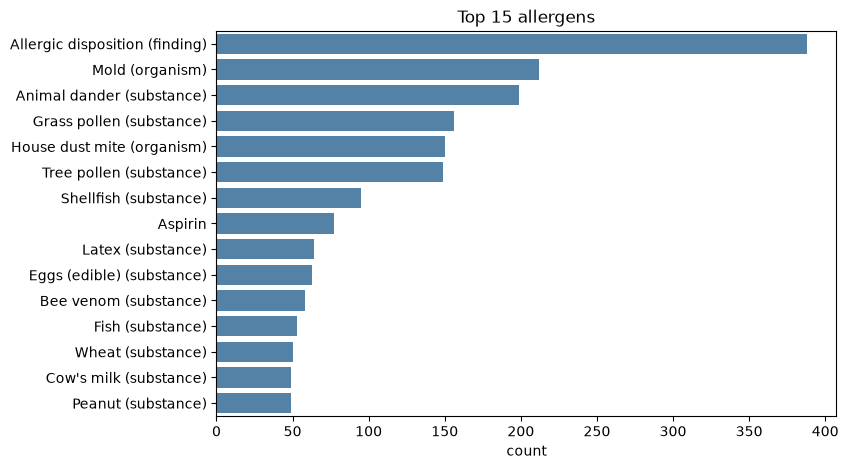

In [110]:
top15 = allergies_df['DESCRIPTION'].value_counts().head(15)
plt.figure(figsize=(8, 5))
sns.barplot(x=top15.values, y=top15.index, color='steelblue')
plt.xlabel('count')
plt.ylabel('')
plt.title('Top 15 allergens')
plt.show()

### Allergies per patient

In [111]:
allergies_per_patient = allergies_df.groupby('PATIENT').size()
print(f"{allergies_df['PATIENT'].nunique()} of 2,338 patients ("
      f"{allergies_df['PATIENT'].nunique() / 2338:.1%}) have at least one allergy on record")
allergies_per_patient.describe()

388 of 2,338 patients (16.6%) have at least one allergy on record


count   388.00
mean      5.14
std       3.38
min       1.00
25%       2.00
50%       4.00
75%       8.00
max      12.00
dtype: float64

### EDA summary - key insights

- **Only 1,996 allergy rows across 388 of 2,338 patients (16.6%)** - by far the sparsest clinical table so far. Most patients have zero allergy records; among those who do, the median is 4 (mean 5.1, max 12) - don't expect every patient investigation to surface allergy data.
- **`STOP` is 100% null across every row** - unlike `conditions`/`medications`, Synthea never marks an allergy resolved once recorded. Dropped it rather than keep a structurally-dead column (this confirms and keeps the check the notebook already had, rather than rediscovering it from scratch).
- **97.9% of rows are `TYPE == 'allergy'`** (1,958 vs. 38 `intolerance`) and category splits `environment` (1,376) > `food` (431) > `medication` (189) - environmental allergens dominate.
- **`SEVERITY1`/`REACTION1` are missing together (56.96% each) and `SEVERITY2`/`REACTION2` together (73.80% each)** - severity is only ever recorded alongside a specific reaction, never independently; most rows carry zero or one reaction, a second reaction is uncommon.
- **Top allergens are common environmental/food triggers**: "Allergic disposition" (a general finding, 388 - one per allergic patient, not a specific allergen), mold (212), animal dander (199), grass/tree pollen, shellfish, aspirin, latex - a realistic mix, no exotic outliers.

## Careplans

Ongoing care plans (e.g. "fracture care", "diabetes self management"), one row per plan instance - unlike most clinical tables, `careplans` has its own `Id` primary key rather than relying on `(PATIENT, ENCOUNTER)` alone. `REASONCODE` links a plan back to the condition that prompted it, same pattern as medications/procedures.

In [112]:
careplans_df = pd.read_csv(
    '../synthea_data/output/csv/careplans.csv',
    parse_dates=['START', 'STOP'],
)
careplans_df

,Id,START,STOP,PATIENT,ENCOUNTER,CODE,DESCRIPTION,REASONCODE,REASONDESCRIPTION
0,51c5e2a9-2833-5133-c800-ff57ffaf6f0b,1987-03-12,NaT,51c5e2a9-2833-5133-b85a-329b9cd53c41,51c5e2a9-2833-5133-c35d-7d2e62d45dd3,384758001,Self-care interventions (procedure),NaN,NaN
1,c44d667b-15d5-99d4-202f-dd20552585d6,2013-03-14,NaT,c44d667b-15d5-99d4-0f69-43ca66739022,c44d667b-15d5-99d4-8be2-fcf6faba9b86,408869004,Musculoskeletal care (regime/therapy),239872002.00,Osteoarthritis of hip (disorder)
2,51c5e2a9-2833-5133-488b-7d53bc70d6a0,2017-01-25,2017-02-10,51c5e2a9-2833-5133-b85a-329b9cd53c41,51c5e2a9-2833-5133-41e1-3cda9a8753eb,773513001,Physiotherapy care plan (record artifact),44465007.00,Sprain of ankle (disorder)
3,c44d667b-15d5-99d4-08e5-8b4bff5cd3fd,2019-08-22,2019-09-28,c44d667b-15d5-99d4-0f69-43ca66739022,c44d667b-15d5-99d4-bbac-81809254ecb7,773513001,Physiotherapy care plan (record artifact),70704007.00,Sprain of wrist (disorder)
4,502cf42a-a540-ff39-ee3a-0547ceaf8151,2008-02-07,NaT,502cf42a-a540-ff39-0d59-c10d7cc1f4c7,502cf42a-a540-ff39-4ab0-976790a5b0fb,384758001,Self-care interventions (procedure),NaN,NaN
...,...,...,...,...,...,...,...,...,...
7719,b00222da-8016-b43b-cc19-23eed40240d2,2010-02-22,2010-02-26,b00222da-8016-b43b-10b0-818e19e8ed82,b00222da-8016-b43b-a9a9-236da57487b9,736353004,Inpatient care plan (record artifact),88805009.00,Chronic congestive heart failure (disorder)
7720,b00222da-8016-b43b-2adb-3358004b7067,2010-08-08,NaT,b00222da-8016-b43b-10b0-818e19e8ed82,b00222da-8016-b43b-d53d-5de85844b5fc,736353004,Inpatient care plan (record artifact),88805009.00,Chronic congestive heart failure (disorder)
7721,93adf52a-483e-ccb6-b2cd-2b1116403bff,1971-02-10,NaT,93adf52a-483e-ccb6-f8b3-a046e54372d6,93adf52a-483e-ccb6-414a-70f954ce551c,443402002,Lifestyle education regarding hypertension (pr...,59621000.00,Essential hypertension (disorder)
7722,93adf52a-483e-ccb6-b574-350b968a3da3,2005-08-24,NaT,93adf52a-483e-ccb6-f8b3-a046e54372d6,93adf52a-483e-ccb6-1577-b1c557f0a470,386257007,Dementia management (regime/therapy),26929004.00,Alzheimer's disease (disorder)


### Data quality

In [113]:
careplans_df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7724 entries, 0 to 7723
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Id                 7724 non-null   object        
 1   START              7724 non-null   datetime64[ns]
 2   STOP               3903 non-null   datetime64[ns]
 3   PATIENT            7724 non-null   object        
 4   ENCOUNTER          7724 non-null   object        
 5   CODE               7724 non-null   int64         
 6   DESCRIPTION        7724 non-null   object        
 7   REASONCODE         3966 non-null   float64       
 8   REASONDESCRIPTION  3966 non-null   object        
dtypes: datetime64[ns](2), float64(1), int64(1), object(5)
memory usage: 543.2+ KB


In [114]:
missing_pct = careplans_df.isna().mean().sort_values(ascending=False)
missing_pct = (missing_pct[missing_pct > 0] * 100).round(1)
print(missing_pct)
print('Id is a real primary key:', careplans_df['Id'].is_unique)

STOP                49.50
REASONCODE          48.70
REASONDESCRIPTION   48.70
dtype: float64
Id is a real primary key: True


### Top care plans

In [115]:
careplans_df['DESCRIPTION'].value_counts().head(15)

DESCRIPTION
Respiratory therapy (procedure)                              1224
Diabetes self management plan (record artifact)               928
Routine antenatal care (regime/therapy)                       694
Lifestyle education regarding hypertension (procedure)        549
Physiotherapy care plan (record artifact)                     402
Self-care interventions (procedure)                           388
Infectious disease care plan (record artifact)                353
Wound care (regime/therapy)                                   333
Fracture care (regime/therapy)                                330
Care plan (record artifact)                                   322
Musculoskeletal care (regime/therapy)                         284
Therapy (regime/therapy)                                      269
Hyperlipidemia clinical management plan (record artifact)     217
Head injury rehabilitation (regime/therapy)                   185
Weight management program (regime/therapy)                    11

### Active vs. completed, and causal linkage

In [116]:
print(f"{careplans_df['STOP'].isna().mean():.1%} of care plans are still active (no STOP)")
print(f"{careplans_df['REASONCODE'].notna().mean():.1%} carry a REASONCODE")

49.5% of care plans are still active (no STOP)
51.3% carry a REASONCODE


### Care plans per patient

In [117]:
careplans_per_patient = careplans_df.groupby('PATIENT').size()
print(f"{careplans_df['PATIENT'].nunique():,} of 2,338 patients have at least one care plan")
careplans_per_patient.describe()

2,131 of 2,338 patients have at least one care plan


count   2131.00
mean       3.62
std        1.99
min        1.00
25%        2.00
50%        3.00
75%        5.00
max       15.00
dtype: float64

### EDA summary - key insights

- **7,724 care plan rows, 2,131 of 2,338 patients (91.1%), `Id` is a real 1:1 primary key** (unlike `conditions`/`medications`, which have no row-level PK).
- **Top plans are chronic-disease management, not one-off interventions**: respiratory therapy (1,224), diabetes self-management (928), routine antenatal care (694), hypertension lifestyle education (549) - reflects the same CKD/diabetes/hypertension-heavy population seen throughout.
- **49.5% of care plans are still active** - a much higher "still open" rate than medications (5.2%) or procedures (0%, all bounded), consistent with care plans being long-horizon management programs rather than discrete events.
- **Only 51.3% carry a `REASONCODE`** - lower than medications (80.9%) but higher than procedures (46.9%); roughly half of care plans in this dataset aren't traceable to a specific diagnosed condition via the code-match join.
- **3.6 care plans per patient on average (median 3, max 15)** - a tight, low-variance distribution compared to conditions/medications/procedures, since a patient is realistically only on a handful of concurrent management programs at once.

## Immuinzations

Vaccinations given at an encounter - the cleanest table so far: zero missing values in any column.

In [118]:
immunizations_df = pd.read_csv(
    '../synthea_data/output/csv/immunizations.csv',
    parse_dates=['DATE'],
)
immunizations_df

,DATE,PATIENT,ENCOUNTER,CODE,DESCRIPTION,BASE_COST
0,2017-04-05 17:21:52+00:00,51c5e2a9-2833-5133-b85a-329b9cd53c41,51c5e2a9-2833-5133-605d-195295cdc3b1,140,Influenza split virus trivalent PF,136.00
1,2016-09-04 00:41:04+00:00,c44d667b-15d5-99d4-0f69-43ca66739022,c44d667b-15d5-99d4-44d7-8f6b4ce95182,121,zoster vaccine live,136.00
2,2017-04-05 17:21:52+00:00,51c5e2a9-2833-5133-b85a-329b9cd53c41,51c5e2a9-2833-5133-605d-195295cdc3b1,113,Td (adult) 5 Lf tetanus toxoid preservative ...,136.00
3,2016-09-04 00:41:04+00:00,c44d667b-15d5-99d4-0f69-43ca66739022,c44d667b-15d5-99d4-44d7-8f6b4ce95182,140,Influenza split virus trivalent PF,136.00
4,2016-09-04 00:41:04+00:00,c44d667b-15d5-99d4-0f69-43ca66739022,c44d667b-15d5-99d4-44d7-8f6b4ce95182,113,Td (adult) 5 Lf tetanus toxoid preservative ...,136.00
...,...,...,...,...,...,...
33649,2023-06-18 01:10:17+00:00,502dc964-df3b-7fa0-689e-78d3809a8df5,502dc964-df3b-7fa0-f1b2-61e102c95e85,140,Influenza split virus trivalent PF,136.00
33650,2024-06-23 01:10:17+00:00,502dc964-df3b-7fa0-689e-78d3809a8df5,502dc964-df3b-7fa0-622b-d69eeaea8621,140,Influenza split virus trivalent PF,136.00
33651,2025-06-29 01:10:17+00:00,502dc964-df3b-7fa0-689e-78d3809a8df5,502dc964-df3b-7fa0-ce2d-604647fd56ea,140,Influenza split virus trivalent PF,136.00
33652,2025-11-30 01:10:17+00:00,502dc964-df3b-7fa0-689e-78d3809a8df5,502dc964-df3b-7fa0-4d8f-f9dd275d425f,140,Influenza split virus trivalent PF,136.00


### Data quality

In [119]:
immunizations_df.info(show_counts=True)
print()
print('any missing values:', immunizations_df.isna().any().any())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33654 entries, 0 to 33653
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   DATE         33654 non-null  datetime64[ns, UTC]
 1   PATIENT      33654 non-null  object             
 2   ENCOUNTER    33654 non-null  object             
 3   CODE         33654 non-null  int64              
 4   DESCRIPTION  33654 non-null  object             
 5   BASE_COST    33654 non-null  float64            
dtypes: datetime64[ns, UTC](1), float64(1), int64(1), object(3)
memory usage: 1.5+ MB

any missing values: False


### Top immunizations

In [120]:
immunizations_df['DESCRIPTION'].value_counts().head(15)

DESCRIPTION
Influenza  split virus  trivalent  PF                                  18822
Td (adult)  5 Lf tetanus toxoid  preservative free  adsorbed            1714
COVID-19  mRNA  LNP-S  PF  30 mcg/0.3 mL dose                           1579
COVID-19  mRNA  LNP-S  PF  100 mcg/0.5mL dose or 50 mcg/0.25mL dose     1224
DTaP                                                                    1103
Pneumococcal conjugate PCV 13                                           1030
IPV                                                                      948
meningococcal MCV4P                                                      854
HPV  quadrivalent                                                        842
zoster vaccine  live                                                     704
Hep B  adolescent or pediatric                                           673
Hib (PRP-OMP)                                                            668
Hep A  adult                                                    

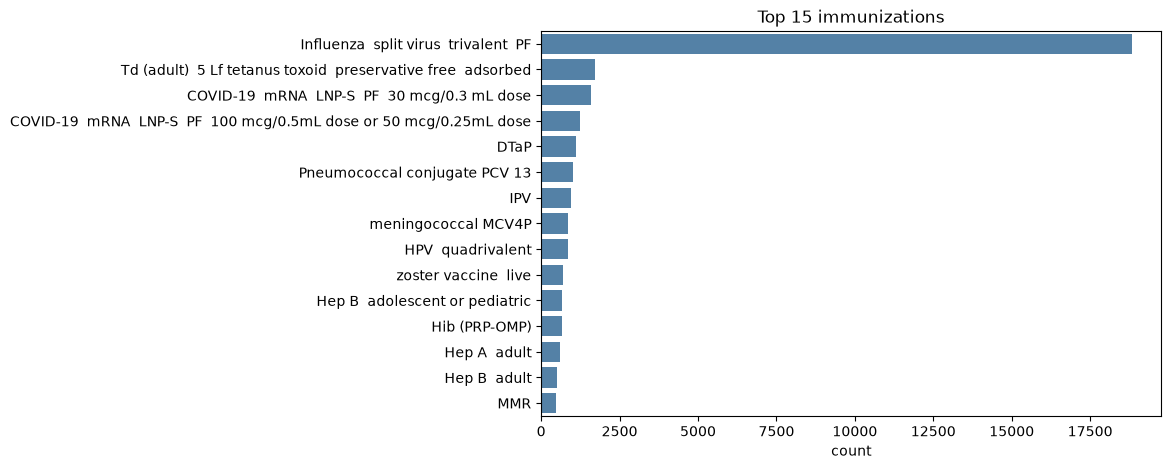

In [121]:
top15 = immunizations_df['DESCRIPTION'].value_counts().head(15)
plt.figure(figsize=(8, 5))
sns.barplot(x=top15.values, y=top15.index, color='steelblue')
plt.xlabel('count')
plt.ylabel('')
plt.title('Top 15 immunizations')
plt.show()

### Cost

In [122]:
print('distinct BASE_COST values:', immunizations_df['BASE_COST'].nunique())
immunizations_df['BASE_COST'].describe()

distinct BASE_COST values: 1


count   33654.00
mean      136.00
std         0.00
min       136.00
25%       136.00
50%       136.00
75%       136.00
max       136.00
Name: BASE_COST, dtype: float64

### Immunizations per patient & over time

In [123]:
imm_per_patient = immunizations_df.groupby('PATIENT').size()
print(f"{immunizations_df['PATIENT'].nunique():,} of 2,338 patients (100%) have at least one immunization")
imm_per_patient.describe()

2,338 of 2,338 patients (100%) have at least one immunization


count   2338.00
mean      14.39
std        6.13
min        1.00
25%       11.00
50%       13.00
75%       16.00
max       37.00
dtype: float64

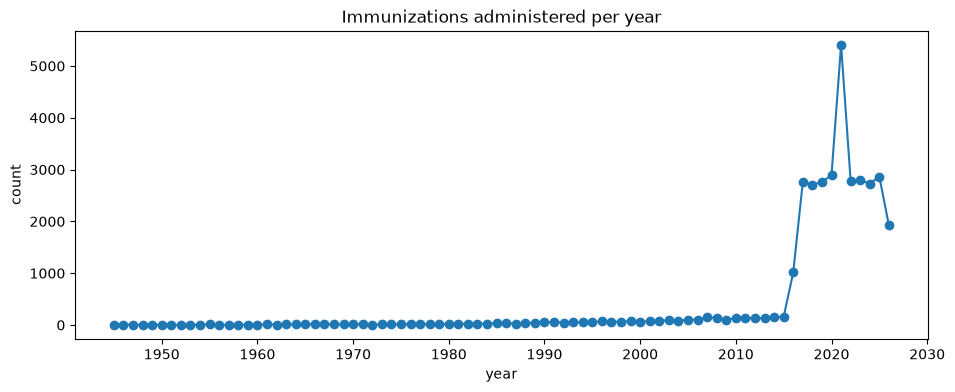

In [124]:
# 2021 spike is COVID-19 vaccination rollout; 2026 is a partial year like every other table
yearly = immunizations_df['DATE'].dt.year.value_counts().sort_index()

plt.figure(figsize=(11, 4))
yearly.plot(kind='line', marker='o')
plt.title('Immunizations administered per year')
plt.xlabel('year')
plt.ylabel('count')
plt.show()

### EDA summary - key insights

- **33,654 rows, zero missing values anywhere, every one of the 2,338 patients has at least one immunization** - the only table in the dataset with 100% patient coverage and no nulls.
- **`BASE_COST` is a single constant value ($136.00) across all 33,654 rows** - immunization administration is billed as a flat fee in this dataset, unlike medications/procedures where cost varies per drug/procedure type.
- **Influenza dominates volume** (18,822 - more than 10x the next most common), consistent with it being an annual, repeated vaccination rather than a one-time childhood series shot.
- **2021 shows a clear spike (5,406 vs. ~2,700-2,900 in surrounding years)** - the two COVID-19 mRNA vaccine entries (1,579 + 1,224 = 2,803 rows) land almost entirely in 2021, matching the real-world rollout timing; 2026 shows the usual partial-year dip.
- **14.4 immunizations per patient on average (median 13, max 37)** - a much tighter, lower-variance spread than conditions/medications, since immunization schedules are age/calendar-driven rather than disease-burden-driven.

## Devices

Medical devices attached/fitted at an encounter - `UDI` (Unique Device Identifier) is unique per row, meaning each row is one physical device *instance* given to one patient, not a reusable device-model catalog entry.

In [125]:
devices_df = pd.read_csv(
    '../synthea_data/output/csv/devices.csv',
    parse_dates=['START', 'STOP'],
)
devices_df

,START,STOP,PATIENT,ENCOUNTER,CODE,DESCRIPTION,UDI
0,1989-12-08 00:41:04+00:00,NaT,c44d667b-15d5-99d4-0f69-43ca66739022,c44d667b-15d5-99d4-6280-d38ed9b4e5ac,170615005,Home nebulizer (physical object),(01)52418671321476(11)891117(17)141202(10)2062...
1,2013-03-14 00:41:04+00:00,NaT,c44d667b-15d5-99d4-0f69-43ca66739022,c44d667b-15d5-99d4-8be2-fcf6faba9b86,1255320005,Wheeled walker (physical object),(01)55768158231223(11)130221(17)380308(10)3535...
2,2016-09-18 03:15:24+00:00,2016-09-18 03:15:24+00:00,c44d667b-15d5-99d4-0f69-43ca66739022,c44d667b-15d5-99d4-2e8b-c0fa393c1b54,706298007,Dental x-ray system (physical object),(01)47849069084086(11)160828(17)410912(10)2058...
3,2020-04-22 19:36:27+00:00,2020-04-22 19:36:27+00:00,51c5e2a9-2833-5133-b85a-329b9cd53c41,51c5e2a9-2833-5133-03ca-c23b8e0efba4,706298007,Dental x-ray system (physical object),(01)36926010162567(11)200402(17)450417(10)8569...
4,2017-09-24 02:53:34+00:00,2017-09-24 02:53:34+00:00,c44d667b-15d5-99d4-0f69-43ca66739022,c44d667b-15d5-99d4-416f-f036c04a17f1,706298007,Dental x-ray system (physical object),(01)72170512016026(11)170903(17)420918(10)7965...
...,...,...,...,...,...,...,...
13622,2020-06-14 03:23:24+00:00,2020-06-14 03:23:24+00:00,502dc964-df3b-7fa0-689e-78d3809a8df5,502dc964-df3b-7fa0-8f96-2230132e6b00,706298007,Dental x-ray system (physical object),(01)11703745682111(11)200524(17)450608(10)8138...
13623,2021-06-20 03:12:33+00:00,2021-06-20 03:12:33+00:00,502dc964-df3b-7fa0-689e-78d3809a8df5,502dc964-df3b-7fa0-d5e8-e1b8bce95866,706298007,Dental x-ray system (physical object),(01)56996658064930(11)210530(17)460614(10)9193...
13624,2021-06-20 03:59:17+00:00,NaT,502dc964-df3b-7fa0-689e-78d3809a8df5,502dc964-df3b-7fa0-d5e8-e1b8bce95866,225738002,Operating room (environment),(01)43206209945783(11)210530(17)460614(10)6323...
13625,2025-12-14 03:12:06+00:00,2025-12-14 03:12:06+00:00,502dc964-df3b-7fa0-689e-78d3809a8df5,502dc964-df3b-7fa0-73ee-dbf877415a99,706298007,Dental x-ray system (physical object),(01)37677946769568(11)251123(17)501208(10)5600...


### Data quality

In [126]:
devices_df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13627 entries, 0 to 13626
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   START        13627 non-null  datetime64[ns, UTC]
 1   STOP         8765 non-null   datetime64[ns, UTC]
 2   PATIENT      13627 non-null  object             
 3   ENCOUNTER    13627 non-null  object             
 4   CODE         13627 non-null  int64              
 5   DESCRIPTION  13627 non-null  object             
 6   UDI          13627 non-null  object             
dtypes: datetime64[ns, UTC](2), int64(1), object(4)
memory usage: 745.4+ KB


In [127]:
missing_pct = devices_df.isna().mean().sort_values(ascending=False)
missing_pct = (missing_pct[missing_pct > 0] * 100).round(1)
print(missing_pct)
print('UDI is unique per row:', devices_df['UDI'].is_unique, f"({devices_df['UDI'].nunique():,} of {len(devices_df):,})")

STOP   35.70
dtype: float64
UDI is unique per row: True (13,627 of 13,627)


### Top devices

In [128]:
devices_df['DESCRIPTION'].value_counts().head(15)

DESCRIPTION
Dental x-ray system (physical object)                              7089
Operating room (environment)                                       2411
Blood glucose meter (physical object)                               928
Home nebulizer (physical object)                                    499
Manual wheelchair (physical object)                                 468
Home continuous positive airway pressure unit (physical object)     454
Respiratory humidifier (physical object)                            454
Denture  device (physical object)                                   356
Hospital bed  device (physical object)                              199
Wheelchair accessory (physical object)                              122
Appliance for sleep apnea (physical object)                         118
Oxygen concentrator (physical object)                                97
Respiratory apnea monitoring system (physical object)                67
Polysomnography analyzer (physical object)          

### Still attached vs. removed

In [129]:
print(f"{devices_df['STOP'].isna().mean():.1%} of device rows have no STOP (still attached/in use)")

35.7% of device rows have no STOP (still attached/in use)


### Devices per patient

In [130]:
devices_per_patient = devices_df.groupby('PATIENT').size()
print(f"{devices_df['PATIENT'].nunique():,} of 2,338 patients have at least one device")
devices_per_patient.describe()

2,147 of 2,338 patients have at least one device


count   2147.00
mean       6.35
std        7.59
min        1.00
25%        2.00
50%        4.00
75%        7.00
max      108.00
dtype: float64

### EDA summary - key insights

- **13,627 rows, 2,147 of 2,338 patients (91.8%), `UDI` unique on every row** - confirms the table's grain is one device instance per row, not a device-type reference table.
- **Top devices are dominated by a routine dental fixture, not implants**: "Dental x-ray system" (7,089, ~52% of all rows) and "Operating room (environment)" (2,411) are administrative/equipment entries tied to encounter type rather than a device fitted to the patient - filter these out when a question is specifically about patient-worn/implanted devices (glucose meters, nebulizers, wheelchairs, CPAP units, etc., which make up most of the remaining rows).
- **35.7% of device rows have no `STOP`** - i.e. still in use as of data generation, the same chronic-vs-resolved pattern seen in conditions/medications.
- **6.3 devices per patient on average (median 4, max 108)** - the max is an extreme outlier relative to the 75th percentile of 7, worth spot-checking that patient if devices ever become a modeling feature.

## Supplies

Consumable supplies used at an encounter (dental floss, test strips, PPE, etc.) - `QUANTITY` is the number of units consumed, and there's no per-row cost column (supplies aren't billed as separate line items the way medications/procedures are, at least not in this table).

In [131]:
supplies_df = pd.read_csv(
    '../synthea_data/output/csv/supplies.csv',
    parse_dates=['DATE'],
)
supplies_df

,DATE,PATIENT,ENCOUNTER,CODE,DESCRIPTION,QUANTITY
0,2016-09-18,c44d667b-15d5-99d4-0f69-43ca66739022,c44d667b-15d5-99d4-2e8b-c0fa393c1b54,277183007,Dental equipment (physical object),1
1,2016-09-18,c44d667b-15d5-99d4-0f69-43ca66739022,c44d667b-15d5-99d4-2e8b-c0fa393c1b54,1230220004,Conventional release periodontal gel (dose form),1
2,2016-09-18,c44d667b-15d5-99d4-0f69-43ca66739022,c44d667b-15d5-99d4-2e8b-c0fa393c1b54,469020004,Dental floss (physical object),1
3,2020-04-22,51c5e2a9-2833-5133-b85a-329b9cd53c41,51c5e2a9-2833-5133-03ca-c23b8e0efba4,277183007,Dental equipment (physical object),1
4,2020-04-22,51c5e2a9-2833-5133-b85a-329b9cd53c41,51c5e2a9-2833-5133-03ca-c23b8e0efba4,1230220004,Conventional release periodontal gel (dose form),1
...,...,...,...,...,...,...
62139,2025-12-14,502dc964-df3b-7fa0-689e-78d3809a8df5,502dc964-df3b-7fa0-73ee-dbf877415a99,1230220004,Conventional release periodontal gel (dose form),1
62140,2025-12-14,502dc964-df3b-7fa0-689e-78d3809a8df5,502dc964-df3b-7fa0-73ee-dbf877415a99,469020004,Dental floss (physical object),1
62141,2026-07-19,502dc964-df3b-7fa0-689e-78d3809a8df5,502dc964-df3b-7fa0-0bec-a4f003e0f5e1,277183007,Dental equipment (physical object),1
62142,2026-07-19,502dc964-df3b-7fa0-689e-78d3809a8df5,502dc964-df3b-7fa0-0bec-a4f003e0f5e1,1230220004,Conventional release periodontal gel (dose form),1


### Data quality

In [132]:
supplies_df.info(show_counts=True)
print()
print('any missing values:', supplies_df.isna().any().any())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62144 entries, 0 to 62143
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   DATE         62144 non-null  datetime64[ns]
 1   PATIENT      62144 non-null  object        
 2   ENCOUNTER    62144 non-null  object        
 3   CODE         62144 non-null  int64         
 4   DESCRIPTION  62144 non-null  object        
 5   QUANTITY     62144 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 2.8+ MB

any missing values: False


### Top supplies

In [133]:
supplies_df['DESCRIPTION'].value_counts().head(15)

DESCRIPTION
Dental equipment (physical object)                                                             13048
Conventional release periodontal gel (dose form)                                               13048
Dental floss (physical object)                                                                 13048
Blood glucose testing strips (physical object)                                                  7630
Blood lancet (physical object)                                                                  2761
Medical air low pressure tubing (physical object)                                               1971
Air filter  device (physical object)                                                            1971
Continuous positive airway pressure/Bilevel positive airway pressure mask (physical object)     1971
Continuous positive airway pressure nasal oxygen cannula (physical object)                      1010
CPAP/BPAP oral mask (physical object)                                          

In [134]:
# the three dental-visit supplies (equipment, periodontal gel, floss) share the exact same
# count (13,048) - issued together as a fixed kit for the same dental cleaning procedure
# seen in the Procedures section, not three independently-driven consumption patterns
dental = ['Dental equipment (physical object)', 'Conventional release periodontal gel (dose form)',
          'Dental floss (physical object)']
supplies_df[supplies_df['DESCRIPTION'].isin(dental)]['DESCRIPTION'].value_counts()

DESCRIPTION
Dental equipment (physical object)                  13048
Conventional release periodontal gel (dose form)    13048
Dental floss (physical object)                      13048
Name: count, dtype: int64

### Quantity

In [135]:
supplies_df['QUANTITY'].describe()

count   62144.00
mean       12.38
std        25.62
min         1.00
25%         1.00
50%         1.00
75%         1.00
max       100.00
Name: QUANTITY, dtype: float64

### Supplies per patient & per visit

In [136]:
supplies_per_patient = supplies_df.groupby('PATIENT').size()
supplies_per_visit = supplies_df.groupby('ENCOUNTER').size()
print(f"{supplies_df['PATIENT'].nunique():,} of 2,338 patients have at least one supply row")
print(supplies_per_patient.describe())
print()
print(supplies_per_visit.describe())

2,222 of 2,338 patients have at least one supply row
count   2222.00
mean      27.97
std       43.04
min        1.00
25%       10.00
50%       18.00
75%       30.00
max      868.00
dtype: float64

count   23599.00
mean        2.63
std         3.07
min         1.00
25%         2.00
50%         3.00
75%         3.00
max       102.00
dtype: float64


### EDA summary - key insights

- **62,144 rows, 2,222 of 2,338 patients (95.0%), zero missing values.**
- **Dental-visit supplies are issued as a fixed kit**: "Dental equipment", "periodontal gel", and "dental floss" each appear exactly 13,048 times - all three are handed out together every time the dental cleaning procedure (13,016 rows in Procedures) happens, not three independently varying supply items.
- **`QUANTITY` is heavily right-skewed**: median 1, mean 12.4, max 100 - most supply rows are a single unit, with a long tail of bulk items (test strips, tubing) pulling the mean up well above the median.
- **28.0 supply rows per patient on average (median 18, max 868)** and **2.6 per visit (median 3, max 102)** - visits that trigger supply usage tend to use a small, consistent number of items (dental/CPAP kits), while a handful of patients with chronic device-dependent care (CPAP, glucose monitoring) accumulate very high per-patient totals.

## Imaging Studies

Imaging study *metadata* only - no actual image files or pixel data (design doc §4.5), so no radiology-interpretation questions are answerable from this table. **Important grain caveat**: a row here is one DICOM *instance* (one image/slice), not one imaging study - `Id` (the study) and `SERIES_UID` repeat across many rows, while `INSTANCE_UID` is unique per row. Counting rows directly overstates "how many imaging studies a patient had" by roughly 23x on average.

In [137]:
imaging_studies_df = pd.read_csv(
    '../synthea_data/output/csv/imaging_studies.csv',
    parse_dates=['DATE'],
)
imaging_studies_df

,Id,DATE,PATIENT,ENCOUNTER,SERIES_UID,BODYSITE_CODE,BODYSITE_DESCRIPTION,MODALITY_CODE,MODALITY_DESCRIPTION,INSTANCE_UID,SOP_CODE,SOP_DESCRIPTION,PROCEDURE_CODE
0,c44d667b-15d5-99d4-3fc5-c0283aa710de,2016-09-18 03:15:24+00:00,c44d667b-15d5-99d4-0f69-43ca66739022,c44d667b-15d5-99d4-2e8b-c0fa393c1b54,1.2.840.99999999.1.23693248.1474168524675,700016008,Structure of region of internal part of mouth ...,DX,Digital Radiography,1.2.840.99999999.1.1.40472112.1474168524675,1.2.840.10008.5.1.4.1.1.1.3,Digital Intra-Oral X-Ray Image Storage - For P...,241046008
1,51c5e2a9-2833-5133-6408-a341371faad3,2020-04-22 19:36:27+00:00,51c5e2a9-2833-5133-b85a-329b9cd53c41,51c5e2a9-2833-5133-03ca-c23b8e0efba4,1.2.840.99999999.1.46298603.1587584187937,700016008,Structure of region of internal part of mouth ...,DX,Digital Radiography,1.2.840.99999999.1.1.87973493.1587584187937,1.2.840.10008.5.1.4.1.1.1.3,Digital Intra-Oral X-Ray Image Storage - For P...,241046008
2,c44d667b-15d5-99d4-fe7a-c4d86a993f88,2017-09-24 02:53:34+00:00,c44d667b-15d5-99d4-0f69-43ca66739022,c44d667b-15d5-99d4-416f-f036c04a17f1,1.2.840.99999999.1.84350609.1506221614675,700016008,Structure of region of internal part of mouth ...,DX,Digital Radiography,1.2.840.99999999.1.1.69013852.1506221614675,1.2.840.10008.5.1.4.1.1.1.3,Digital Intra-Oral X-Ray Image Storage - For P...,241046008
3,502cf42a-a540-ff39-3006-08a061a755a4,2017-05-01 00:06:20+00:00,502cf42a-a540-ff39-0d59-c10d7cc1f4c7,502cf42a-a540-ff39-b74b-39504621e1d1,1.2.840.99999999.1.97265850.1493597180728,700016008,Structure of region of internal part of mouth ...,DX,Digital Radiography,1.2.840.99999999.1.1.22972084.1493597180728,1.2.840.10008.5.1.4.1.1.1.3,Digital Intra-Oral X-Ray Image Storage - For P...,241046008
4,502cf42a-a540-ff39-0a79-ce07007f7e6d,2022-06-06 00:14:37+00:00,502cf42a-a540-ff39-0d59-c10d7cc1f4c7,502cf42a-a540-ff39-eec6-486c63cd94d2,1.2.840.99999999.1.63910038.1654474477728,700016008,Structure of region of internal part of mouth ...,DX,Digital Radiography,1.2.840.99999999.1.1.15525282.1654474477728,1.2.840.10008.5.1.4.1.1.1.3,Digital Intra-Oral X-Ray Image Storage - For P...,241046008
...,...,...,...,...,...,...,...,...,...,...,...,...,...
261803,93adf52a-483e-ccb6-5732-c807eb2cca93,2012-10-17 11:53:01+00:00,93adf52a-483e-ccb6-f8b3-a046e54372d6,93adf52a-483e-ccb6-c67a-f1dc749d1827,1.2.840.99999999.1.24427186.1350474781375,700016008,Structure of region of internal part of mouth ...,DX,Digital Radiography,1.2.840.99999999.1.1.56813743.1350474781375,1.2.840.10008.5.1.4.1.1.1.3,Digital Intra-Oral X-Ray Image Storage - For P...,241046008
261804,502dc964-df3b-7fa0-7754-40f689c6cc8d,2020-06-14 03:23:24+00:00,502dc964-df3b-7fa0-689e-78d3809a8df5,502dc964-df3b-7fa0-8f96-2230132e6b00,1.2.840.99999999.1.19563141.1592105004848,700016008,Structure of region of internal part of mouth ...,DX,Digital Radiography,1.2.840.99999999.1.1.77906434.1592105004848,1.2.840.10008.5.1.4.1.1.1.3,Digital Intra-Oral X-Ray Image Storage - For P...,241046008
261805,502dc964-df3b-7fa0-6ecd-b8140594fe2a,2021-06-20 03:12:33+00:00,502dc964-df3b-7fa0-689e-78d3809a8df5,502dc964-df3b-7fa0-d5e8-e1b8bce95866,1.2.840.99999999.1.79765960.1624158753848,700016008,Structure of region of internal part of mouth ...,DX,Digital Radiography,1.2.840.99999999.1.1.68804510.1624158753848,1.2.840.10008.5.1.4.1.1.1.3,Digital Intra-Oral X-Ray Image Storage - For P...,241046008
261806,502dc964-df3b-7fa0-f0bb-05df6c6bba91,2025-12-14 03:12:06+00:00,502dc964-df3b-7fa0-689e-78d3809a8df5,502dc964-df3b-7fa0-73ee-dbf877415a99,1.2.840.99999999.1.13467846.1765681926848,700016008,Structure of region of internal part of mouth ...,DX,Digital Radiography,1.2.840.99999999.1.1.73005389.1765681926848,1.2.840.10008.5.1.4.1.1.1.3,Digital Intra-Oral X-Ray Image Storage - For P...,241046008


### Data quality

In [138]:
imaging_studies_df.info(show_counts=True)
print()
print('any missing values:', imaging_studies_df.isna().any().any())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261808 entries, 0 to 261807
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype              
---  ------                --------------   -----              
 0   Id                    261808 non-null  object             
 1   DATE                  261808 non-null  datetime64[ns, UTC]
 2   PATIENT               261808 non-null  object             
 3   ENCOUNTER             261808 non-null  object             
 4   SERIES_UID            261808 non-null  object             
 5   BODYSITE_CODE         261808 non-null  int64              
 6   BODYSITE_DESCRIPTION  261808 non-null  object             
 7   MODALITY_CODE         261808 non-null  object             
 8   MODALITY_DESCRIPTION  261808 non-null  object             
 9   INSTANCE_UID          261808 non-null  object             
 10  SOP_CODE              261808 non-null  object             
 11  SOP_DESCRIPTION       261808 non-null  object       

### Row grain: instance vs. study

In [139]:
n_rows = len(imaging_studies_df)
n_studies = imaging_studies_df['Id'].nunique()
n_series = imaging_studies_df['SERIES_UID'].nunique()
n_instances = imaging_studies_df['INSTANCE_UID'].nunique()
print(f'{n_rows:,} rows | {n_studies:,} distinct studies (Id) | {n_series:,} distinct series | {n_instances:,} distinct instances')
print(f'average instances per study: {n_rows / n_studies:.1f}')

261,808 rows | 11,287 distinct studies (Id) | 11,287 distinct series | 261,808 distinct instances
average instances per study: 23.2


In [140]:
# always dedupe on Id before counting/aggregating at the study level
imaging_by_modality = imaging_studies_df.groupby('MODALITY_DESCRIPTION').agg(
    rows=('INSTANCE_UID', 'size'), studies=('Id', 'nunique'),
)
imaging_by_modality['instances_per_study'] = (imaging_by_modality['rows'] / imaging_by_modality['studies']).round(1)
imaging_by_modality.sort_values('rows', ascending=False)

,rows,studies,instances_per_study
MODALITY_DESCRIPTION,,,
Computed Tomography,249100,636,391.70
Digital Radiography,7499,7499,1.00
Ophthalmic Photography,2918,1459,2.00
Ophthalmic Tomography,1196,598,2.00
Computed Radiography,576,576,1.00
Ultrasound,519,519,1.00


### Body site

In [141]:
imaging_studies_df.drop_duplicates('Id')['BODYSITE_DESCRIPTION'].value_counts().head(15)

BODYSITE_DESCRIPTION
Structure of region of internal part of mouth (body structure)              7089
Entire retina (body structure)                                              2057
Thoracic structure (body structure)                                         1244
Heart structure (body structure)                                             499
Structure of upper extremity between shoulder and elbow (body structure)      82
Ankle region structure (body structure)                                       66
Wrist region structure (body structure)                                       63
Bone structure of clavicle (body structure)                                   56
Knee region structure (body structure)                                        53
Structure of pelvis (body structure)                                          32
Bone structure of mandible (body structure)                                   25
Entire chest and abdomen and pelvis (body structure)                          14
Structu

### Studies per patient (deduped)

In [142]:
studies_df = imaging_studies_df.drop_duplicates('Id')
studies_per_patient = studies_df.groupby('PATIENT').size()
print(f"{studies_df['PATIENT'].nunique():,} of 2,338 patients have at least one imaging study")
studies_per_patient.describe()

2,052 of 2,338 patients have at least one imaging study


count   2052.00
mean       5.50
std        9.33
min        1.00
25%        2.00
50%        3.00
75%        5.00
max      122.00
dtype: float64

### EDA summary - key insights

- **261,808 rows collapse to only 11,287 distinct imaging studies (`Id`)** - the table's grain is one DICOM *instance* per row (~23.2 instances/study on average), not one study. Any "how many imaging studies" or "studies per patient" question must `drop_duplicates('Id')` first, or it will overcount by an order of magnitude.
- **The overcounting is wildly uneven by modality**: Computed Tomography is only 636 studies (5.6% of all studies) but generates 249,100 rows (95.2% of all rows) at ~391.7 instances/study (realistic - a chest CT produces hundreds of slices). Digital Radiography, by contrast, is 7,499 studies at exactly 1.0 instance/study (a single X-ray image per study). Row-level aggregation and study-level aggregation give completely different pictures of "what imaging is most common" - CT dominates one, Digital Radiography dominates the other.
- **`BODYSITE_DESCRIPTION` is dominated by "Thoracic structure"** (249,708 rows - almost entirely the CT chest-imaging instances above), followed by mouth structures (7,089, tied to the dental x-ray device rows in Devices) and "Entire retina" (4,114, ophthalmic imaging).
- **2,052 of 2,338 patients (87.8%) have at least one imaging study**, median 3 studies/patient (deduped), max 122 - once deduped, this is a much more reasonable distribution than the raw row-count-per-patient view (which had a max of 29,531 rows for one CT-heavy patient).

## Payers

The insurer roster - only 10 rows, one per payer. Referenced by `encounters.PAYER`, `medications.PAYER`, `payer_transitions.PAYER`/`SECONDARY_PAYER`, and `claims.PRIMARYPATIENTINSURANCEID`/`SECONDARYPATIENTINSURANCEID` (misleadingly named - these are payer IDs, not a separate insurance-policy table).

In [143]:
payers_df = pd.read_csv('../synthea_data/output/csv/payers.csv')
payers_df

,Id,NAME,OWNERSHIP,ADDRESS,CITY,STATE_HEADQUARTERED,ZIP,PHONE,AMOUNT_COVERED,AMOUNT_UNCOVERED,REVENUE,COVERED_ENCOUNTERS,UNCOVERED_ENCOUNTERS,COVERED_MEDICATIONS,UNCOVERED_MEDICATIONS,COVERED_PROCEDURES,UNCOVERED_PROCEDURES,COVERED_IMMUNIZATIONS,UNCOVERED_IMMUNIZATIONS,UNIQUE_CUSTOMERS,QOLS_AVG,MEMBER_MONTHS
0,a735bf55-83e9-331a-899d-a82a60b9f60c,Medicare,GOVERNMENT,NaN,NaN,NaN,NaN,NaN,172367098.67,8611735.36,21293458.20,72373,0,86648,0,171517,0,12392,0,731,0.73,128928
1,df166300-5a78-3502-a46a-832842197811,Medicaid,GOVERNMENT,NaN,NaN,NaN,NaN,NaN,282054619.40,6400507.67,2337670.00,78985,0,31271,0,173457,0,25558,0,1014,0.93,236424
2,d18ef2e6-ef40-324c-be54-34a5ee865625,Dual Eligible,GOVERNMENT,NaN,NaN,NaN,NaN,NaN,49293051.76,978528.36,244480.00,17842,0,20232,0,39518,0,2569,0,199,0.73,25176
3,26aab0cd-6aba-3e1b-ac5b-05c8867e762c,Humana,PRIVATE,NaN,NaN,NaN,NaN,NaN,105272990.80,65307109.97,63021708.00,51658,0,23102,0,121620,0,20212,0,502,0.96,185916
4,b046940f-1664-3047-bca7-dfa76be352a4,Blue Cross Blue Shield,PRIVATE,NaN,NaN,NaN,NaN,NaN,84280944.87,23749308.08,47329803.00,21416,0,9165,0,49082,0,8992,0,835,0.40,171816
5,d31fccc3-1767-390d-966a-22a5156f4219,UnitedHealthcare,PRIVATE,NaN,NaN,NaN,NaN,NaN,42948705.99,12336780.82,32109005.00,17884,0,7985,0,40324,0,8242,0,256,0.94,64980
6,0133f751-9229-3cfd-815f-b6d4979bdd6a,Aetna,PRIVATE,NaN,NaN,NaN,NaN,NaN,27694989.70,20065045.71,5916385.05,14545,0,7152,0,35326,0,5136,0,423,0.94,55368
7,8fa6c185-e44e-3e34-8bd8-39be8694f4ce,Cigna Health,PRIVATE,NaN,NaN,NaN,NaN,NaN,27909551.16,16974695.10,7517079.00,14607,0,7646,0,34152,0,5285,0,437,0.93,53508
8,734afbd6-4794-363b-9bc0-6a3981533ed5,Anthem,PRIVATE,NaN,NaN,NaN,NaN,NaN,26167484.64,6349621.34,7322937.65,9529,0,4920,0,21719,0,3436,0,378,0.91,30624
9,e03e23c9-4df1-3eb6-a62d-f70f02301496,NO_INSURANCE,NO_INSURANCE,NaN,NaN,NaN,NaN,NaN,0.00,263999319.73,0.00,0,85217,0,30370,0,197867,0,32688,964,0.98,336384


### Coverage & customer base

In [144]:
payers_df[['NAME', 'OWNERSHIP', 'UNIQUE_CUSTOMERS', 'COVERED_ENCOUNTERS',
           'UNCOVERED_ENCOUNTERS', 'AMOUNT_COVERED', 'AMOUNT_UNCOVERED', 'QOLS_AVG']].sort_values(
    'UNIQUE_CUSTOMERS', ascending=False
)

,NAME,OWNERSHIP,UNIQUE_CUSTOMERS,COVERED_ENCOUNTERS,UNCOVERED_ENCOUNTERS,AMOUNT_COVERED,AMOUNT_UNCOVERED,QOLS_AVG
1,Medicaid,GOVERNMENT,1014,78985,0,282054619.40,6400507.67,0.93
9,NO_INSURANCE,NO_INSURANCE,964,0,85217,0.00,263999319.73,0.98
4,Blue Cross Blue Shield,PRIVATE,835,21416,0,84280944.87,23749308.08,0.40
0,Medicare,GOVERNMENT,731,72373,0,172367098.67,8611735.36,0.73
3,Humana,PRIVATE,502,51658,0,105272990.80,65307109.97,0.96
7,Cigna Health,PRIVATE,437,14607,0,27909551.16,16974695.10,0.93
6,Aetna,PRIVATE,423,14545,0,27694989.70,20065045.71,0.94
8,Anthem,PRIVATE,378,9529,0,26167484.64,6349621.34,0.91
5,UnitedHealthcare,PRIVATE,256,17884,0,42948705.99,12336780.82,0.94
2,Dual Eligible,GOVERNMENT,199,17842,0,49293051.76,978528.36,0.73


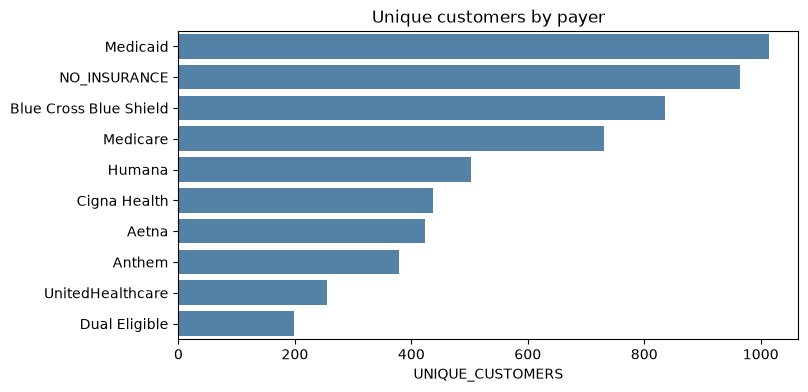

In [145]:
plt.figure(figsize=(8, 4))
order = payers_df.sort_values('UNIQUE_CUSTOMERS', ascending=False)['NAME']
sns.barplot(data=payers_df, x='UNIQUE_CUSTOMERS', y='NAME', order=order, color='steelblue')
plt.title('Unique customers by payer')
plt.ylabel('')
plt.show()

### EDA summary - key insights

- **Only 10 payers total**: 3 government (Medicare, Medicaid, Dual Eligible), 6 private, plus a synthetic `NO_INSURANCE` "payer" used to represent uninsured patients - any payer-level analysis is inherently low-cardinality and easy to eyeball in full, no sampling needed.
- **`NO_INSURANCE` has the second-highest customer count (964)**, just behind Medicaid (1,014) and ahead of every private insurer - a meaningful uninsured population exists in this dataset, worth accounting for in any coverage-rate analysis rather than assuming universal insurance.
- **`QOLS_AVG` (average quality-of-life score of a payer's members) varies widely and isn't correlated with coverage generosity in an obvious way**: Blue Cross Blue Shield has the lowest QOLS_AVG (0.40) despite being a mainstream private insurer, while `NO_INSURANCE` has the highest (0.98) - likely reflects *which patients* end up on each payer (e.g. sicker/older populations on certain plans) rather than the payer's effect on outcomes; don't read this as a causal insurer-quality signal.

## Payer Transitions

Which payer covered a patient over which date range - a junction table (no PK) where a patient can have many rows as coverage changes over time (job changes, aging into Medicare, etc.).

In [146]:
payer_transitions_df = pd.read_csv(
    '../synthea_data/output/csv/payer_transitions.csv',
    parse_dates=['START_DATE', 'END_DATE'],
)
payer_transitions_df

,PATIENT,MEMBERID,START_DATE,END_DATE,PAYER,SECONDARY_PAYER,PLAN_OWNERSHIP,OWNER_NAME
0,51c5e2a9-2833-5133-b85a-329b9cd53c41,NaN,1986-01-22 17:21:52+00:00,1987-01-28 17:21:52+00:00,e03e23c9-4df1-3eb6-a62d-f70f02301496,NaN,NaN,NaN
1,51c5e2a9-2833-5133-b85a-329b9cd53c41,NaN,1987-01-28 17:21:52+00:00,1988-01-27 17:21:52+00:00,e03e23c9-4df1-3eb6-a62d-f70f02301496,NaN,NaN,NaN
2,51c5e2a9-2833-5133-b85a-329b9cd53c41,NaN,1988-01-27 17:21:52+00:00,1989-01-25 17:21:52+00:00,e03e23c9-4df1-3eb6-a62d-f70f02301496,NaN,NaN,NaN
3,51c5e2a9-2833-5133-b85a-329b9cd53c41,NaN,1989-01-25 17:21:52+00:00,1990-01-24 17:21:52+00:00,e03e23c9-4df1-3eb6-a62d-f70f02301496,NaN,NaN,NaN
4,51c5e2a9-2833-5133-b85a-329b9cd53c41,NaN,1990-01-24 17:21:52+00:00,1991-01-23 17:21:52+00:00,e03e23c9-4df1-3eb6-a62d-f70f02301496,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
86397,502dc964-df3b-7fa0-689e-78d3809a8df5,502dc964-df3b-7fa0-3a2b-aaf08ef37fd8,2021-12-19 01:10:17+00:00,2022-12-18 01:10:17+00:00,a735bf55-83e9-331a-899d-a82a60b9f60c,b046940f-1664-3047-bca7-dfa76be352a4,Self,Dewayne363 Effertz744
86398,502dc964-df3b-7fa0-689e-78d3809a8df5,502dc964-df3b-7fa0-4ae8-484fd9275691,2022-12-18 01:10:17+00:00,2023-12-17 01:10:17+00:00,a735bf55-83e9-331a-899d-a82a60b9f60c,b046940f-1664-3047-bca7-dfa76be352a4,Self,Dewayne363 Effertz744
86399,502dc964-df3b-7fa0-689e-78d3809a8df5,502dc964-df3b-7fa0-e8a3-3d7b3d53541b,2023-12-17 01:10:17+00:00,2024-12-15 01:10:17+00:00,a735bf55-83e9-331a-899d-a82a60b9f60c,b046940f-1664-3047-bca7-dfa76be352a4,Self,Dewayne363 Effertz744
86400,502dc964-df3b-7fa0-689e-78d3809a8df5,502dc964-df3b-7fa0-614b-f1c372a1446b,2024-12-15 01:10:17+00:00,2025-12-21 01:10:17+00:00,a735bf55-83e9-331a-899d-a82a60b9f60c,b046940f-1664-3047-bca7-dfa76be352a4,Spouse,Mrs. Effertz744


### Data quality

In [147]:
payer_transitions_df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86402 entries, 0 to 86401
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   PATIENT          86402 non-null  object             
 1   MEMBERID         63936 non-null  object             
 2   START_DATE       86402 non-null  datetime64[ns, UTC]
 3   END_DATE         86402 non-null  datetime64[ns, UTC]
 4   PAYER            86402 non-null  object             
 5   SECONDARY_PAYER  8070 non-null   object             
 6   PLAN_OWNERSHIP   63936 non-null  object             
 7   OWNER_NAME       63936 non-null  object             
dtypes: datetime64[ns, UTC](2), object(6)
memory usage: 5.3+ MB


In [148]:
missing_pct = payer_transitions_df.isna().mean().sort_values(ascending=False)
missing_pct = (missing_pct[missing_pct > 0] * 100).round(1)
missing_pct

SECONDARY_PAYER   90.70
MEMBERID          26.00
PLAN_OWNERSHIP    26.00
OWNER_NAME        26.00
dtype: float64

### Primary & secondary payer mix

In [149]:
primary_named = payer_transitions_df.merge(
    payers_df[['Id', 'NAME']], left_on='PAYER', right_on='Id', how='left',
)
primary_named['NAME'].value_counts()

NAME
NO_INSURANCE              22466
Medicaid                  16207
Humana                    13761
Medicare                  10426
Blue Cross Blue Shield     5483
UnitedHealthcare           5194
Aetna                      4246
Cigna Health               4138
Anthem                     2504
Dual Eligible              1977
Name: count, dtype: int64

In [150]:
# only 9.3% of rows carry a secondary payer at all - dual coverage is the exception, not the norm
print(f"{payer_transitions_df['SECONDARY_PAYER'].notna().mean():.1%} of transitions have a SECONDARY_PAYER")
secondary_named = payer_transitions_df.merge(
    payers_df[['Id', 'NAME']], left_on='SECONDARY_PAYER', right_on='Id', how='left',
)
secondary_named['NAME'].value_counts()

9.3% of transitions have a SECONDARY_PAYER


NAME
Blue Cross Blue Shield    8070
Name: count, dtype: int64

### Coverage transitions per patient

In [151]:
transitions_per_patient = payer_transitions_df.groupby('PATIENT').size()
transitions_per_patient.describe()

count   2322.00
mean      37.21
std       18.10
min        1.00
25%       22.00
50%       41.00
75%       55.00
max       89.00
dtype: float64

### EDA summary - key insights

- **86,402 coverage-period rows across 2,322 patients, 37.2 transitions/patient on average (median 41, max 89)** - patients accumulate many short coverage periods over a lifetime, consistent with Synthea modeling coverage as changing periodically (e.g. yearly) rather than staying fixed.
- **`SECONDARY_PAYER` is populated on only 9.3% of rows, and when it is, it's always Blue Cross Blue Shield (8,070 of 8,070 non-null rows)** - dual coverage in this dataset is rare and, oddly, funnels through a single specific private insurer rather than being distributed across payers.
- **`MEMBERID`/`PLAN_OWNERSHIP`/`OWNER_NAME` are missing together (26.0% each)** - almost certainly the rows where `PAYER` resolves to `NO_INSURANCE` (an uninsured period has no member ID or plan ownership to record), matching the `payers.csv` finding that `NO_INSURANCE` has the second-largest customer base.
- **Primary payer distribution roughly mirrors the `payers.csv` `UNIQUE_CUSTOMERS` ranking** (`NO_INSURANCE` and Medicaid lead), confirming the two tables are internally consistent.

## Claims

One row per claim - but **not 1:1 with encounters**: `APPOINTMENTID` (→ `encounters.Id`) repeats across multiple claim rows for the same visit far more often than not. `STATUS1`/`STATUS2`/`STATUSP` are always `BILLED`/`CLOSED` in this dataset (design doc §4.3.2, confirmed below) - there is no `DENIED` state, so "why was this claim rejected" is not answerable; reframe to billing-lifecycle questions instead.

In [152]:
claims_df = pd.read_csv(
    '../synthea_data/output/csv/claims.csv',
    parse_dates=['CURRENTILLNESSDATE', 'SERVICEDATE', 'LASTBILLEDDATE1', 'LASTBILLEDDATE2', 'LASTBILLEDDATEP'],
)
claims_df

,Id,PATIENTID,PROVIDERID,PRIMARYPATIENTINSURANCEID,SECONDARYPATIENTINSURANCEID,DEPARTMENTID,PATIENTDEPARTMENTID,DIAGNOSIS1,DIAGNOSIS2,DIAGNOSIS3,DIAGNOSIS4,DIAGNOSIS5,DIAGNOSIS6,DIAGNOSIS7,DIAGNOSIS8,REFERRINGPROVIDERID,APPOINTMENTID,CURRENTILLNESSDATE,SERVICEDATE,SUPERVISINGPROVIDERID,STATUS1,STATUS2,STATUSP,OUTSTANDING1,OUTSTANDING2,OUTSTANDINGP,LASTBILLEDDATE1,LASTBILLEDDATE2,LASTBILLEDDATEP,HEALTHCARECLAIMTYPEID1,HEALTHCARECLAIMTYPEID2
0,c44d667b-15d5-99d4-6ff6-023fd344b030,c44d667b-15d5-99d4-0f69-43ca66739022,3166bff6-ecf5-3796-84c2-f3d90ffcd5ea,NaN,NaN,10,10,160968000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,c44d667b-15d5-99d4-9dc3-bb2d895495b9,1981-10-11 00:41:04+00:00,1981-10-11 00:41:04+00:00,3166bff6-ecf5-3796-84c2-f3d90ffcd5ea,CLOSED,CLOSED,CLOSED,0.00,0.00,0.00,1981-10-11 01:06:02+00:00,1981-10-11 01:06:02+00:00,1981-10-11 01:06:02+00:00,1,1
1,c44d667b-15d5-99d4-fa44-8a2b14f69cbc,c44d667b-15d5-99d4-0f69-43ca66739022,3166bff6-ecf5-3796-84c2-f3d90ffcd5ea,NaN,NaN,20,20,224299000,266934004.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,c44d667b-15d5-99d4-718f-134336f41a28,1983-10-23 00:41:04+00:00,1983-10-23 00:41:04+00:00,3166bff6-ecf5-3796-84c2-f3d90ffcd5ea,CLOSED,CLOSED,CLOSED,0.00,0.00,0.00,1983-10-23 01:11:48+00:00,1983-10-23 01:11:48+00:00,1983-10-23 01:11:48+00:00,1,1
2,c44d667b-15d5-99d4-52db-83310a7563ea,c44d667b-15d5-99d4-0f69-43ca66739022,3166bff6-ecf5-3796-84c2-f3d90ffcd5ea,NaN,NaN,20,20,713458007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,c44d667b-15d5-99d4-2c91-9fd0d8e38b98,1984-10-28 00:41:04+00:00,1984-10-28 00:41:04+00:00,3166bff6-ecf5-3796-84c2-f3d90ffcd5ea,CLOSED,CLOSED,CLOSED,0.00,0.00,0.00,1984-10-28 01:16:53+00:00,1984-10-28 01:16:53+00:00,1984-10-28 01:16:53+00:00,1,1
3,c44d667b-15d5-99d4-b78f-6eee85aa89db,c44d667b-15d5-99d4-0f69-43ca66739022,de74b4c1-1b6d-3cc5-8d97-4b9d444a6748,NaN,NaN,1,1,75498004,40055000.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,c44d667b-15d5-99d4-6280-d38ed9b4e5ac,1989-12-08 00:41:04+00:00,1989-12-08 00:41:04+00:00,de74b4c1-1b6d-3cc5-8d97-4b9d444a6748,CLOSED,CLOSED,CLOSED,0.00,0.00,0.00,1989-12-08 00:56:04+00:00,1989-12-08 00:56:04+00:00,1989-12-08 00:56:04+00:00,2,2
4,c44d667b-15d5-99d4-c344-aa2ab32bfcc7,c44d667b-15d5-99d4-0f69-43ca66739022,de74b4c1-1b6d-3cc5-8d97-4b9d444a6748,NaN,NaN,1,1,156073000,161744009.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,c44d667b-15d5-99d4-db0e-663f459a4c7e,1997-07-10 00:41:04+00:00,1997-07-10 00:41:04+00:00,de74b4c1-1b6d-3cc5-8d97-4b9d444a6748,CLOSED,CLOSED,CLOSED,0.00,0.00,0.00,1997-07-10 00:56:04+00:00,1997-07-10 00:56:04+00:00,1997-07-10 00:56:04+00:00,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255648,502dc964-df3b-7fa0-a8f0-4a32205fedd4,502dc964-df3b-7fa0-689e-78d3809a8df5,941421d9-3343-3ad6-8e5b-31b1a806dd10,a735bf55-83e9-331a-899d-a82a60b9f60c,b046940f-1664-3047-bca7-dfa76be352a4,6,6,26929004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,502dc964-df3b-7fa0-fdd6-eba7b837e886,2025-12-21 01:10:17+00:00,2025-12-21 01:10:17+00:00,941421d9-3343-3ad6-8e5b-31b1a806dd10,CLOSED,NaN,CLOSED,0.00,NaN,0.00,2025-12-30 01:25:17+00:00,NaT,2025-12-30 01:25:17+00:00,1,0
255649,502dc964-df3b-7fa0-a2c6-fdf5a0255d53,502dc964-df3b-7fa0-689e-78d3809a8df5,5cdeccb6-c568-3206-b830-681487798473,a735bf55-83e9-331a-899d-a82a60b9f60c,b046940f-1664-3047-bca7-dfa76be352a4,1,1,444814009,444814009.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,502dc964-df3b-7fa0-d044-a77766f658cb,2026-01-04 01:10:17+00:00,2026-01-04 01:10:17+00:00,5cdeccb6-c568-3206-b830-681487798473,CLOSED,NaN,CLOSED,0.00,NaN,0.00,2026-01-04 01:25:17+00:00,NaT,2026-01-04 01:25:17+00:00,2,0
255650,502dc964-df3b-7fa0-1c41-9371a270d14a,502dc964-df3b-7fa0-689e-78d3809a8df5,9ecd2ae1-2878-3a54-93c2-ae106786378e,a735bf55-83e9-331a-899d-a82a60b9f60c,b046940f-1664-3047-bca7-dfa76be352a4,20,20,160903007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,502dc964-df3b-7fa0-c09f-28f35610826e,2026-07-05 01:10:17+00:00,2026-07-05 01:10:17+00:00,9ecd2ae1-2878-3a54-93c2-ae106786378e,CLOSED,NaN,CLOSED,0.00,NaN,0.00,2026-07-05 01:47:54+00:0

### Data quality

In [153]:
claims_df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255653 entries, 0 to 255652
Data columns (total 31 columns):
 #   Column                       Non-Null Count   Dtype              
---  ------                       --------------   -----              
 0   Id                           255653 non-null  object             
 1   PATIENTID                    255653 non-null  object             
 2   PROVIDERID                   255653 non-null  object             
 3   PRIMARYPATIENTINSURANCEID    238011 non-null  object             
 4   SECONDARYPATIENTINSURANCEID  82453 non-null   object             
 5   DEPARTMENTID                 255653 non-null  int64              
 6   PATIENTDEPARTMENTID          255653 non-null  int64              
 7   DIAGNOSIS1                   255653 non-null  int64              
 8   DIAGNOSIS2                   75042 non-null   float64            
 9   DIAGNOSIS3                   25590 non-null   float64            
 10  DIAGNOSIS4                   778

In [154]:
missing_pct = claims_df.isna().mean().sort_values(ascending=False)
missing_pct = (missing_pct[missing_pct > 0] * 100).round(1)
missing_pct

REFERRINGPROVIDERID           100.00
DIAGNOSIS8                    100.00
DIAGNOSIS7                     99.80
DIAGNOSIS6                     99.70
DIAGNOSIS5                     99.00
DIAGNOSIS4                     97.00
DIAGNOSIS3                     90.00
DIAGNOSIS2                     70.60
SECONDARYPATIENTINSURANCEID    67.70
STATUS2                        32.30
LASTBILLEDDATE2                32.30
OUTSTANDING2                   32.30
PRIMARYPATIENTINSURANCEID       6.90
dtype: float64

### Claim status: confirming the no-denial finding

In [155]:
print(claims_df['STATUS1'].value_counts(dropna=False))
print()
print(claims_df['STATUSP'].value_counts(dropna=False))
print()
print('any status value other than BILLED/CLOSED (STATUS1/STATUSP):',
      set(claims_df['STATUS1'].dropna()) | set(claims_df['STATUSP'].dropna()) - {'BILLED', 'CLOSED'})

STATUS1
CLOSED    255324
BILLED       329
Name: count, dtype: int64

STATUSP
CLOSED    255324
BILLED       329
Name: count, dtype: int64

any status value other than BILLED/CLOSED (STATUS1/STATUSP): {'BILLED', 'CLOSED'}


### Diagnosis code fill rate

In [156]:
diag_cols = [f'DIAGNOSIS{i}' for i in range(1, 9)]
claims_df[diag_cols].notna().mean().rename('PCT_FILLED').round(3)

DIAGNOSIS1   1.00
DIAGNOSIS2   0.29
DIAGNOSIS3   0.10
DIAGNOSIS4   0.03
DIAGNOSIS5   0.01
DIAGNOSIS6   0.00
DIAGNOSIS7   0.00
DIAGNOSIS8   0.00
Name: PCT_FILLED, dtype: float64

### Claims are not 1:1 with encounters

In [157]:
claims_per_encounter = claims_df.groupby('APPOINTMENTID').size()
print(f"{len(claims_df):,} claim rows over {claims_per_encounter.shape[0]:,} distinct encounters "
      f"({claims_per_encounter.mean():.2f} claims/encounter on average)")
claims_per_encounter.value_counts().sort_index().head(10)

255,653 claim rows over 138,211 distinct encounters (1.85 claims/encounter on average)


1     76593
2     41140
3      7088
4      6139
5      3288
6      1436
7       874
8       369
9       517
10      124
Name: count, dtype: int64

In [158]:
# spot-check a multi-claim encounter - the extra claim rows are near-identical
# (same provider, diagnosis, service date), differing only in Id - Synthea appears to split
# one encounter into multiple claim submissions rather than one claim covering everything
multi_appt = claims_per_encounter[claims_per_encounter > 1].index[0]
claims_df[claims_df['APPOINTMENTID'] == multi_appt][
    ['Id', 'PROVIDERID', 'DIAGNOSIS1', 'SERVICEDATE', 'STATUS1']
]

,Id,PROVIDERID,DIAGNOSIS1,SERVICEDATE,STATUS1
64215,0047fe86-4398-c107-7fc1-45f64ab519ba,a9e02cb4-f5d3-3992-9d64-817b01a27fda,389095005,2025-05-22 04:12:53+00:00,CLOSED
64216,0047fe86-4398-c107-3b78-6fb93851ad51,a9e02cb4-f5d3-3992-9d64-817b01a27fda,389095005,2025-05-22 04:12:53+00:00,CLOSED


### Outstanding balances

In [159]:
claims_df[['OUTSTANDING1', 'OUTSTANDING2', 'OUTSTANDINGP']].describe()

,OUTSTANDING1,OUTSTANDING2,OUTSTANDINGP
count,255653.00,173169.00,255653.00
mean,0.53,0.49,0.14
std,58.02,59.31,12.66
min,0.00,0.00,0.00
25%,0.00,0.00,0.00
50%,0.00,0.00,0.00
75%,0.00,0.00,0.00
max,11318.93,11318.93,3406.18


### Claims per patient

In [160]:
claims_per_patient = claims_df.groupby('PATIENTID').size()
claims_per_patient.describe()

count   2338.00
mean     109.35
std      216.13
min        1.00
25%       31.00
50%       53.00
75%       91.00
max     3039.00
dtype: float64

### EDA summary - key insights

- **255,653 claim rows over only 138,211 distinct encounters (1.85 claims/encounter on average)** - joining claims to encounters via `APPOINTMENTID` expecting a 1:1 relationship is wrong most of the time. Spot-checking a multi-claim encounter shows the extra rows are near-duplicates (same provider, diagnosis, service date), differing only in `Id` - looks like Synthea splits some encounters into multiple claim submissions rather than one row covering the whole visit, with no column distinguishing *why* a given encounter got split.
- **`STATUS1`/`STATUSP` confirm the design doc's finding exactly**: every value across all 255,653 rows is `BILLED` or `CLOSED` (99.87% `CLOSED`) - no `DENIED`/`REJECTED` state exists anywhere. `STATUS2` additionally has 32.3% nulls - it's only populated when a secondary payer is involved.
- **Diagnosis codes drop off fast past the first slot**: `DIAGNOSIS1` is 100% filled (every claim needs at least one), `DIAGNOSIS2` only 29.4%, and by `DIAGNOSIS5` it's under 1% - most claims carry a single diagnosis code, multi-diagnosis claims are the exception.
- **`REFERRINGPROVIDERID` is 100% null** - a structurally dead column in this dataset, not a sampling gap; don't build a feature around it.
- **`OUTSTANDING1`/`OUTSTANDING2`/`OUTSTANDINGP` are almost always $0** (median $0 at every quartile through the 75th for `OUTSTANDINGP`) - consistent with `claims_transactions` showing total payments exactly matching total charges dataset-wide (see below): claims here don't sit unpaid.
- **109.3 claims per patient on average (median 53, max 3,039)** - the familiar high-utilization outlier pattern, amplified further by the ~1.85x claims-per-encounter multiplier above.

## Claims Transactions

Line-item charges within a claim - the actual billing detail, 2.2M+ rows at this population scale (design doc §4.3.2). `CLAIMID` → `claims.Id`, `APPOINTMENTID` → `encounters.Id`. `TYPE` determines which dollar columns are populated: `CHARGE`/`TRANSFERIN` use `AMOUNT`, `PAYMENT` uses `PAYMENTS`, `TRANSFERIN`/`TRANSFEROUT` use `TRANSFERS` - a row never has all of them filled at once.

In [161]:
claims_txns_df = pd.read_csv(
    '../synthea_data/output/csv/claims_transactions.csv',
    parse_dates=['FROMDATE', 'TODATE'],
)
claims_txns_df

,ID,CLAIMID,CHARGEID,PATIENTID,TYPE,AMOUNT,METHOD,FROMDATE,TODATE,PLACEOFSERVICE,PROCEDURECODE,MODIFIER1,MODIFIER2,DIAGNOSISREF1,DIAGNOSISREF2,DIAGNOSISREF3,DIAGNOSISREF4,UNITS,DEPARTMENTID,NOTES,UNITAMOUNT,TRANSFEROUTID,TRANSFERTYPE,PAYMENTS,ADJUSTMENTS,TRANSFERS,OUTSTANDING,APPOINTMENTID,LINENOTE,PATIENTINSURANCEID,FEESCHEDULEID,PROVIDERID,SUPERVISINGPROVIDERID
0,4eef1459-5fdf-3b46-06d2-eb40fdb88834,c44d667b-15d5-99d4-6ff6-023fd344b030,0,c44d667b-15d5-99d4-0f69-43ca66739022,CHARGE,136.80,NaN,1981-10-11 00:41:04+00:00,1981-10-11 01:06:02+00:00,4ff8b164-4cf5-3ab4-b0f2-7ce8fda920e5,410620009,NaN,NaN,1,NaN,NaN,NaN,1,10,Well child visit (procedure),136.80,NaN,p,0.00,0.00,NaN,0.00,c44d667b-15d5-99d4-9dc3-bb2d895495b9,NaN,NaN,1,3166bff6-ecf5-3796-84c2-f3d90ffcd5ea,3166bff6-ecf5-3796-84c2-f3d90ffcd5ea
1,9dde28b3-cbbe-768c-0da5-d68207711068,c44d667b-15d5-99d4-6ff6-023fd344b030,1,c44d667b-15d5-99d4-0f69-43ca66739022,PAYMENT,NaN,CHECK,1981-10-11 00:41:04+00:00,1981-10-11 01:06:02+00:00,4ff8b164-4cf5-3ab4-b0f2-7ce8fda920e5,410620009,NaN,NaN,1,NaN,NaN,NaN,1,10,Well child visit (procedure),0.00,NaN,NaN,136.80,0.00,NaN,0.00,c44d667b-15d5-99d4-9dc3-bb2d895495b9,NaN,NaN,1,3166bff6-ecf5-3796-84c2-f3d90ffcd5ea,3166bff6-ecf5-3796-84c2-f3d90ffcd5ea
2,36d2555b-2151-5bb1-83c7-83d64c38f98a,c44d667b-15d5-99d4-fa44-8a2b14f69cbc,3,c44d667b-15d5-99d4-0f69-43ca66739022,CHARGE,136.80,NaN,1983-10-23 00:41:04+00:00,1983-10-23 01:11:48+00:00,4ff8b164-4cf5-3ab4-b0f2-7ce8fda920e5,162673000,NaN,NaN,1,2.00,NaN,NaN,1,20,General examination of patient (procedure),136.80,NaN,p,0.00,0.00,NaN,0.00,c44d667b-15d5-99d4-718f-134336f41a28,NaN,NaN,1,3166bff6-ecf5-3796-84c2-f3d90ffcd5ea,3166bff6-ecf5-3796-84c2-f3d90ffcd5ea
3,6da4aab6-42a3-cf62-078f-07ac98720b15,c44d667b-15d5-99d4-fa44-8a2b14f69cbc,4,c44d667b-15d5-99d4-0f69-43ca66739022,PAYMENT,NaN,CHECK,1983-10-23 00:41:04+00:00,1983-10-23 01:11:48+00:00,4ff8b164-4cf5-3ab4-b0f2-7ce8fda920e5,162673000,NaN,NaN,1,2.00,NaN,NaN,1,20,General examination of patient (procedure),0.00,NaN,NaN,136.80,0.00,NaN,0.00,c44d667b-15d5-99d4-718f-134336f41a28,NaN,NaN,1,3166bff6-ecf5-3796-84c2-f3d90ffcd5ea,3166bff6-ecf5-3796-84c2-f3d90ffcd5ea
4,d577fc7f-0fcc-1bbf-f2b0-d71bf387455e,c44d667b-15d5-99d4-52db-83310a7563ea,6,c44d667b-15d5-99d4-0f69-43ca66739022,CHARGE,136.80,NaN,1984-10-28 00:41:04+00:00,1984-10-28 01:16:53+00:00,4ff8b164-4cf5-3ab4-b0f2-7ce8fda920e5,162673000,NaN,NaN,1,NaN,NaN,NaN,1,20,General examination of patient (procedure),136.80,NaN,p,0.00,0.00,NaN,0.00,c44d667b-15d5-99d4-2c91-9fd0d8e38b98,NaN,NaN,1,3166bff6-ecf5-3796-84c2-f3d90ffcd5ea,3166bff6-ecf5-3796-84c2-f3d90ffcd5ea
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2247674,a9ecf437-6209-0429-34fd-79b25f2c87d3,502dc964-df3b-7fa0-0dab-9f19c4138632,2922389,502dc964-df3b-7fa0-689e-78d3809a8df5,CHARGE,431.40,NaN,2026-07-19 03:49:38+00:00,2026-07-19 04:00:23+00:00,440fa4b8-c731-3cf5-81d9-aa3f30a37b95,243085009,NaN,NaN,1,NaN,NaN,NaN,1,1,Oral health education (procedure),431.40,NaN,1,0.00,0.00,NaN,0.00,502dc964-df3b-7fa0-0bec-a4f003e0f5e1,NaN,502dc964-df3b-7fa0-d5f0-8e1fcce2f496,1,5cdeccb6-c568-3206-b830-681487798473,5cdeccb6-c568-3206-b830-681487798473
2247675,66b88241-0a6a-7b3d-c577-cb21f4cd3f5e,502dc964-df3b-7fa0-0dab-9f19c4138632,2922390,502dc964-df3b-7fa0-689e-78d3809a8df5,PAYMENT,NaN,ECHECK,2026-07-19 03:49:38+00:00,2026-07-19 04:00:23+00:00,440fa4b8-c731-3cf5-81d9-aa3f30a37b95,243085009,NaN,NaN,1,NaN,NaN,NaN,1,1,Oral health education (procedure),0.00,NaN,NaN,345.12,0.00,NaN,86.28,502dc964-df3b-7fa0-0bec-a4f003e0f5e1,NaN,502dc964-df3b-7fa0-d5f0-8e1fcce2f496,1,5cdeccb6-c568-3206-b830-681487798473,5cdeccb6-c568-3206-b830-681487798473
2247676,d1710482-14d4-f67a-96ef-9643e99a7ebd,502dc964-df3b-7fa0-0dab-9f19c4138632,2922391,502dc964-df3b-7fa0-689e-78d3809a8df5,TRANSFEROUT,NaN,NaN,2026-07-19 03:49:38+00:00,2026-07-19 04:00:23+00:00,440fa4b8-c731-3cf5-81d9-aa3f30a37b95,243085009,NaN,NaN,1,NaN,N

### Data quality

In [162]:
claims_txns_df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2247679 entries, 0 to 2247678
Data columns (total 33 columns):
 #   Column                 Non-Null Count    Dtype              
---  ------                 --------------    -----              
 0   ID                     2247679 non-null  object             
 1   CLAIMID                2247679 non-null  object             
 2   CHARGEID               2247679 non-null  int64              
 3   PATIENTID              2247679 non-null  object             
 4   TYPE                   2247679 non-null  object             
 5   AMOUNT                 1032138 non-null  float64            
 6   METHOD                 858119 non-null   object             
 7   FROMDATE               2247679 non-null  datetime64[ns, UTC]
 8   TODATE                 2247679 non-null  datetime64[ns, UTC]
 9   PLACEOFSERVICE         2247679 non-null  object             
 10  PROCEDURECODE          2247679 non-null  int64              
 11  MODIFIER1              0

In [163]:
missing_pct = claims_txns_df.isna().mean().sort_values(ascending=False)
missing_pct = (missing_pct[missing_pct > 0] * 100).round(1)
missing_pct

MODIFIER1            100.00
LINENOTE             100.00
MODIFIER2            100.00
DIAGNOSISREF4         97.20
DIAGNOSISREF3         89.90
TRANSFEROUTID         84.10
TRANSFERS             68.20
DIAGNOSISREF2         67.00
METHOD                61.80
AMOUNT                54.10
TRANSFERTYPE          54.10
PATIENTINSURANCEID     3.60
dtype: float64

### `TYPE` determines which dollar column is populated

In [164]:
claims_txns_df['TYPE'].value_counts()

TYPE
PAYMENT        858119
CHARGE         674716
TRANSFEROUT    357422
TRANSFERIN     357422
Name: count, dtype: int64

In [165]:
for col in ['AMOUNT', 'PAYMENTS', 'TRANSFERS']:
    print(col)
    print(claims_txns_df.groupby('TYPE')[col].apply(lambda s: s.notna().mean()).round(2))
    print()

AMOUNT
TYPE
CHARGE        1.00
PAYMENT       0.00
TRANSFERIN    1.00
TRANSFEROUT   0.00
Name: AMOUNT, dtype: float64

PAYMENTS
TYPE
CHARGE        1.00
PAYMENT       1.00
TRANSFERIN    1.00
TRANSFEROUT   1.00
Name: PAYMENTS, dtype: float64

TRANSFERS
TYPE
CHARGE        0.00
PAYMENT       0.00
TRANSFERIN    1.00
TRANSFEROUT   1.00
Name: TRANSFERS, dtype: float64



In [166]:
# ADJUSTMENTS is 0.0 on every single row - a structurally dead column, not sparsely used
print('ADJUSTMENTS always exactly 0:', (claims_txns_df['ADJUSTMENTS'] == 0).all())

ADJUSTMENTS always exactly 0: True


### Charges vs. payments: does the ledger balance?

In [167]:
total_charged = claims_txns_df.loc[claims_txns_df['TYPE'] == 'CHARGE', 'AMOUNT'].sum()
total_paid = claims_txns_df['PAYMENTS'].sum()
print(f'total CHARGE amount:   ${total_charged:,.2f}')
print(f'total PAYMENTS amount: ${total_paid:,.2f}')
print(f'difference: ${total_charged - total_paid:,.2f}')

total CHARGE amount:   $369,376,048.08
total PAYMENTS amount: $369,376,048.08
difference: $-0.00


Every dollar charged across the entire dataset is eventually paid - consistent with the no-denial finding above and with `claims.OUTSTANDING*` being almost always $0. Cost/billing questions here are about *how* a charge was generated and covered, not whether it ultimately got paid.

### Line items per claim & per patient

In [168]:
lines_per_claim = claims_txns_df.groupby('CLAIMID').size()
lines_per_claim.describe()

count   255653.00
mean         8.79
std         13.38
min          1.00
25%          4.00
50%          5.00
75%         10.00
max        837.00
dtype: float64

In [169]:
lines_per_patient = claims_txns_df.groupby('PATIENTID').size()
lines_per_patient.describe()

count    2338.00
mean      961.37
std      1491.40
min         9.00
25%       355.00
50%       586.50
75%       938.50
max     18274.00
dtype: float64

### Payment method

In [170]:
# METHOD is only populated on PAYMENT rows (see TYPE breakdown above) - among those,
# electronic check dominates over card/cash/copay
claims_txns_df['METHOD'].value_counts()

METHOD
ECHECK    569242
CHECK      79411
CC         79049
CASH       78404
COPAY      52013
Name: count, dtype: int64

### Top billed procedures

In [171]:
claims_txns_df.loc[claims_txns_df['TYPE'] == 'CHARGE', 'PROCEDURECODE'].value_counts().head(10)

PROCEDURECODE
171207006          38490
185347001          36506
265764009          23347
710824005          23090
185349003          23078
162673000          20790
205923             19318
140                18822
430193006          16161
428211000124100    15225
Name: count, dtype: int64

### EDA summary - key insights

- **2,247,679 rows, matching the design doc's verified count exactly** - the largest table in the dataset after `observations`.
- **`TYPE` cleanly partitions which dollar column is meaningful**: `CHARGE` (674,716 rows) and `TRANSFERIN` (357,422) populate `AMOUNT`; `PAYMENT` (858,119) and every row populate `PAYMENTS`; `TRANSFERIN`/`TRANSFEROUT` (357,422 each) populate `TRANSFERS`. Reading `AMOUNT` or `TRANSFERS` without filtering on `TYPE` first will silently mix incompatible transaction kinds.
- **`ADJUSTMENTS` is exactly 0.0 on all 2,247,679 rows** - a structurally dead column (same pattern as `allergies.STOP` and `claims.REFERRINGPROVIDERID`), not a column with rare non-zero values worth searching for.
- **The ledger balances exactly**: total `CHARGE` amount ($369,376,048.08) equals total `PAYMENTS` ($369,376,048.08) to the cent, across the whole dataset - confirms there is no unpaid/written-off charge modeled anywhere, consistent with claims never carrying a `DENIED` status.
- **8.79 line items per claim on average (median 5, max 837)** and **961.4 per patient (median 586.5, max 18,274)** - claims with dozens to hundreds of line items exist and would dominate any naive "average cost per claim" calculation; use the median or filter to `TYPE == 'CHARGE'` first.
- **Among `PAYMENT` rows, electronic check (`ECHECK`) is the dominant method (66.3% of the 858,119 payment rows with a method)**, well ahead of paper check, credit card, cash, and copay.
- **Top billed `PROCEDURECODE` values mirror the top encounter/procedure codes from earlier sections** (185347001 "Encounter for problem", 185349003 "Encounter for check up") - confirms `claims_transactions` is internally consistent with `encounters`/`procedures`, just at a finer line-item grain.